# Cartographie thermique — ExtraTrees vs Gaussian Process (Cas A) : trajectoire × chauffage × régime

Ce notebook reprend le même pipeline que `NOTEBOOK_THERMIQUE_MODELE_UNIFIE_CasA_v3` (lecture des CSV, diagnostic stationnaire/instationnaire, features géométriques et CVC, encodage trajectoire × chauffage en *features* — Cas A) mais **limite le comparatif à deux modèles** :

- **ExtraTrees** (interprétation spatiale via features géométrie + voisins IDW, ou séquentielle pour l'instationnaire).
- **Gaussian Process** spatial dédié (position × chauffage, entraîné sur coordonnées réelles), avec estimation d'incertitude (écart-type prédictif).

**Nouveauté (régime stationnaire) :** en plus du régime stationnaire brut, on ajoute une version où le signal de température est rendu **artificiellement non stationnaire** par **ajout d'une tendance temporelle** `Y(t) = X(t) + a·t` (section 13bis), afin de tester si le gain de performance observé en régime instationnaire vient réellement de la non-stationnarité du signal ou d'autre chose (gradient, densité spatiale, information de voisinage, capacité du modèle).

Pour chaque régime, on obtient : un **tableau comparatif** (RMSE, MAE, MAPE, R²), une **visualisation en barres**, une **grille de parité réel vs prédit**, un **test de stabilité multi-seeds**, puis le **modèle le plus performant** est retenu pour reconstruire les cartes thermiques par combinaison trajectoire × chauffage.

## 0 — Installation et imports

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib scipy
print('Librairies installées !')

Librairies installées !


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
)
import warnings, re, os, glob

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print('Imports OK -- comparatif limite a 2 modeles : ExtraTrees, GaussianProcess')

Imports OK -- comparatif limite a 2 modeles : ExtraTrees, GaussianProcess


## 1 — Paramètres de la grille

In [3]:
# PARAMÈTRES DE LA GRILLE
LARGEUR  = 8   # axe X : A–H  (0–7) — 8 poteaux/colonnes
LONGUEUR = 5   # axe Y : 0–4        — 5 rangées en profondeur
HAUTEUR  = 3   # niveaux H1–H3 (axe Z : 0–2) — 3 hauteurs de capteur par poteau
N_CAPTEURS = 120

T_MIN_PHYSIQUE = -50
T_MAX_PHYSIQUE = 200

# --- Espacement RÉEL entre deux capteurs successifs (en mètres) -----------
# Mesuré sur le plan « Thermo-couple distribution » :
ESPACEMENT_X = 1.1   # entre deux poteaux successifs (colonnes i, b, c, ... h)
ESPACEMENT_Y = 1.2   # entre deux rangées successives (profondeur de la salle)
ESPACEMENT_Z = 0.5   # unité de base verticale (utilisée pour bâtir ALTITUDES_Z)

# Altitudes réelles (en mètres) des 3 niveaux de capteur sur chaque poteau
ALTITUDES_Z = [0.5, 1.0, 1.5]   # z=0 -> 0.5 m, z=1 -> 1.0 m, z=2 -> 1.5 m

# Dimensions physiques de la salle déduites de la grille de capteurs (m)
LARGEUR_M  = (LARGEUR  - 1) * ESPACEMENT_X
LONGUEUR_M = (LONGUEUR - 1) * ESPACEMENT_Y
HAUTEUR_M  = ALTITUDES_Z[-1]

# Pas de temps nominal entre deux points successifs de la trajectoire du robot.
# Utilisé (a) en secours si le parsing du temps échoue, (b) comme référence
# pour la feature dt_prev du modèle INSTATIONNAIRE (section 8).
PAS_TEMPOREL_SEQ = 20.0  # secondes

print(f'Grille configurée : {LARGEUR} × {LONGUEUR} × {HAUTEUR} '
      f'({LARGEUR_M:.1f} m × {LONGUEUR_M:.1f} m, jusqu\'à {HAUTEUR_M:.1f} m de haut)')
print(f'Espacement réel   : X={ESPACEMENT_X} m | Y={ESPACEMENT_Y} m | Z={ALTITUDES_Z} m')
print(f'Capteurs utilisés : {N_CAPTEURS}')
print(f'Pas temporel de la trajectoire (référence) : {PAS_TEMPOREL_SEQ:.0f} s')

Grille configurée : 8 × 5 × 3 (7.7 m × 4.8 m, jusqu'à 1.5 m de haut)
Espacement réel   : X=1.1 m | Y=1.2 m | Z=[0.5, 1.0, 1.5] m
Capteurs utilisés : 120
Pas temporel de la trajectoire (référence) : 20 s


## 2 — Équipements CVC (chauffage / climatisation)

Chaque source est définie par sa position `(x, y, z)` et son **type de diffusion**
(`horizontale` : reste concentrée à sa hauteur ; `verticale` : se propage sur toute la hauteur).
Adapte `SOURCES_FROID` / `SOURCES_CHAUD` à ton plan réel.

In [4]:
SOURCES_FROID = []  # ex. bouches de climatisation — vide si aucune
SOURCES_CHAUD = [
    # Heaters situés côté EST (mur x = LARGEUR-1 = colonne h), à mi-hauteur (z=1 -> 1.0 m)
    # d'après le plan « Thermo-couple distribution » (repère 'heaters' côté est).
    {'x': 7, 'y': 2, 'z': 1, 'type_diffusion': 'horizontale'},
    {'x': 7, 'y': 3, 'z': 1, 'type_diffusion': 'horizontale'},
]

POIDS_DIFFUSION = {
    'horizontale': {'xy': 1.0, 'z': 2.5},
    'verticale':   {'xy': 2.5, 'z': 0.3},
}

def dist_min_cvc(x, y, z, sources, espacement_x, espacement_y, altitudes_z,
                  poids_diffusion=POIDS_DIFFUSION):
    """Distance pondérée minimale (en mètres réels) vers la source CVC la plus
    proche + son type de diffusion. Les indices de grille (x, y, z) sont convertis
    en mètres via ESPACEMENT_X / ESPACEMENT_Y / ALTITUDES_Z avant tout calcul,
    car la grille n'est PAS un cube régulier (1.1 m × 1.2 m × altitudes non
    uniformes) : mélanger indices et mètres fausserait les distances."""
    if not sources:
        return 99.0, 'aucune'
    x_m, y_m, z_m = x * espacement_x, y * espacement_y, altitudes_z[int(z)]
    candidats = []
    for s in sources:
        sx, sy, sz = s['x'], s['y'], s.get('z', 0)
        sx_m, sy_m, sz_m = sx * espacement_x, sy * espacement_y, altitudes_z[int(sz)]
        type_d = s.get('type_diffusion', 'horizontale')
        poids = poids_diffusion[type_d]
        d_xy = np.sqrt((x_m - sx_m) ** 2 + (y_m - sy_m) ** 2)
        d_z = abs(z_m - sz_m)
        d = np.sqrt((poids['xy'] * d_xy) ** 2 + (poids['z'] * d_z) ** 2)
        candidats.append((d, type_d))
    return min(candidats, key=lambda t: t[0])

print('Sources CVC configurées :', len(SOURCES_FROID), 'froid /', len(SOURCES_CHAUD), 'chaud')
print(f'Salle : {LARGEUR_M:.1f} m × {LONGUEUR_M:.1f} m × {HAUTEUR_M:.1f} m — '
      f'distances CVC calculées en mètres réels.')

Sources CVC configurées : 0 froid / 2 chaud
Salle : 7.7 m × 4.8 m × 1.5 m — distances CVC calculées en mètres réels.


## 3 — Mapping capteur → position (x, y, z)

In [5]:
def build_sensor_positions(largeur, longueur, hauteur):
    """{numéro_capteur: (x, y, z)} — ordre : Y, puis X, puis Z (adapte si ton export diffère)."""
    pos = {}
    n = 1
    for y in range(longueur):
        for x in range(largeur):
            for z in range(hauteur):
                pos[n] = (x, y, z)
                n += 1
    return pos

capteur_positions = build_sensor_positions(LARGEUR, LONGUEUR, HAUTEUR)
print(f'{len(capteur_positions)} positions capteurs construites')

120 positions capteurs construites


## 4 — Pipeline de lecture / nettoyage / temps (fonction réutilisable)

Cette fonction encapsule les étapes robustes du notebook d'origine (lecture multi-format,
nettoyage physique, parsing du temps, direction aller/retour) pour pouvoir être appelée
**une fois par fichier CSV** (le fichier principal, et un fichier par type de chauffage
supplémentaire à la section 6).

In [6]:
def lire_et_nettoyer_csv(filename, n_capteurs=N_CAPTEURS,
                          t_min_phys=T_MIN_PHYSIQUE, t_max_phys=T_MAX_PHYSIQUE,
                          pas_temporel_secours=PAS_TEMPOREL_SEQ):
    """Lit un CSV brut (export type Row, Time, Temperature1..N) et retourne
    un DataFrame propre avec colonnes temp_cols, 't_sec', 'direction_encode'."""
    df_raw = None
    for sep, dec in [(',', ','), (';', '.'), (',', '.'), (';', ',')]:
        try:
            tmp = pd.read_csv(filename, sep=sep, decimal=dec, dtype=str)
            if tmp.shape[1] > 10:
                df_raw = tmp
                break
        except Exception:
            pass
    if df_raw is None:
        raise ValueError(f'Impossible de lire {filename} — vérifiez le format.')

    row0 = str(df_raw.iloc[0, 0])
    if re.match(r'^\d+:\d+', row0) or re.match(r'^\d{2}:\d{2}\.\d+', row0):
        df_raw = df_raw.iloc[1:].reset_index(drop=True)

    df = df_raw.copy()
    temp_cols_all = [c for c in df.columns
                     if re.match(r'Temperature\d+', c, re.I) or re.match(r'Temp\d+', c, re.I)]
    temp_cols = temp_cols_all[:n_capteurs]

    for col in temp_cols:
        df[col] = (df[col].astype(str).str.replace(',', '.', regex=False)
                   .pipe(pd.to_numeric, errors='coerce'))

    time_col = df.columns[1]

    for col in temp_cols:
        mask = (df[col] < t_min_phys) | (df[col] > t_max_phys)
        df.loc[mask, col] = np.nan
    for col in temp_cols:
        p1, p99 = df[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(p1, p99)

    # Parsing du temps
    time_ok = False
    for fmt in ['%I:%M:%S %p', '%H:%M:%S', '%M:%S', '%H:%M:%S.%f', '%H:%M']:
        try:
            parsed = pd.to_datetime(df[time_col].astype(str).str.strip(), format=fmt, errors='coerce')
            if parsed.notna().sum() >= max(1, len(df) * 0.5):
                df['time'] = parsed
                t0 = df['time'].min()
                df['t_sec'] = (df['time'] - t0).dt.total_seconds()
                time_ok = True
                break
        except Exception:
            pass
    if not time_ok:
        df['t_sec'] = np.arange(len(df)) * pas_temporel_secours

    # Direction aller/retour
    if 'Direction' in df.columns or 'direction' in df.columns:
        dir_col = 'Direction' if 'Direction' in df.columns else 'direction'
        df['direction'] = df[dir_col].astype(str).str.upper()
    else:
        df['t_diff']    = df['t_sec'].diff()
        df['is_jump']   = df['t_diff'] < 0
        df['cycle_num'] = df['is_jump'].cumsum()
        df['direction'] = df['cycle_num'].apply(lambda x: 'ALLER' if x % 2 == 0 else 'RETOUR')
    df['direction_encode'] = (df['direction'] == 'RETOUR').astype(int)

    df['temperature_mean'] = df[temp_cols].mean(axis=1)

    return df, temp_cols

print('Fonction lire_et_nettoyer_csv() prête.')

Fonction lire_et_nettoyer_csv() prête.


## 5 — Chargement du fichier CSV principal

In [7]:
try:
    from google.colab import files
    print('Sélectionnez votre fichier CSV principal (mesure de référence)...')
    uploaded = files.upload()
    FICHIER_PRINCIPAL = list(uploaded.keys())[0]
except ImportError:
    FICHIER_PRINCIPAL = 'mesure_principale.csv'  # <- adapte le chemin si tu n'es pas sur Colab
    print(f'Hors Colab : dépose ton CSV puis mets à jour FICHIER_PRINCIPAL (actuel : {FICHIER_PRINCIPAL})')

df, temp_cols = lire_et_nettoyer_csv(FICHIER_PRINCIPAL)
print(f'Fichier chargé : {FICHIER_PRINCIPAL}')
print(f'Shape : {df.shape}  |  {len(temp_cols)} colonnes de température')
print(f't_sec : {df["t_sec"].min():.0f}s -> {df["t_sec"].max():.0f}s')

Sélectionnez votre fichier CSV principal (mesure de référence)...


Saving ThermoCouple.csv to ThermoCouple.csv
Fichier chargé : ThermoCouple.csv
Shape : (898, 130)  |  120 colonnes de température
t_sec : 0s -> 17920s


## 6 — Diagnostic stationnaire / instationnaire

**Étape 1** : test global (régression température ~ temps).
**Étape 2** : test par fenêtres glissantes.
**Étape 3** : détection du point de bascule et scission `df_transitoire` / `df_stationnaire`.

In [8]:
def test_stationnarite(t, T, seuil_pente_C_par_h=0.5, seuil_p=0.05, verbose=True):
    t = np.asarray(t, dtype=float); T = np.asarray(T, dtype=float)
    mask = ~np.isnan(t) & ~np.isnan(T)
    t, T = t[mask], T[mask]
    if len(t) < 5:
        return {'verdict': 'INDÉTERMINÉ', 'pente_C_par_h': np.nan, 'r2': np.nan, 'p_value': np.nan}

    pente, ordonnee, r_value, p_value, std_err = stats.linregress(t, T)
    pente_C_par_h = pente * 3600

    if p_value > seuil_p:
        verdict = 'STATIONNAIRE'
    elif abs(pente_C_par_h) <= seuil_pente_C_par_h:
        verdict = 'QUASI-STATIONNAIRE'
    else:
        verdict = 'TRANSITOIRE'

    if verbose:
        print(f'Pente : {pente_C_par_h:+.4f} °C/h | R² : {r_value**2:.4f} | p-value : {p_value:.4g}')
        print(f'>>> VERDICT GLOBAL : {verdict}')
    return {'verdict': verdict, 'pente_C_par_h': pente_C_par_h, 'r2': r_value**2, 'p_value': p_value}


def detecter_phases(df, time_col='t_sec', temp_col='temperature_mean',
                     fenetre_min=30, pas_min=5, seuil_pente_C_par_h=0.5, seuil_p=0.05):
    t_all = df[time_col].values.astype(float)
    T_all = df[temp_col].values.astype(float)
    fenetre_s, pas_s = fenetre_min * 60, pas_min * 60
    t_min, t_max = np.nanmin(t_all), np.nanmax(t_all)

    records, t_debut = [], t_min
    while t_debut + fenetre_s <= t_max:
        t_fin = t_debut + fenetre_s
        m = (t_all >= t_debut) & (t_all < t_fin)
        if m.sum() >= 10:
            res = test_stationnarite(t_all[m], T_all[m], seuil_pente_C_par_h, seuil_p, verbose=False)
            records.append({'t_debut_min': t_debut / 60, 't_fin_min': t_fin / 60, **res})
        t_debut += pas_s

    phases = pd.DataFrame(records)
    print(f'{len(phases)} fenêtres analysées ({fenetre_min} min, pas {pas_min} min)')
    if len(phases):
        print(phases['verdict'].value_counts().to_string())
    return phases


def scinder_stationnaire(df, phases, time_col='t_sec', n_fenetres_stables=3):
    if len(phases) == 0:
        print('Pas assez de données pour détecter des phases -> tout le run est considéré STATIONNAIRE.')
        return df.iloc[0:0].copy(), df.copy(), None

    est_stable = phases['verdict'].isin(['STATIONNAIRE', 'QUASI-STATIONNAIRE'])
    t_bascule_min = None
    for i in range(len(phases) - n_fenetres_stables + 1):
        if est_stable.iloc[i:i + n_fenetres_stables].all():
            t_bascule_min = phases['t_debut_min'].iloc[i]
            break

    if t_bascule_min is None:
        print('Aucune phase stationnaire stable détectée -> tout le run est considéré INSTATIONNAIRE.')
        return df.copy(), df.iloc[0:0].copy(), None

    t_bascule_s = t_bascule_min * 60
    df_transitoire  = df[df[time_col] <  t_bascule_s].copy()
    df_stationnaire = df[df[time_col] >= t_bascule_s].copy()
    print(f'Bascule détectée à t = {t_bascule_min:.1f} min')
    print(f'  INSTATIONNAIRE : {len(df_transitoire):,} lignes')
    print(f'  STATIONNAIRE   : {len(df_stationnaire):,} lignes')
    return df_transitoire, df_stationnaire, t_bascule_min


print('ÉTAPE 1 — Test global')
resultat_global = test_stationnarite(df['t_sec'].values, df['temperature_mean'].values)
print('\nÉTAPE 2 — Fenêtres glissantes')
phases = detecter_phases(df)
print('\nÉTAPE 3 — Scission transitoire / stationnaire')
df_transitoire, df_stationnaire, t_bascule = scinder_stationnaire(df, phases)

ÉTAPE 1 — Test global
Pente : -1.5337 °C/h | R² : 0.5277 | p-value : 6.221e-148
>>> VERDICT GLOBAL : TRANSITOIRE

ÉTAPE 2 — Fenêtres glissantes
54 fenêtres analysées (30 min, pas 5 min)
verdict
TRANSITOIRE           23
QUASI-STATIONNAIRE    23
STATIONNAIRE           8

ÉTAPE 3 — Scission transitoire / stationnaire
Bascule détectée à t = 100.0 min
  INSTATIONNAIRE : 300 lignes
  STATIONNAIRE   : 597 lignes


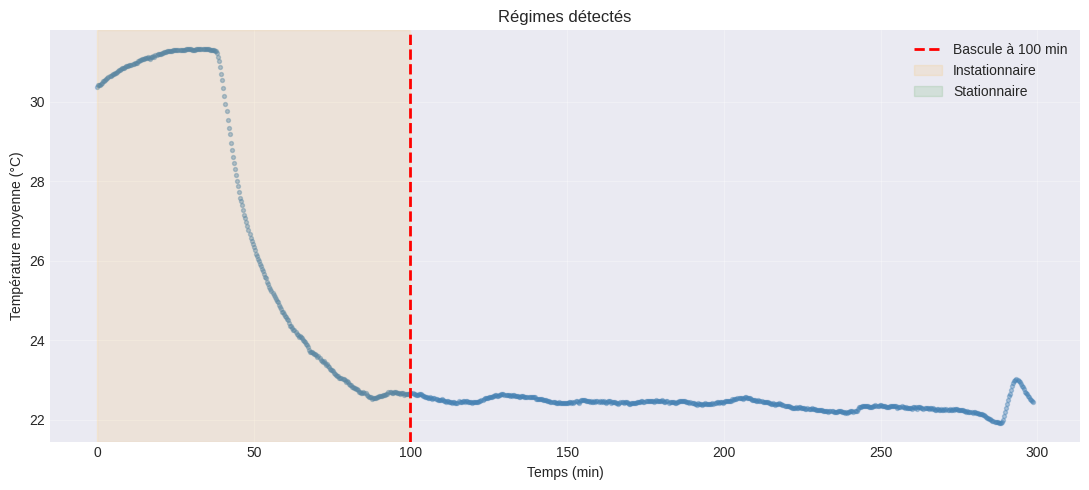

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
t_min_arr = df['t_sec'].values / 60
ax.scatter(t_min_arr, df['temperature_mean'], s=8, alpha=0.4, color='steelblue')
if t_bascule is not None:
    ax.axvline(t_bascule, color='red', ls='--', lw=2, label=f'Bascule à {t_bascule:.0f} min')
    ax.axvspan(0, t_bascule, color='orange', alpha=0.1, label='Instationnaire')
    ax.axvspan(t_bascule, t_min_arr.max(), color='green', alpha=0.1, label='Stationnaire')
ax.set_xlabel('Temps (min)'); ax.set_ylabel('Température moyenne (°C)')
ax.set_title('Régimes détectés'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7 — Construction du format long (1 ligne = 1 capteur × 1 instant), avec `phase`, `trajectory_type`, `heating_type`

C'est le format pivot utilisé pour les deux modèles (stationnaire et instationnaire).

In [10]:
def construire_df_long(df_source, capteur_positions, temp_cols, t_bascule,
                        trajectory_type, heating_type):
    """Reconstruit le format long et ajoute la phase (stationnaire/instationnaire),
    le type de trajectoire et le type de chauffage — ce sont les 3 features
    'catégorielles' du Cas A."""
    records = []
    for _, row in df_source.iterrows():
        t_val   = float(row['t_sec'])
        dir_val = int(row['direction_encode'])
        for i, col in enumerate(temp_cols):
            sensor_num = i + 1
            temp_val = row[col]
            if pd.isna(temp_val):
                continue
            pos = capteur_positions.get(sensor_num)
            if pos is None:
                continue
            x_, y_, z_ = pos
            records.append({
                'sensor_id': sensor_num, 'x': x_, 'y': y_, 'z': z_,
                't_sec': t_val, 'direction_encode': dir_val, 'temperature': float(temp_val),
            })
    dfl = pd.DataFrame(records)
    if len(dfl) == 0:
        return dfl
    if t_bascule is not None:
        dfl['phase'] = np.where(dfl['t_sec'] < t_bascule * 60, 'instationnaire', 'stationnaire')
    else:
        dfl['phase'] = 'stationnaire'
    dfl['trajectory_type'] = trajectory_type
    dfl['heating_type'] = heating_type
    return dfl

HEATING_TYPE_PRINCIPAL = 'mesure_principale'   # renomme si besoin
TRAJECTORY_TYPE_MESUREE = 'Serpentine (mesurée)'

df_long = construire_df_long(df, capteur_positions, temp_cols, t_bascule,
                              TRAJECTORY_TYPE_MESUREE, HEATING_TYPE_PRINCIPAL)
print(f'df_long : {len(df_long):,} lignes')
print(df_long['phase'].value_counts())

df_long : 107,760 lignes
phase
stationnaire      71760
instationnaire    36000
Name: count, dtype: int64


## 8 — (Optionnel) CSV supplémentaires par type de chauffage

Un fichier CSV par système de chauffage (convecteur, plancher chauffant, pompe à chaleur, ...),
même structure que le CSV principal. **Annule/ferme la fenêtre d'upload si tu n'en as pas** —
le notebook continue alors avec un seul `heating_type`.

In [11]:
fichiers_par_type = {}
try:
    from google.colab import files
    print('Sélectionnez les CSV additionnels par type de chauffage (ou annulez)...')
    uploaded2 = files.upload()
    os.makedirs('csv_chauffage', exist_ok=True)
    for nom_fichier in uploaded2.keys():
        if nom_fichier.lower().endswith('.csv'):
            with open(f'csv_chauffage/{nom_fichier}', 'wb') as f:
                f.write(uploaded2[nom_fichier])
    fichiers_par_type = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in sorted(glob.glob('csv_chauffage/*.csv'))
    }
except ImportError:
    pass  # hors Colab : laisse fichiers_par_type vide, ou remplis-le manuellement

print(f'{len(fichiers_par_type)} type(s) de chauffage supplémentaire(s) : {list(fichiers_par_type)}')

Sélectionnez les CSV additionnels par type de chauffage (ou annulez)...


Saving convecteur_electrique.csv to convecteur_electrique.csv
Saving plancher_chauffant_electrique.csv to plancher_chauffant_electrique.csv
Saving plinthe_electrique.csv to plinthe_electrique.csv
Saving pompe_a_chaleur_air_air.csv to pompe_a_chaleur_air_air.csv
Saving radiateur_eau_chaude.csv to radiateur_eau_chaude.csv
Saving ventiloconvecteur.csv to ventiloconvecteur.csv
6 type(s) de chauffage supplémentaire(s) : ['convecteur_electrique', 'plancher_chauffant_electrique', 'plinthe_electrique', 'pompe_a_chaleur_air_air', 'radiateur_eau_chaude', 'ventiloconvecteur']


In [12]:
df_long_par_type = {}
for nom_type, chemin_csv in fichiers_par_type.items():
    df_t, temp_cols_t = lire_et_nettoyer_csv(chemin_csv)
    phases_t = detecter_phases(df_t)
    _, _, t_bascule_t = scinder_stationnaire(df_t, phases_t)
    dfl_t = construire_df_long(df_t, capteur_positions, temp_cols_t, t_bascule_t,
                                TRAJECTORY_TYPE_MESUREE, nom_type)
    if len(dfl_t) >= 30:
        df_long_par_type[nom_type] = dfl_t
        print(f'{nom_type}: {len(dfl_t):,} lignes ajoutées')
    else:
        print(f'{nom_type}: trop peu de données -> ignoré')

49 fenêtres analysées (30 min, pas 5 min)
verdict
QUASI-STATIONNAIRE    28
TRANSITOIRE           18
STATIONNAIRE           3
Bascule détectée à t = 15.0 min
  INSTATIONNAIRE : 45 lignes
  STATIONNAIRE   : 774 lignes
convecteur_electrique: 98,280 lignes ajoutées
49 fenêtres analysées (30 min, pas 5 min)
verdict
QUASI-STATIONNAIRE    28
TRANSITOIRE           18
STATIONNAIRE           3
Bascule détectée à t = 15.0 min
  INSTATIONNAIRE : 45 lignes
  STATIONNAIRE   : 774 lignes
plancher_chauffant_electrique: 98,280 lignes ajoutées
49 fenêtres analysées (30 min, pas 5 min)
verdict
QUASI-STATIONNAIRE    28
TRANSITOIRE           18
STATIONNAIRE           3
Bascule détectée à t = 15.0 min
  INSTATIONNAIRE : 45 lignes
  STATIONNAIRE   : 774 lignes
plinthe_electrique: 98,280 lignes ajoutées
49 fenêtres analysées (30 min, pas 5 min)
verdict
QUASI-STATIONNAIRE    28
TRANSITOIRE           18
STATIONNAIRE           3
Bascule détectée à t = 15.0 min
  INSTATIONNAIRE : 45 lignes
  STATIONNAIRE   : 774 

## 9 — Trajectoires de couverture alternatives (simulation)

On simule d'autres façons pour le robot de parcourir la grille, en ne gardant que les
positions `(x, y)` correspondantes dans les données déjà mesurées. Cela donne, en plus de
la trajectoire réellement mesurée, des variantes utilisables comme *feature* `trajectory_type`.

In [13]:
positions_uniques = sorted(set(map(tuple, df_long[['x', 'y']].values.tolist())))
n_positions = len(positions_uniques)
FRACTION_PARTIELLE = 0.4
n_partiel = max(4, int(round(n_positions * FRACTION_PARTIELLE)))

def positions_perimetre(positions, largeur, longueur):
    return [p for p in positions if p[0] in (0, largeur - 1) or p[1] in (0, longueur - 1)]

def positions_zigzag(positions, pas=2):
    xs = sorted(set(p[0] for p in positions))
    cols_gardees = set(xs[::pas])
    return [p for p in positions if p[0] in cols_gardees]

def positions_aleatoire(positions, n, seed=42):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(positions), size=min(n, len(positions)), replace=False)
    return [positions[i] for i in idx]

def positions_fps(positions, n, seed=42):
    pts = np.array(positions, dtype=float)
    rng = np.random.RandomState(seed)
    chosen_idx = [int(rng.randint(len(pts)))]
    dists = np.linalg.norm(pts - pts[chosen_idx[0]], axis=1)
    while len(chosen_idx) < n:
        next_idx = int(np.argmax(dists))
        chosen_idx.append(next_idx)
        new_d = np.linalg.norm(pts - pts[next_idx], axis=1)
        dists = np.minimum(dists, new_d)
    return [positions[i] for i in chosen_idx]

trajectoires_subset = {
    'Périmètre':       positions_perimetre(positions_uniques, LARGEUR, LONGUEUR),
    'Zigzag diagonal': positions_zigzag(positions_uniques, pas=2),
    'Aléatoire':       positions_aleatoire(positions_uniques, n_partiel),
    'FPS':             positions_fps(positions_uniques, n_partiel),
}
for nom, subset in trajectoires_subset.items():
    print(f'{nom:20s}: {len(subset):3d}/{n_positions} positions ({len(subset)/n_positions*100:.0f}%)')

Périmètre           :  22/40 positions (55%)
Zigzag diagonal     :  20/40 positions (50%)
Aléatoire           :  16/40 positions (40%)
FPS                 :  16/40 positions (40%)


## 10 — Fusion : `df_fusion` (trajectoire × chauffage)

On assemble : la trajectoire mesurée (chauffage principal + chauffages additionnels, couverture 100%)
et les trajectoires partielles simulées (Périmètre, Zigzag, Aléatoire, FPS — appliquées uniquement
au chauffage principal, dont on connaît chaque position mesurée).

In [14]:
morceaux = [df_long]
for dfl_t in df_long_par_type.values():
    morceaux.append(dfl_t)

positions_all = list(zip(df_long['x'].values, df_long['y'].values))
for nom_traj, subset in trajectoires_subset.items():
    subset_set = set(subset)
    mask = np.array([p in subset_set for p in positions_all])
    d = df_long.loc[mask].copy()
    d['trajectory_type'] = nom_traj
    morceaux.append(d)

df_fusion = pd.concat(morceaux, ignore_index=True)
print(f'df_fusion : {len(df_fusion):,} lignes')
print('\ntrajectory_type :'); print(df_fusion['trajectory_type'].value_counts().to_string())
print('\nheating_type :');    print(df_fusion['heating_type'].value_counts().to_string())
print('\nphase :');           print(df_fusion['phase'].value_counts().to_string())

df_fusion : 896,796 lignes

trajectory_type :
trajectory_type
Serpentine (mesurée)    697440
Périmètre                59268
Zigzag diagonal          53880
Aléatoire                43104
FPS                      43104

heating_type :
heating_type
mesure_principale                307116
convecteur_electrique             98280
plancher_chauffant_electrique     98280
plinthe_electrique                98280
pompe_a_chaleur_air_air           98280
radiateur_eau_chaude              98280
ventiloconvecteur                 98280

phase :
phase
stationnaire      761796
instationnaire    135000


## 11 — Features géométriques et CVC (communes aux deux modèles)

In [15]:
cx = (LARGEUR  - 1) / 2 * ESPACEMENT_X
cy = (LONGUEUR - 1) / 2 * ESPACEMENT_Y
cz = (ALTITUDES_Z[0] + ALTITUDES_Z[-1]) / 2

# Positions converties en mètres réels (utilisées pour TOUTES les distances physiques)
df_fusion['x_m'] = df_fusion['x'] * ESPACEMENT_X
df_fusion['y_m'] = df_fusion['y'] * ESPACEMENT_Y
df_fusion['z_m'] = df_fusion['z'].map(lambda z: ALTITUDES_Z[int(z)])

df_fusion['dist_edge_x'] = np.minimum(df_fusion['x_m'], LARGEUR_M  - df_fusion['x_m'])
df_fusion['dist_edge_y'] = np.minimum(df_fusion['y_m'], LONGUEUR_M - df_fusion['y_m'])
df_fusion['dist_edge_z'] = np.minimum(df_fusion['z_m'], HAUTEUR_M  - df_fusion['z_m'])
df_fusion['dist_center'] = np.sqrt(
    (df_fusion['x_m'] - cx) ** 2 + (df_fusion['y_m'] - cy) ** 2 + (df_fusion['z_m'] - cz) ** 2)

# Distance/influence CVC : pré-calculée une fois par position (x, y, z) unique -> jointure (plus rapide que .apply ligne à ligne)
positions_xyz = df_fusion[['x', 'y', 'z']].drop_duplicates()
_froid = positions_xyz.apply(
    lambda r: dist_min_cvc(r['x'], r['y'], r['z'], SOURCES_FROID, ESPACEMENT_X, ESPACEMENT_Y, ALTITUDES_Z), axis=1)
_chaud = positions_xyz.apply(
    lambda r: dist_min_cvc(r['x'], r['y'], r['z'], SOURCES_CHAUD, ESPACEMENT_X, ESPACEMENT_Y, ALTITUDES_Z), axis=1)
positions_xyz = positions_xyz.assign(
    dist_froid=_froid.apply(lambda t: t[0]),
    froid_diffusion_verticale=(_froid.apply(lambda t: t[1]) == 'verticale').astype(int),
    dist_chaud=_chaud.apply(lambda t: t[0]),
    chaud_diffusion_verticale=(_chaud.apply(lambda t: t[1]) == 'verticale').astype(int),
)
df_fusion = df_fusion.merge(positions_xyz, on=['x', 'y', 'z'], how='left')
df_fusion['influence_froid'] = 1.0 / (1.0 + df_fusion['dist_froid'])
df_fusion['influence_chaud'] = 1.0 / (1.0 + df_fusion['dist_chaud'])

print('Features géométriques/CVC créées (distances en mètres réels : '
      f'{ESPACEMENT_X} m × {ESPACEMENT_Y} m × altitudes {ALTITUDES_Z}).')
print(df_fusion[['dist_center', 'dist_froid', 'dist_chaud', 'influence_froid', 'influence_chaud']].describe().round(3))

Features géométriques/CVC créées (distances en mètres réels : 1.1 m × 1.2 m × altitudes [0.5, 1.0, 1.5]).
       dist_center  dist_froid  dist_chaud  influence_froid  influence_chaud
count   896796.000    896796.0  896796.000        896796.00       896796.000
mean         2.931        99.0       4.434             0.01            0.232
std          1.066         0.0       2.246             0.00            0.142
min          0.550        99.0       0.000             0.01            0.109
25%          2.101        99.0       2.530             0.01            0.132
50%          2.955        99.0       4.400             0.01            0.185
75%          3.882        99.0       6.600             0.01            0.283
max          4.564        99.0       8.162             0.01            1.000


## 12 — Encodage Cas A : trajectoire + chauffage comme *features* (one-hot)

**Cas A** = le modèle sait toujours quelle trajectoire et quel chauffage ont produit la mesure
(pas de classification à deviner). C'est le seul cas retenu ici.

In [16]:
traj_dummies = pd.get_dummies(df_fusion['trajectory_type'], prefix='traj')
heat_dummies = pd.get_dummies(df_fusion['heating_type'], prefix='chauff')
df_fusion = pd.concat([df_fusion.reset_index(drop=True),
                        traj_dummies.reset_index(drop=True),
                        heat_dummies.reset_index(drop=True)], axis=1)

FEATURES_CATEGORIELLES = list(traj_dummies.columns) + list(heat_dummies.columns)
FEATURES_GEOMETRIE_CVC = [
    'x', 'y', 'z', 'dist_edge_x', 'dist_edge_y', 'dist_edge_z', 'dist_center',
    'dist_froid', 'dist_chaud', 'influence_froid', 'influence_chaud',
    'froid_diffusion_verticale', 'chaud_diffusion_verticale',
]
print(f'{len(FEATURES_CATEGORIELLES)} features catégorielles (trajectoire+chauffage) : {FEATURES_CATEGORIELLES}')

12 features catégorielles (trajectoire+chauffage) : ['traj_Aléatoire', 'traj_FPS', 'traj_Périmètre', 'traj_Serpentine (mesurée)', 'traj_Zigzag diagonal', 'chauff_convecteur_electrique', 'chauff_mesure_principale', 'chauff_plancher_chauffant_electrique', 'chauff_plinthe_electrique', 'chauff_pompe_a_chaleur_air_air', 'chauff_radiateur_eau_chaude', 'chauff_ventiloconvecteur']


## 12bis — Analyse géométrique et visualisation 3D des capteurs

Avant toute modélisation, on reconstruit la géométrie physique réelle des 120 capteurs
(à partir de `LARGEUR`, `LONGUEUR`, `HAUTEUR`, `ESPACEMENT_X`, `ESPACEMENT_Y`, `ALTITUDES_Z`),
on vérifie le maillage, on le visualise en 3D, puis on identifie les zones les moins bien couvertes.

In [17]:
# --- Reconstruction des coordonnees physiques reelles (metres) des 120 capteurs ---
positions_df = pd.DataFrame(
    [(n, x, y, z, x * ESPACEMENT_X, y * ESPACEMENT_Y, ALTITUDES_Z[z])
     for n, (x, y, z) in capteur_positions.items()],
    columns=['capteur', 'x', 'y', 'z', 'x_m', 'y_m', 'z_m']
)

assert len(positions_df) == N_CAPTEURS == 120, "Le nombre de capteurs reconstruits ne correspond pas a 120"
print(f'Verification : {len(positions_df)} capteurs reconstruits (attendu : {N_CAPTEURS}) -> OK')
print()
print(f'Dimensions physiques de la chambre : {LARGEUR_M:.2f} m (X) x {LONGUEUR_M:.2f} m (Y) x {HAUTEUR_M:.2f} m (Z)')
print(f'Volume approx. : {LARGEUR_M * LONGUEUR_M * HAUTEUR_M:.1f} m3')
print()

print('Capteurs par niveau (Z) :')
tab_z = positions_df.groupby('z').size().rename('n_capteurs').to_frame()
tab_z['altitude_m'] = [ALTITUDES_Z[z] for z in tab_z.index]
print(tab_z)
print()

print('Capteurs par rangee (Y) :')
tab_y = positions_df.groupby('y').size().rename('n_capteurs').to_frame()
tab_y['position_m'] = tab_y.index * ESPACEMENT_Y
print(tab_y)
print()

print('Capteurs par colonne (X) :')
tab_x = positions_df.groupby('x').size().rename('n_capteurs').to_frame()
tab_x['position_m'] = tab_x.index * ESPACEMENT_X
print(tab_x)

Verification : 120 capteurs reconstruits (attendu : 120) -> OK

Dimensions physiques de la chambre : 7.70 m (X) x 4.80 m (Y) x 1.50 m (Z)
Volume approx. : 55.4 m3

Capteurs par niveau (Z) :
   n_capteurs  altitude_m
z                        
0          40         0.5
1          40         1.0
2          40         1.5

Capteurs par rangee (Y) :
   n_capteurs  position_m
y                        
0          24         0.0
1          24         1.2
2          24         2.4
3          24         3.6
4          24         4.8

Capteurs par colonne (X) :
   n_capteurs  position_m
x                        
0          15         0.0
1          15         1.1
2          15         2.2
3          15         3.3
4          15         4.4
5          15         5.5
6          15         6.6
7          15         7.7


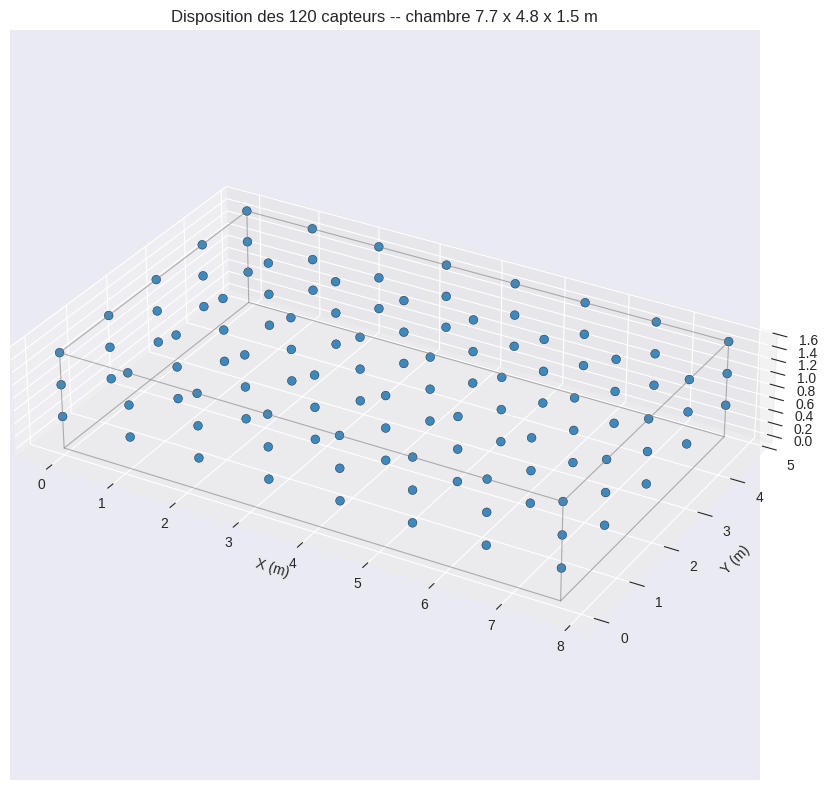

In [18]:
# --- Visualisation 3D de la disposition des 120 capteurs ---
X0, X1 = 0, LARGEUR_M
Y0, Y1 = 0, LONGUEUR_M
Z0, Z1 = 0, HAUTEUR_M
aretes_chambre = [
    ([X0, X1], [Y0, Y0], [Z0, Z0]), ([X0, X1], [Y1, Y1], [Z0, Z0]),
    ([X0, X0], [Y0, Y1], [Z0, Z0]), ([X1, X1], [Y0, Y1], [Z0, Z0]),
    ([X0, X1], [Y0, Y0], [Z1, Z1]), ([X0, X1], [Y1, Y1], [Z1, Z1]),
    ([X0, X0], [Y0, Y1], [Z1, Z1]), ([X1, X1], [Y0, Y1], [Z1, Z1]),
    ([X0, X0], [Y0, Y0], [Z0, Z1]), ([X1, X1], [Y0, Y0], [Z0, Z1]),
    ([X0, X0], [Y1, Y1], [Z0, Z1]), ([X1, X1], [Y1, Y1], [Z0, Z1]),
]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(positions_df['x_m'], positions_df['y_m'], positions_df['z_m'],
           c='tab:blue', s=40, alpha=0.85, edgecolor='k', linewidth=0.3)
for xs, ys, zs in aretes_chambre:
    ax.plot(xs, ys, zs, color='gray', linewidth=0.8, alpha=0.6)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
ax.set_title(f'Disposition des {N_CAPTEURS} capteurs -- chambre '
             f'{LARGEUR_M:.1f} x {LONGUEUR_M:.1f} x {HAUTEUR_M:.1f} m')
ax.set_box_aspect((LARGEUR_M, LONGUEUR_M, HAUTEUR_M))
plt.tight_layout()
plt.show()

In [19]:
# --- Zones a faible densite de capteurs (distance au plus proche voisin) ---
coords_all_m = positions_df[['x_m', 'y_m', 'z_m']].values
arbre_tous_capteurs = cKDTree(coords_all_m)
d_nn, _ = arbre_tous_capteurs.query(coords_all_m, k=2)  # k=1 = lui-meme (distance 0)
positions_df['dist_voisin_le_plus_proche'] = d_nn[:, 1]

print('Distance au voisin le plus proche -- statistiques (m) :')
print(positions_df['dist_voisin_le_plus_proche'].describe().round(3))

seuil_isolement = positions_df['dist_voisin_le_plus_proche'].quantile(0.9)
zones_faible_densite = positions_df[positions_df['dist_voisin_le_plus_proche'] >= seuil_isolement]
print(f'\n{len(zones_faible_densite)} capteurs les plus isoles '
      f'(distance au voisin >= {seuil_isolement:.2f} m, 90e percentile) :')
print(zones_faible_densite[['capteur', 'x', 'y', 'z', 'dist_voisin_le_plus_proche']]
      .sort_values('dist_voisin_le_plus_proche', ascending=False).to_string(index=False))
print('\n-> Ce sont typiquement les capteurs de coin / bord de la grille : moins de voisins')
print('   proches disponibles pour l\'interpolation spatiale (IDW, GPR, plus proches voisins).')

Distance au voisin le plus proche -- statistiques (m) :
count    120.0
mean       0.5
std        0.0
min        0.5
25%        0.5
50%        0.5
75%        0.5
max        0.5
Name: dist_voisin_le_plus_proche, dtype: float64

120 capteurs les plus isoles (distance au voisin >= 0.50 m, 90e percentile) :
 capteur  x  y  z  dist_voisin_le_plus_proche
       1  0  0  0                         0.5
       2  0  0  1                         0.5
       3  0  0  2                         0.5
       4  1  0  0                         0.5
       5  1  0  1                         0.5
       6  1  0  2                         0.5
       7  2  0  0                         0.5
       8  2  0  1                         0.5
       9  2  0  2                         0.5
      10  3  0  0                         0.5
      11  3  0  1                         0.5
      12  3  0  2                         0.5
      13  4  0  0                         0.5
      14  4  0  1                         0.5
      

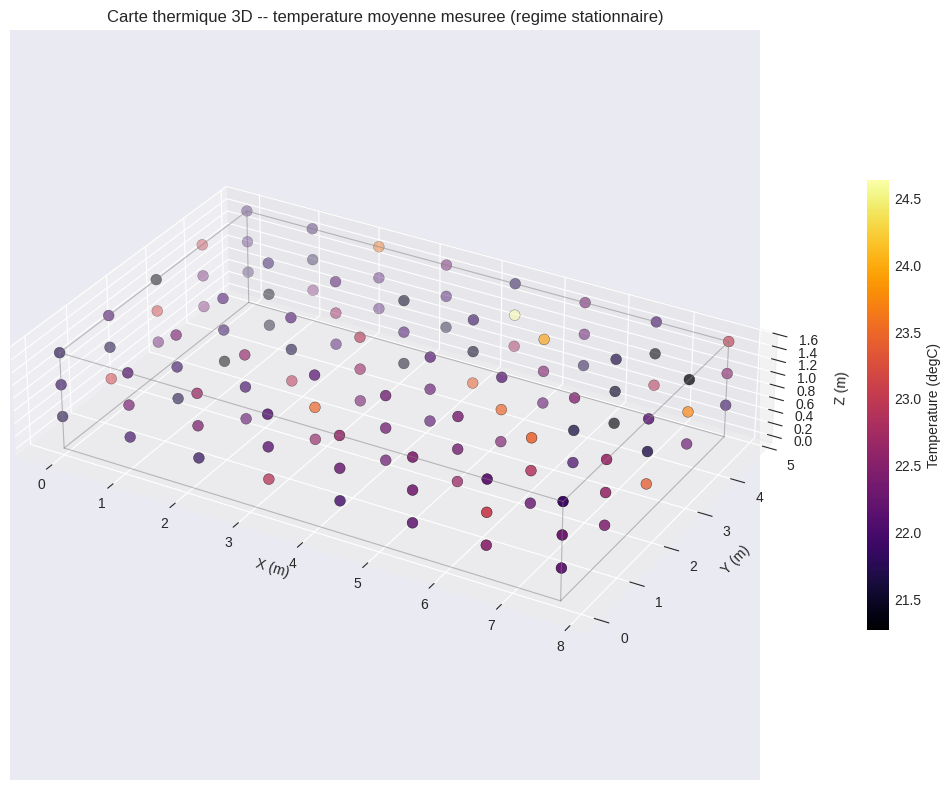

count    120.00
mean      22.25
std        0.60
min       21.27
25%       21.85
50%       22.16
75%       22.51
max       24.63
Name: temp_moyenne, dtype: float64


In [20]:
# --- Carte thermique 3D (temperature moyenne mesuree, regime stationnaire) ---
if 'df_fusion' in globals() and 'phase' in df_fusion.columns and (df_fusion['phase'] == 'stationnaire').any():
    temp_moy_capteur = (df_fusion[df_fusion['phase'] == 'stationnaire']
                         .groupby(['x', 'y', 'z'])['temperature'].mean()
                         .rename('temp_moyenne').reset_index())
    carte_df = positions_df.merge(temp_moy_capteur, on=['x', 'y', 'z'], how='left')

    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(carte_df['x_m'], carte_df['y_m'], carte_df['z_m'],
                     c=carte_df['temp_moyenne'], cmap='inferno', s=60,
                     edgecolor='k', linewidth=0.3)
    for xs, ys, zs in aretes_chambre:
        ax.plot(xs, ys, zs, color='gray', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.set_zlabel('Z (m)')
    ax.set_title('Carte thermique 3D -- temperature moyenne mesuree (regime stationnaire)')
    ax.set_box_aspect((LARGEUR_M, LONGUEUR_M, HAUTEUR_M))
    cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
    cbar.set_label('Temperature (degC)')
    plt.tight_layout()
    plt.show()

    print(carte_df['temp_moyenne'].describe().round(2))
else:
    print('Pas de temperatures stationnaires disponibles pour la carte thermique -> section ignoree.')

### Variables spatiales exploitables pour l'apprentissage

- **Coordonnées brutes** `x, y, z` (indices) ou `x_m, y_m, z_m` (mètres) : position absolue dans la grille.
- **Distances aux parois** `dist_edge_x, dist_edge_y, dist_edge_z` : proximité d'une surface (effets de bord thermique — pertes par les murs/fenêtres).
- **Distance au centre** `dist_center` : capture un éventuel gradient radial (ex. autour d'un point chaud central).
- **Voisins les plus proches** `dist_voisin_proche`, `temp_voisins_idw` : interpolation locale pondérée par distance inverse (IDW) — déjà intégrée aux features du modèle stationnaire.
- **Distance aux sources CVC** `dist_froid`, `dist_chaud`, `influence_froid`, `influence_chaud` : effet direct du chauffage/climatisation identifié sur le plan.
- **Autres variables spatiales pertinentes possibles** :
  - hauteur relative normalisée `z_m / HAUTEUR_M` (stratification thermique, souvent non linéaire avec l'altitude) ;
  - densité locale de capteurs (nombre de voisins dans un rayon donné) — utile pour pondérer la confiance du modèle ;
  - proximité aux fenêtres / portes si leurs positions sont connues (pertes thermiques additionnelles) ;
  - indices de symétrie par rapport aux axes de la pièce, si la géométrie du chauffage est symétrique.

Ces variables (déjà injectées dans `FEATURES_GEOMETRIE_CVC` et les features de voisins) sont
celles utilisées ci-dessous pour entraîner et comparer les modèles **ExtraTrees** et
**Gaussian Process** du régime stationnaire.

## 13 — Comparatif ExtraTrees / Gaussian Process — régime STATIONNAIRE (interprétation spatiale)

Régime où la température ne dérive plus dans le temps : **`t_sec` n'est pas une feature**.
Chaque modèle doit **déduire la température des points non mesurés à partir des points mesurés**
(pas de fuite : on retire de l'entraînement un sous-ensemble entier de **positions**,
jamais de simples lignes, sinon le modèle « trouverait » ses réponses en train).

On entraîne **ExtraTrees** (features géométrie + CVC + voisins IDW + trajectoire/chauffage one-hot)
et un **Gaussian Process spatial** (coordonnées réelles x, y, z, par `heating_type`) sur le même
split spatial, puis on compare.

In [21]:
def obtenir_modeles_standard(random_state=42, rapide=False):
    """Dictionnaire {nom: instance de modele fraiche} pour le comparatif ExtraTrees / GaussianProcess.
    rapide=True -> hyperparametres allege (utilise pour le test de stabilite multi-seeds).
    Le Gaussian Process spatial est gere a part (voir entrainer_gpr_spatial ci-dessous),
    car il a besoin de positions agregees par heating_type plutot que de la matrice X classique."""
    n_est = 150 if rapide else 300
    modeles = {
        'ExtraTrees': ExtraTreesRegressor(
            n_estimators=n_est, max_depth=20, min_samples_leaf=2,
            random_state=random_state, n_jobs=-1),
    }
    return modeles


# Noyau du Gaussian Process spatial (position x, y, z reelles -> temperature),
# entraine separement par heating_type (le champ thermique depend fortement du
# chauffage actif). Un GPR ne passe pas a l'echelle sur des centaines de milliers
# de lignes brutes -> on l'entraine sur les positions AGREGEES (moyenne par
# position x chauffage), ce qui correspond exactement a la tache d'interpolation
# spatiale d'un champ lisse.
kernel_gpr = (ConstantKernel(1.0, (1e-2, 1e3)) *
              RBF(length_scale=[1.0, 1.0, 0.5], length_scale_bounds=(1e-2, 1e2)) +
              WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e2)))


def entrainer_gpr_spatial(df_train_pos, df_test_pos, y_train_fallback, random_state=42,
                           n_restarts=3, retourner_std=False):
    """Entraine un GPR par heating_type sur les positions d'entrainement agregees
    (x, y, z reels en metres), puis predit sur df_test_pos (colonnes x, y, z,
    heating_type). Repli sur la moyenne d'entrainement si un chauffage test est
    absent du train. Si retourner_std=True, renvoie aussi l'ecart-type predictif
    (incertitude), caracteristique propre au Gaussian Process."""
    modeles_gpr = {}
    for chauff, g in df_train_pos.groupby('heating_type'):
        coords_g = np.column_stack([
            g['x'].values * ESPACEMENT_X, g['y'].values * ESPACEMENT_Y,
            np.array(ALTITUDES_Z)[g['z'].values.astype(int)],
        ])
        gpr = GaussianProcessRegressor(kernel=kernel_gpr, normalize_y=True,
                                        n_restarts_optimizer=n_restarts,
                                        random_state=random_state)
        gpr.fit(coords_g, g['temperature'].values)
        modeles_gpr[chauff] = gpr

    preds = np.full(len(df_test_pos), np.nan)
    stds = np.full(len(df_test_pos), np.nan)
    for chauff, gpr in modeles_gpr.items():
        m = (df_test_pos['heating_type'] == chauff).values
        if m.sum() == 0:
            continue
        coords_m = np.column_stack([
            df_test_pos.loc[m, 'x'].values * ESPACEMENT_X,
            df_test_pos.loc[m, 'y'].values * ESPACEMENT_Y,
            np.array(ALTITUDES_Z)[df_test_pos.loc[m, 'z'].values.astype(int)],
        ])
        if retourner_std:
            p_m, s_m = gpr.predict(coords_m, return_std=True)
            preds[m] = p_m
            stds[m] = s_m
        else:
            preds[m] = gpr.predict(coords_m)
    preds[np.isnan(preds)] = y_train_fallback.mean()
    if retourner_std:
        stds[np.isnan(stds)] = 0.0
        return preds, modeles_gpr, stds
    return preds, modeles_gpr


def calculer_metriques(y_true, y_pred):
    return dict(
        rmse=np.sqrt(mean_squared_error(y_true, y_pred)),
        mae=mean_absolute_error(y_true, y_pred),
        mape=mean_absolute_percentage_error(y_true, y_pred) * 100,
        r2=r2_score(y_true, y_pred))


def tableau_comparatif(metriques_par_modele):
    """dict {nom_modele: metrics_dict} -> DataFrame trie par R2 decroissant."""
    lignes = [{'Modele': nom, 'RMSE (°C)': m['rmse'], 'MAE (°C)': m['mae'],
               'MAPE (%)': m['mape'], 'R2': m['r2']} for nom, m in metriques_par_modele.items()]
    return pd.DataFrame(lignes).set_index('Modele').sort_values('R2', ascending=False)


def barres_comparatif(df_comp, titre):
    """Barres horizontales RMSE / MAE / MAPE / R2, un panneau par metrique,
    modeles tries par performance (meilleur en haut)."""
    df_plot = df_comp.sort_values('R2', ascending=True)
    fig, axes = plt.subplots(1, 4, figsize=(22, 0.55 * len(df_plot) + 2))
    couleurs = plt.cm.viridis(np.linspace(0.15, 0.9, len(df_plot)))
    for ax, col in zip(axes, ['RMSE (°C)', 'MAE (°C)', 'MAPE (%)', 'R2']):
        ax.barh(df_plot.index, df_plot[col], color=couleurs)
        ax.set_title(col); ax.grid(True, alpha=0.3, axis='x')
    plt.suptitle(titre, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

print('Fonctions du comparatif ExtraTrees / GaussianProcess pretes.')


Fonctions du comparatif ExtraTrees / GaussianProcess pretes.


In [22]:
import time

df_stat = df_fusion[df_fusion['phase'] == 'stationnaire'].reset_index(drop=True)
print(f'Lignes en regime stationnaire : {len(df_stat):,}')

if len(df_stat) < 50:
    print("Pas assez de donnees stationnaires pour entrainer un modele -> section ignoree.")
else:
    t0 = time.time()
    positions_stat = df_stat[['x', 'y', 'z']].drop_duplicates().values
    rng = np.random.RandomState(42)
    idx_perm = rng.permutation(len(positions_stat))
    n_test_pos = max(1, int(0.2 * len(positions_stat)))
    positions_test_df = pd.DataFrame(positions_stat[idx_perm[:n_test_pos]], columns=['x', 'y', 'z'])
    positions_test_df['_is_test'] = True

    # masque VECTORISE via merge au lieu de apply ligne par ligne
    mask_test_stat = df_stat.merge(positions_test_df, on=['x', 'y', 'z'], how='left')['_is_test'].fillna(False).values
    mask_train_stat = ~mask_test_stat
    print(f'  masque test/train calcule en {time.time()-t0:.1f}s')

    print(f'{n_test_pos} positions tenues a l\'ecart de l\'entrainement '
          f'({mask_test_stat.sum():,} lignes test / {mask_train_stat.sum():,} lignes train)')

    K_VOISINS = 4
    temp_moy_train_pos = (df_stat[mask_train_stat]
                           .groupby(['x', 'y', 'z'])['temperature'].mean())
    pos_train_idx = temp_moy_train_pos.index.to_frame(index=False)
    coords_train_m = np.column_stack([
        pos_train_idx['x'].values * ESPACEMENT_X,
        pos_train_idx['y'].values * ESPACEMENT_Y,
        np.array(ALTITUDES_Z)[pos_train_idx['z'].values.astype(int)],
    ])
    temps_train_pos = temp_moy_train_pos.values
    arbre_voisins = cKDTree(coords_train_m)

    def features_voisins(df_pts, k=K_VOISINS, epsilon=1e-6):
        coords_m = np.column_stack([
            df_pts['x'].values * ESPACEMENT_X,
            df_pts['y'].values * ESPACEMENT_Y,
            np.array(ALTITUDES_Z)[df_pts['z'].values.astype(int)],
        ])
        k_eff = min(k, len(coords_train_m))
        dists, idxs = arbre_voisins.query(coords_m, k=k_eff)
        if k_eff == 1:
            dists = dists[:, None]; idxs = idxs[:, None]
        poids = 1.0 / (dists + epsilon)
        temp_idw = (poids * temps_train_pos[idxs]).sum(axis=1) / poids.sum(axis=1)
        dist_plus_proche = dists[:, 0]
        return temp_idw, dist_plus_proche

    df_stat['temp_voisins_idw'], df_stat['dist_voisin_proche'] = features_voisins(df_stat)

    FEATURES_STATIONNAIRE = FEATURES_GEOMETRIE_CVC + FEATURES_CATEGORIELLES + \
        ['temp_voisins_idw', 'dist_voisin_proche']

    X_stat = df_stat[FEATURES_STATIONNAIRE].values.astype(float)
    y_stat = df_stat['temperature'].values.astype(float)

    scaler_stat = StandardScaler()
    X_stat_scaled = scaler_stat.fit_transform(X_stat)

    Xtr_stat, Xte_stat = X_stat_scaled[mask_train_stat], X_stat_scaled[mask_test_stat]
    ytr_stat, yte_stat = y_stat[mask_train_stat], y_stat[mask_test_stat]
    print(f'  Xtr_stat: {Xtr_stat.shape}')

    # ---- Entrainement de TOUS les modeles standards, avec sous-echantillonnage pour SVR ----
    SVR_MAX_TRAIN = 5000  # SVR est O(n^2)-O(n^3) -> hors de cette taille ca peut sembler bloque
    predictions_stat = {}
    metriques_stat_tous = {}
    for nom, modele in obtenir_modeles_standard(random_state=42).items():
        t_m = time.time()
        if nom == 'SVR (RBF)' and len(Xtr_stat) > SVR_MAX_TRAIN:
            idx_sub = np.random.RandomState(42).choice(len(Xtr_stat), SVR_MAX_TRAIN, replace=False)
            modele.fit(Xtr_stat[idx_sub], ytr_stat[idx_sub])
            print(f'    (SVR sous-echantillonne a {SVR_MAX_TRAIN} lignes sur {len(Xtr_stat)})')
        else:
            modele.fit(Xtr_stat, ytr_stat)
        pred = modele.predict(Xte_stat)
        predictions_stat[nom] = pred
        metriques_stat_tous[nom] = calculer_metriques(yte_stat, pred)
        print(f'  {nom:20s} entraine en {time.time()-t_m:5.1f}s -- R2={metriques_stat_tous[nom]["r2"]:.4f}')

    # ---- Gaussian Process spatial (position x, y, z x heating_type) ----
    t_gpr = time.time()
    df_stat_pos_agg = (df_stat[mask_train_stat]
                        .groupby(['x', 'y', 'z', 'heating_type'])['temperature']
                        .mean().reset_index())
    df_stat_test_pos = df_stat.loc[mask_test_stat, ['x', 'y', 'z', 'heating_type']]
    pred_gpr, modeles_gpr_stat = entrainer_gpr_spatial(
        df_stat_pos_agg, df_stat_test_pos, ytr_stat, random_state=42, n_restarts=3)
    predictions_stat['GaussianProcess (spatial)'] = pred_gpr
    metriques_stat_tous['GaussianProcess (spatial)'] = calculer_metriques(yte_stat, pred_gpr)
    print(f'  {"GaussianProcess (spatial)":20s} entraine en {time.time()-t_gpr:5.1f}s -- '
          f'R2={metriques_stat_tous["GaussianProcess (spatial)"]["r2"]:.4f}')

    comparaison_stat = tableau_comparatif(metriques_stat_tous)
    print()
    print('Comparaison des modeles STATIONNAIRE (interpolation spatiale) :')
    display(comparaison_stat.round(4))

    NOM_MODELE_STATIONNAIRE = comparaison_stat.index[0]
    pred_stat = predictions_stat[NOM_MODELE_STATIONNAIRE]
    metrics_stat = metriques_stat_tous[NOM_MODELE_STATIONNAIRE]

    print(f'\n>>> Modele retenu pour la carte thermique : {NOM_MODELE_STATIONNAIRE}')
    print(f"Modele STATIONNAIRE - RMSE={metrics_stat['rmse']:.4f}C  "
          f"MAE={metrics_stat['mae']:.4f}C  MAPE={metrics_stat['mape']:.2f}%  R2={metrics_stat['r2']:.4f}")

    df_stat_test = df_stat.loc[mask_test_stat, ['x', 'y', 'z', 'trajectory_type', 'heating_type']].copy()
    df_stat_test['reel'] = yte_stat
    df_stat_test['predit'] = pred_stat
    df_stat_test['erreur_abs'] = np.abs(df_stat_test['reel'] - df_stat_test['predit'])

Lignes en regime stationnaire : 761,796
  masque test/train calcule en 0.3s
24 positions tenues a l'ecart de l'entrainement (149,728 lignes test / 612,068 lignes train)
  Xtr_stat: (612068, 27)
  ExtraTrees           entraine en 827.7s -- R2=-0.0384
  GaussianProcess (spatial) entraine en   4.6s -- R2=-0.0059

Comparaison des modeles STATIONNAIRE (interpolation spatiale) :


,RMSE (°C),MAE (°C),MAPE (%),R2
Modele,,,,
GaussianProcess (spatial),2.5074,1.9167,8.1647,-0.0059
ExtraTrees,2.5475,2.0098,8.6152,-0.0384



>>> Modele retenu pour la carte thermique : GaussianProcess (spatial)
Modele STATIONNAIRE - RMSE=2.5074C  MAE=1.9167C  MAPE=8.16%  R2=-0.0059


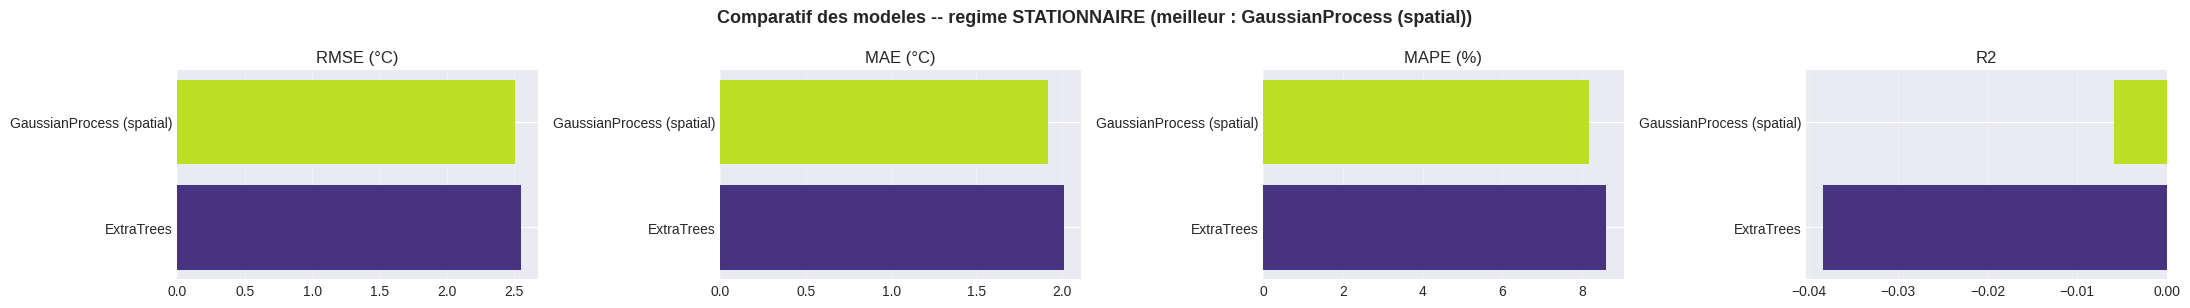

In [23]:
if len(df_stat) >= 50:
    barres_comparatif(comparaison_stat,
        f'Comparatif des modeles -- regime STATIONNAIRE (meilleur : {NOM_MODELE_STATIONNAIRE})')
else:
    print('Pas assez de donnees pour le comparatif stationnaire.')

### 13bis — Non-stationnarisation artificielle du régime stationnaire (ajout d'une tendance)

**Hypothèse à tester :** le modèle est-il meilleur en régime instationnaire *parce que le signal est
non stationnaire*, ou pour d'autres raisons (gradient thermique, densité spatiale, information de
voisinage, capacité du modèle) ?

Parmi les 3 méthodes candidates pour transformer artificiellement une série stationnaire en série
non stationnaire — intégration cumulative `Y(t) = Σ X(i)`, ajout d'une tendance `Y(t) = X(t) + a·t`,
ajout d'une composante périodique `Y(t) = X(t) + A·sin(ωt)` — on retient ici **l'ajout d'une tendance
linéaire**, la plus proche d'un phénomène thermique réel (dérive lente d'un chauffage/climatisation
qui n'a pas encore atteint son régime permanent), donc la plus interprétable physiquement. `t_sec`
existe déjà pour les lignes stationnaires (juste postérieur à `t_bascule`) : on l'utilise tel quel,
recentré à 0, au lieu d'inventer un temps synthétique.

On réentraîne **ExtraTrees et le Gaussian Process** (celui-ci reçoit `t_rel` comme 4e dimension
d'entrée, en plus de x, y, z) sur `temperature_tendance = temperature + a · t_rel`, avec le **même
split spatial** que la section 13, et on compare le R² obtenu à celui du régime stationnaire brut
(section 13) et à celui du régime instationnaire réel (section 14). Si le R² « stationnaire + tendance »
rejoint celui de l'instationnaire, cela confirme que l'écart vient bien de la disponibilité d'une
variable temporelle informative — pas d'une propriété magique de la « non-stationnarité » en soi.

In [24]:
if len(df_stat) < 50:
    print("Pas assez de donnees stationnaires -> experience de non-stationnarisation ignoree.")
elif df_stat['t_sec'].notna().sum() < 50:
    print("Pas assez de lignes stationnaires avec un t_sec reel (mesure) "
          "-> experience de non-stationnarisation ignoree.")
else:
    # Certaines lignes stationnaires proviennent de trajectoires simulees / CSV additionnels
    # (sections 8-9) sans timestamp reel -> t_sec est NaN pour ces lignes. On les exclut de
    # cette experience : ajouter une tendance temporelle n'a de sens que sur des points ou
    # le temps est reellement mesure.
    n_avant = len(df_stat)
    df_tend = df_stat.dropna(subset=['t_sec']).copy()
    n_apres = len(df_tend)
    if n_avant != n_apres:
        print(f"{n_avant - n_apres} lignes sans t_sec reel exclues "
              f"({n_apres} lignes conservees sur {n_avant}).")

    df_tend['t_rel'] = df_tend['t_sec'] - df_tend['t_sec'].min()
    duree_s = df_tend['t_rel'].max()

    # Amplitude de la tendance choisie par rapport a la donnee plutot qu'en dur :
    # on vise une derive totale modeste (~30% de l'ecart-type des temperatures),
    # pour rester une perturbation raisonnable et non un artefact numerique.
    DERIVE_CIBLE = 0.30 * df_tend['temperature'].std()
    A_TENDANCE = DERIVE_CIBLE / duree_s if duree_s > 0 else 0.0
    df_tend['temperature_tendance'] = df_tend['temperature'] + A_TENDANCE * df_tend['t_rel']

    print(f"Tendance ajoutee : a={A_TENDANCE:.5f} degC/s (calcule pour une derive cible de "
          f"{DERIVE_CIBLE:.2f} degC), duree stationnaire ~{duree_s:.0f}s -> "
          f"derive max ~{A_TENDANCE * duree_s:.2f} degC")

    # Sous-ensembles dedies (ne pas ecraser mask_train_stat/mask_test_stat, utilises ailleurs)
    mask_notna_t = df_stat['t_sec'].notna().values
    mask_train_tend = mask_train_stat[mask_notna_t] if n_avant != n_apres else mask_train_stat
    mask_test_tend = mask_test_stat[mask_notna_t] if n_avant != n_apres else mask_test_stat

    FEATURES_TENDANCE = FEATURES_STATIONNAIRE + ['t_rel']
    X_tend = df_tend[FEATURES_TENDANCE].values.astype(float)
    y_tend = df_tend['temperature_tendance'].values.astype(float)

    scaler_tend = StandardScaler()
    X_tend_scaled = scaler_tend.fit_transform(X_tend)

    # Meme split spatial (positions) que la section 13, pour une comparaison equitable
    Xtr_tend, Xte_tend = X_tend_scaled[mask_train_tend], X_tend_scaled[mask_test_tend]
    ytr_tend, yte_tend = y_tend[mask_train_tend], y_tend[mask_test_tend]

    predictions_tend = {}
    metriques_tend_tous = {}

    for nom, modele in obtenir_modeles_standard(random_state=42).items():
        modele.fit(Xtr_tend, ytr_tend)
        pred = modele.predict(Xte_tend)
        predictions_tend[nom] = pred
        metriques_tend_tous[nom] = calculer_metriques(yte_tend, pred)
        print(f"  {nom:20s} (stationnaire+tendance) -- R2={metriques_tend_tous[nom]['r2']:.4f}")

    # --- Gaussian Process spatio-temporel : x, y, z, t_rel -> temperature_tendance ---
    # IMPORTANT : t_rel est quasi-continu (un timestamp different par mesure). Grouper
    # par (x, y, z, heating_type, t_rel) tel quel n'agregerait presque rien : chaque
    # groupe resterait ~unique -> le GPR (cout O(n^3)) se retrouverait a s'entrainer sur
    # des milliers de points et deviendrait tres lent, voire bloquerait le notebook.
    # On discretise donc le temps en N_BINS_T intervalles avant d'agreger, ce qui borne
    # le nombre de points d'entrainement quelle que soit la taille brute des donnees,
    # tout en conservant assez de resolution temporelle pour capter la tendance ajoutee.
    N_BINS_T = min(30, df_tend['t_rel'].nunique())
    N_MAX_PAR_CHAUFFAGE = 800  # garde-fou : sous-echantillonnage si un groupe reste trop gros

    kernel_gpr_t = (ConstantKernel(1.0, (1e-2, 1e3)) *
                     RBF(length_scale=[1.0, 1.0, 0.5, 60.0], length_scale_bounds=(1e-2, 1e4)) +
                     WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e2)))

    df_train_pos_t = df_tend[mask_train_tend].copy()
    df_train_pos_t['t_bin'] = pd.cut(df_train_pos_t['t_rel'], bins=N_BINS_T, labels=False)

    agg_t = (df_train_pos_t.groupby(['x', 'y', 'z', 'heating_type', 't_bin'], observed=True)
             .agg(temperature_tendance=('temperature_tendance', 'mean'),
                  t_rel=('t_rel', 'mean'))
             .reset_index())
    print(f"GPR spatio-temporel : {len(df_train_pos_t):,} lignes brutes -> "
          f"{len(agg_t):,} points agreges (t discretise en {N_BINS_T} intervalles).")

    modeles_gpr_t = {}
    rng = np.random.default_rng(42)
    for chauff, g in agg_t.groupby('heating_type'):
        if len(g) > N_MAX_PAR_CHAUFFAGE:
            idx_sample = rng.choice(len(g), size=N_MAX_PAR_CHAUFFAGE, replace=False)
            g = g.iloc[idx_sample]
            print(f"  chauffage={chauff!r} : {len(g):,} points -> sous-echantillonne a "
                  f"{N_MAX_PAR_CHAUFFAGE} pour rester rapide.")
        coords_g = np.column_stack([
            g['x'].values * ESPACEMENT_X, g['y'].values * ESPACEMENT_Y,
            np.array(ALTITUDES_Z)[g['z'].values.astype(int)], g['t_rel'].values,
        ])
        gpr_t = GaussianProcessRegressor(kernel=kernel_gpr_t, normalize_y=True,
                                          n_restarts_optimizer=3, random_state=42)
        gpr_t.fit(coords_g, g['temperature_tendance'].values)
        modeles_gpr_t[chauff] = gpr_t

    df_test_pos_t = df_tend.loc[mask_test_tend, ['x', 'y', 'z', 'heating_type', 't_rel']]
    pred_gpr_t = np.full(len(df_test_pos_t), np.nan)
    for chauff, gpr_t in modeles_gpr_t.items():
        m = (df_test_pos_t['heating_type'] == chauff).values
        if m.sum() == 0:
            continue
        coords_m = np.column_stack([
            df_test_pos_t.loc[m, 'x'].values * ESPACEMENT_X,
            df_test_pos_t.loc[m, 'y'].values * ESPACEMENT_Y,
            np.array(ALTITUDES_Z)[df_test_pos_t.loc[m, 'z'].values.astype(int)],
            df_test_pos_t.loc[m, 't_rel'].values,
        ])
        pred_gpr_t[m] = gpr_t.predict(coords_m)
    pred_gpr_t[np.isnan(pred_gpr_t)] = ytr_tend.mean()

    predictions_tend['GaussianProcess (spatio-temporel)'] = pred_gpr_t
    metriques_tend_tous['GaussianProcess (spatio-temporel)'] = calculer_metriques(yte_tend, pred_gpr_t)
    print(f"  {'GaussianProcess (spatio-temporel)':20s} (stationnaire+tendance) -- "
          f"R2={metriques_tend_tous['GaussianProcess (spatio-temporel)']['r2']:.4f}")

    comparaison_tend = tableau_comparatif(metriques_tend_tous)
    print()
    print('Comparaison des modeles -- STATIONNAIRE + TENDANCE ARTIFICIELLE :')
    display(comparaison_tend.round(4))

    # Comparaison directe avec le stationnaire brut (section 13) et l'instationnaire (section 14)
    lignes_bilan = []
    if 'metriques_stat_tous' in globals():
        for nom, m in metriques_stat_tous.items():
            lignes_bilan.append({'Regime': 'Stationnaire (brut)', 'Modele': nom, 'R2': m['r2']})
    for nom, m in metriques_tend_tous.items():
        lignes_bilan.append({'Regime': 'Stationnaire + tendance', 'Modele': nom, 'R2': m['r2']})
    if 'metriques_inst_tous' in globals():
        for nom, m in metriques_inst_tous.items():
            lignes_bilan.append({'Regime': 'Instationnaire (reel)', 'Modele': nom, 'R2': m['r2']})

    if len(lignes_bilan) > 0:
        df_bilan = pd.DataFrame(lignes_bilan)
        print()
        print("Bilan -- effet de la variable temporelle sur le R2, par regime :")
        display(df_bilan.pivot_table(index='Modele', columns='Regime', values='R2'))
        print()
        print("Interpretation : si le R2 'Stationnaire + tendance' se rapproche du R2 'Instationnaire',")
        print("le gain de performance en regime instationnaire vient surtout de la disponibilite d'une")
        print("variable temporelle correlee a la cible -- pas d'une propriete intrinseque de la")
        print("non-stationnarite. Un ecart residuel avec 'Instationnaire (reel)' pointe plutot vers le")
        print("gradient thermique reel, la densite spatiale des mesures, ou l'information de voisinage.")


342 lignes sans t_sec reel exclues (761454 lignes conservees sur 761796).
Tendance ajoutee : a=0.00004 degC/s (calcule pour une derive cible de 0.75 degC), duree stationnaire ~17020s -> derive max ~0.75 degC
  ExtraTrees           (stationnaire+tendance) -- R2=0.8080
GPR spatio-temporel : 611,790 lignes brutes -> 18,240 points agreges (t discretise en 30 intervalles).
  chauffage='convecteur_electrique' : 800 points -> sous-echantillonne a 800 pour rester rapide.
  chauffage='mesure_principale' : 800 points -> sous-echantillonne a 800 pour rester rapide.
  chauffage='plancher_chauffant_electrique' : 800 points -> sous-echantillonne a 800 pour rester rapide.
  chauffage='plinthe_electrique' : 800 points -> sous-echantillonne a 800 pour rester rapide.
  chauffage='pompe_a_chaleur_air_air' : 800 points -> sous-echantillonne a 800 pour rester rapide.
  chauffage='radiateur_eau_chaude' : 800 points -> sous-echantillonne a 800 pour rester rapide.
  chauffage='ventiloconvecteur' : 800 points 

,RMSE (°C),MAE (°C),MAPE (%),R2
Modele,,,,
ExtraTrees,1.0424,0.7043,3.0751,0.8080
GaussianProcess (spatio-temporel),2.2030,1.6059,6.7228,0.1424



Bilan -- effet de la variable temporelle sur le R2, par regime :


Regime,Stationnaire (brut),Stationnaire + tendance
Modele,,
ExtraTrees,-0.038415,0.807968
GaussianProcess (spatial),-0.005913,NaN
GaussianProcess (spatio-temporel),NaN,0.142357



Interpretation : si le R2 'Stationnaire + tendance' se rapproche du R2 'Instationnaire',
le gain de performance en regime instationnaire vient surtout de la disponibilite d'une
variable temporelle correlee a la cible -- pas d'une propriete intrinseque de la
non-stationnarite. Un ecart residuel avec 'Instationnaire (reel)' pointe plutot vers le
gradient thermique reel, la densite spatiale des mesures, ou l'information de voisinage.


### 13ter — Stabilité du split spatial (multi-seeds)

Le split précédent ne tient à l'écart que ~20% des positions (souvent une vingtaine sur ~150).
Avec si peu de positions test, le R² peut beaucoup varier selon le tirage aléatoire.
On répète ici le split + l'entraînement d'**ExtraTrees et du Gaussian Process** avec plusieurs
`random_state` différents, pour voir si le classement observé plus haut est **systématique** ou
**un artefact de chance** sur un tirage particulier.

seed   0 termine en 397.5s
seed   1 termine en 447.5s
seed   2 termine en 464.0s
seed   3 termine en 478.8s
seed   7 termine en 415.7s
seed  21 termine en 511.2s
seed  42 termine en 373.6s
seed  99 termine en 404.0s

Total: 3492.2s

R2 du modele stationnaire selon le tirage (random_state) :


,n_positions_test,ExtraTrees,GaussianProcess (spatial)
seed,,,
0,24,-0.0261,0.0023
1,24,-0.0298,-0.0021
2,24,-0.0577,0.0065
3,24,-0.0297,-0.0076
7,24,-0.0319,-0.0004
21,24,-0.0267,0.0085
42,24,-0.0384,-0.0059
99,24,-0.0445,-0.0036



Classement moyen sur les 8 tirages :


,R2 moyen,Ecart-type R2
GaussianProcess (spatial),-0.0003,0.0057
ExtraTrees,-0.0356,0.0109


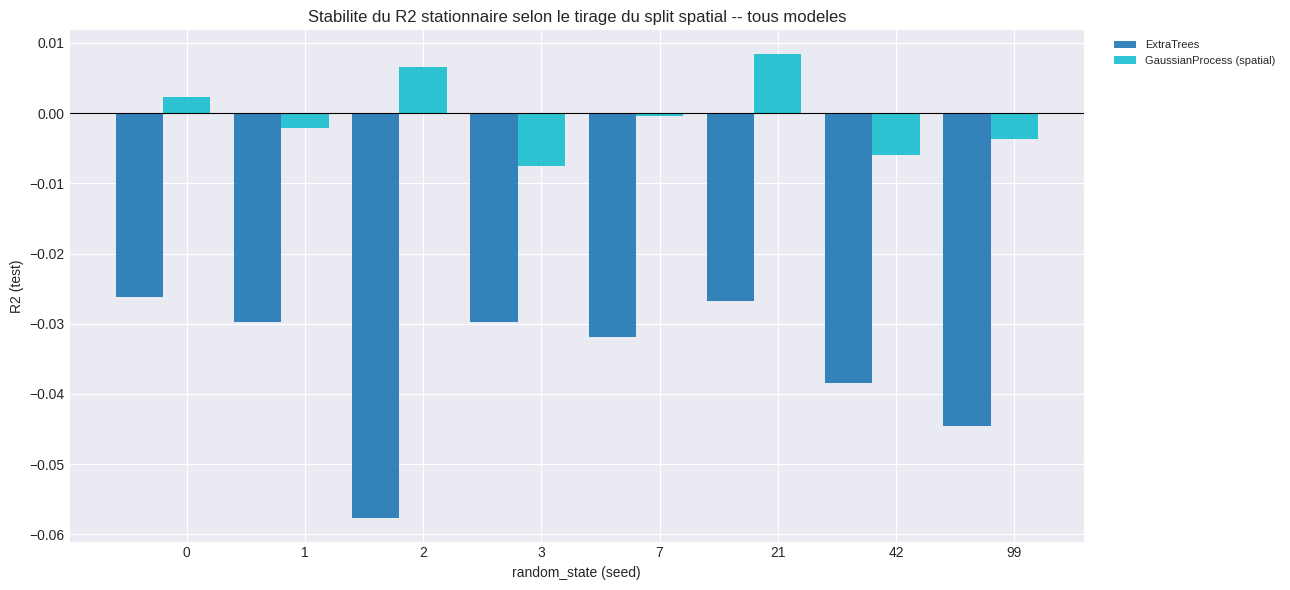

In [25]:
import time

if len(df_stat) < 50:
    print('Pas assez de donnees stationnaires -> verification de stabilite ignoree.')
else:
    SEEDS = [0, 1, 2, 3, 7, 21, 42, 99]
    K_VOISINS_STAB = K_VOISINS
    SVR_MAX_TRAIN = 5000
    resultats_seeds = []

    positions_stat_all = df_stat[['x', 'y', 'z']].drop_duplicates().values

    # invariant sur tous les seeds -> calcule une seule fois
    coords_all_s = np.column_stack([
        df_stat['x'].values * ESPACEMENT_X,
        df_stat['y'].values * ESPACEMENT_Y,
        np.array(ALTITUDES_Z)[df_stat['z'].values.astype(int)],
    ])

    t_total = time.time()
    for seed in SEEDS:
        t_seed = time.time()
        rng_s = np.random.RandomState(seed)
        idx_perm_s = rng_s.permutation(len(positions_stat_all))
        n_test_pos_s = max(1, int(0.2 * len(positions_stat_all)))
        pos_test_df_s = pd.DataFrame(positions_stat_all[idx_perm_s[:n_test_pos_s]], columns=['x', 'y', 'z'])
        pos_test_df_s['_is_test'] = True

        # masque vectorise (merge) au lieu de apply ligne par ligne
        mask_test_s = df_stat.merge(pos_test_df_s, on=['x', 'y', 'z'], how='left')['_is_test'].fillna(False).values
        mask_train_s = ~mask_test_s

        temp_moy_train_s = df_stat[mask_train_s].groupby(['x', 'y', 'z'])['temperature'].mean()
        pos_train_idx_s = temp_moy_train_s.index.to_frame(index=False)
        coords_train_s = np.column_stack([
            pos_train_idx_s['x'].values * ESPACEMENT_X,
            pos_train_idx_s['y'].values * ESPACEMENT_Y,
            np.array(ALTITUDES_Z)[pos_train_idx_s['z'].values.astype(int)],
        ])
        temps_train_s = temp_moy_train_s.values
        arbre_s = cKDTree(coords_train_s)

        k_eff_s = min(K_VOISINS_STAB, len(coords_train_s))
        dists_s, idxs_s = arbre_s.query(coords_all_s, k=k_eff_s)
        if k_eff_s == 1:
            dists_s = dists_s[:, None]; idxs_s = idxs_s[:, None]
        poids_s = 1.0 / (dists_s + 1e-6)
        temp_idw_s = (poids_s * temps_train_s[idxs_s]).sum(axis=1) / poids_s.sum(axis=1)
        dist_proche_s = dists_s[:, 0]

        df_stat_s = df_stat.copy()
        df_stat_s['temp_voisins_idw'] = temp_idw_s
        df_stat_s['dist_voisin_proche'] = dist_proche_s

        X_s = df_stat_s[FEATURES_STATIONNAIRE].values.astype(float)
        y_s = df_stat_s['temperature'].values.astype(float)
        Xs_scaled = StandardScaler().fit_transform(X_s)

        Xtr_s, Xte_s = Xs_scaled[mask_train_s], Xs_scaled[mask_test_s]
        ytr_s, yte_s = y_s[mask_train_s], y_s[mask_test_s]

        ligne_seed = {'seed': seed, 'n_positions_test': len(pos_test_df_s)}

        for nom, modele in obtenir_modeles_standard(random_state=seed, rapide=True).items():
            if nom == 'SVR (RBF)' and len(Xtr_s) > SVR_MAX_TRAIN:
                idx_sub = np.random.RandomState(seed).choice(len(Xtr_s), SVR_MAX_TRAIN, replace=False)
                modele.fit(Xtr_s[idx_sub], ytr_s[idx_sub])
            else:
                modele.fit(Xtr_s, ytr_s)
            ligne_seed[nom] = r2_score(yte_s, modele.predict(Xte_s))

        agg_s = (df_stat_s[mask_train_s].groupby(['x', 'y', 'z', 'heating_type'])['temperature']
                 .mean().reset_index())
        df_test_pts_s = df_stat_s.loc[mask_test_s, ['x', 'y', 'z', 'heating_type']]
        preds_gpr_s, _ = entrainer_gpr_spatial(agg_s, df_test_pts_s, ytr_s,
                                                random_state=seed, n_restarts=1)
        ligne_seed['GaussianProcess (spatial)'] = r2_score(yte_s, preds_gpr_s)

        resultats_seeds.append(ligne_seed)
        print(f'seed {seed:3d} termine en {time.time()-t_seed:5.1f}s')

    print(f'\nTotal: {time.time()-t_total:.1f}s')

    df_stabilite = pd.DataFrame(resultats_seeds).set_index('seed')
    noms_modeles_stab = [c for c in df_stabilite.columns if c != 'n_positions_test']
    print('\nR2 du modele stationnaire selon le tirage (random_state) :')
    display(df_stabilite.round(4))

    resume_stabilite = pd.DataFrame({
        'R2 moyen': df_stabilite[noms_modeles_stab].mean(),
        'Ecart-type R2': df_stabilite[noms_modeles_stab].std(),
    }).sort_values('R2 moyen', ascending=False)
    print('\nClassement moyen sur les', len(SEEDS), 'tirages :')
    display(resume_stabilite.round(4))

    fig, ax = plt.subplots(figsize=(13, 6))
    seeds_x = np.arange(len(df_stabilite))
    n_modeles = len(noms_modeles_stab)
    largeur_barre = 0.8 / n_modeles
    couleurs = plt.cm.tab10(np.linspace(0, 1, n_modeles))
    for i, nom in enumerate(noms_modeles_stab):
        ax.bar(seeds_x + (i - n_modeles / 2) * largeur_barre, df_stabilite[nom],
               largeur_barre, label=nom, color=couleurs[i], alpha=0.9)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(seeds_x); ax.set_xticklabels(df_stabilite.index)
    ax.set_xlabel('random_state (seed)'); ax.set_ylabel('R2 (test)')
    ax.set_title('Stabilite du R2 stationnaire selon le tirage du split spatial -- tous modeles')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

### 13quater — Parité réel vs prédit, ExtraTrees et Gaussian Process

Grille de nuages de points réel vs prédit pour **chaque modèle** entraîné ci-dessus, sur le même
jeu de test spatial. Le modèle retenu (meilleur R²) est mis en évidence.

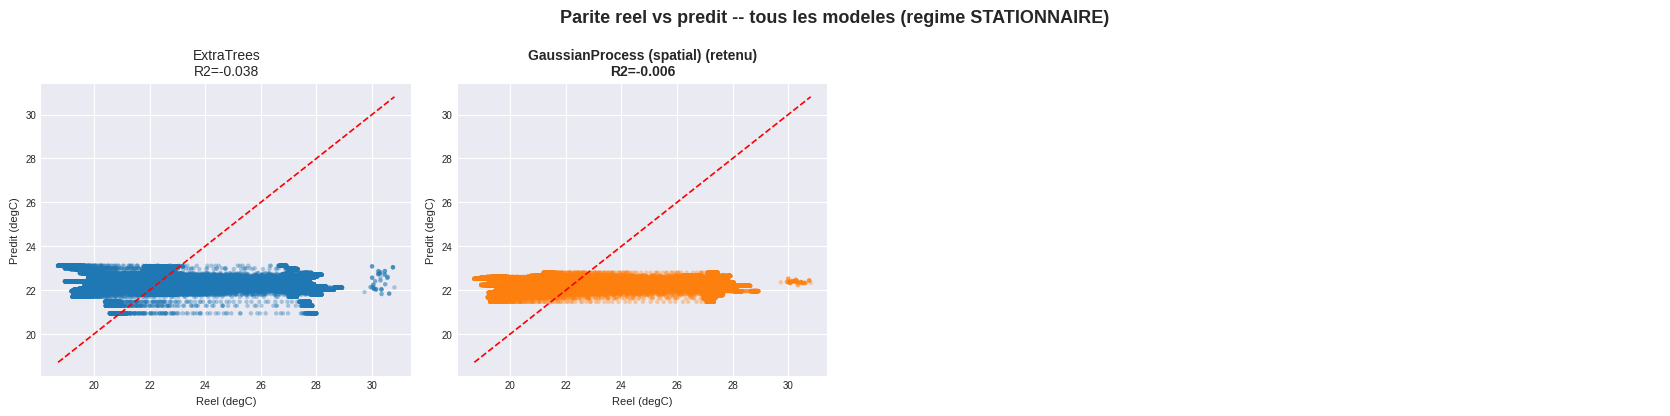

In [26]:
if len(df_stat) >= 50:
    noms_modeles_plot = list(predictions_stat.keys())
    n_modeles = len(noms_modeles_plot)
    n_cols = 4
    n_rows = int(np.ceil(n_modeles / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4.2 * n_rows), squeeze=False)

    for i, nom in enumerate(noms_modeles_plot):
        ax = axes[i // n_cols][i % n_cols]
        pred_m = predictions_stat[nom]
        r2_m = metriques_stat_tous[nom]['r2']
        est_meilleur = (nom == NOM_MODELE_STATIONNAIRE)
        ax.scatter(yte_stat, pred_m, s=10, alpha=0.35,
                   color='tab:orange' if est_meilleur else 'tab:blue', edgecolor='none')
        lim_min = min(yte_stat.min(), pred_m.min()); lim_max = max(yte_stat.max(), pred_m.max())
        ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.2)
        titre_ax = f'{nom}{" (retenu)" if est_meilleur else ""}\nR2={r2_m:.3f}'
        ax.set_title(titre_ax, fontsize=10, fontweight='bold' if est_meilleur else 'normal')
        ax.set_xlabel('Reel (degC)', fontsize=8); ax.set_ylabel('Predit (degC)', fontsize=8)
        ax.tick_params(labelsize=7)

    for j in range(n_modeles, n_rows * n_cols):
        axes[j // n_cols][j % n_cols].axis('off')

    plt.suptitle('Parite reel vs predit -- tous les modeles (regime STATIONNAIRE)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Pas assez de donnees pour la grille de parite.')

## 14 — Comparatif ExtraTrees / Gaussian Process — régime INSTATIONNAIRE (interprétation séquentielle)

Régime encore en dérive : chaque modèle **ne prédit que le point suivant**, à partir du point
précédent **le long de la trajectoire du robot** — distance parcourue entre les deux points
(`dist_prev`) et pas de temps entre deux mesures (`dt_prev`, ~20 s).

Même principe que pour le régime stationnaire : ExtraTrees et le Gaussian Process sont entraînés
sur le même split chronologique et comparés (RMSE, MAE, MAPE, R²).

In [27]:
df_inst = df_fusion[df_fusion['phase'] == 'instationnaire'].reset_index(drop=True)
print(f'Lignes en régime instationnaire : {len(df_inst):,}')

GROUPE_SEQUENCE = ['trajectory_type', 'heating_type']  # une séquence = un parcours du robot
GPR_MAX_TRAIN = 1500  # un GPR est O(n^3) -> on sous-echantillonne l'entrainement au-dela

if len(df_inst) < 50:
    print('Pas assez de données instationnaires pour entraîner un modèle -> section ignorée.')
else:
    df_inst = df_inst.sort_values(GROUPE_SEQUENCE + ['t_sec']).reset_index(drop=True)

    grp = df_inst.groupby(GROUPE_SEQUENCE)
    df_inst['x_prev']    = grp['x'].shift(1)
    df_inst['y_prev']    = grp['y'].shift(1)
    df_inst['z_prev']    = grp['z'].shift(1)
    df_inst['temp_lag1'] = grp['temperature'].shift(1)
    df_inst['t_prev']    = grp['t_sec'].shift(1)

    df_inst['dist_prev'] = np.sqrt(
        (df_inst['x'] - df_inst['x_prev']) ** 2 +
        (df_inst['y'] - df_inst['y_prev']) ** 2 +
        ((df_inst['z'] - df_inst['z_prev']) * ESPACEMENT_Z) ** 2)
    df_inst['dt_prev'] = (df_inst['t_sec'] - df_inst['t_prev']).clip(lower=0)
    df_inst.loc[df_inst['dt_prev'].isna() | (df_inst['dt_prev'] == 0), 'dt_prev'] = PAS_TEMPOREL_SEQ

    df_inst_valide = df_inst.dropna(subset=['temp_lag1', 'dist_prev']).reset_index(drop=True)
    print(f'{len(df_inst_valide):,} points avec un point précédent valide (1 par capteur perdu par séquence)')

    FEATURES_INSTATIONNAIRE = ['x', 'y', 'z', 'dist_prev', 'dt_prev', 'temp_lag1'] + FEATURES_CATEGORIELLES

    X_inst = df_inst_valide[FEATURES_INSTATIONNAIRE].values.astype(float)
    y_inst = df_inst_valide['temperature'].values.astype(float)  # le point "suivant" à prédire

    scaler_inst = StandardScaler()
    X_inst_scaled = scaler_inst.fit_transform(X_inst)

    # Split CHRONOLOGIQUE (les derniers ~20% du temps, par groupe, forment le test)
    train_idx_list, test_idx_list = [], []
    for _, g in df_inst_valide.groupby(GROUPE_SEQUENCE):
        order_g = g['t_sec'].values.argsort(kind='stable')
        idx_g = g.index.values[order_g]
        split_g = max(1, min(len(idx_g) - 1, int(len(idx_g) * 0.8)))
        train_idx_list.extend(idx_g[:split_g]); test_idx_list.extend(idx_g[split_g:])
    train_idx_inst = np.array(train_idx_list); test_idx_inst = np.array(test_idx_list)

    Xtr_inst, Xte_inst = X_inst_scaled[train_idx_inst], X_inst_scaled[test_idx_inst]
    ytr_inst, yte_inst = y_inst[train_idx_inst], y_inst[test_idx_inst]

    # ---- Entrainement de TOUS les modeles standards (memes features/split) ----
    predictions_inst = {}
    metriques_inst_tous = {}
    for nom, modele in obtenir_modeles_standard(random_state=42).items():
        modele.fit(Xtr_inst, ytr_inst)
        pred = modele.predict(Xte_inst)
        predictions_inst[nom] = pred
        metriques_inst_tous[nom] = calculer_metriques(yte_inst, pred)
        print(f'  {nom:20s} entraine -- R2={metriques_inst_tous[nom]["r2"]:.4f}')

    # ---- Gaussian Process sur les memes features (sous-echantillonne si besoin -- O(n^3)) ----
    if len(Xtr_inst) > GPR_MAX_TRAIN:
        rng_gpr = np.random.RandomState(42)
        idx_sub = rng_gpr.choice(len(Xtr_inst), size=GPR_MAX_TRAIN, replace=False)
        Xtr_gpr, ytr_gpr = Xtr_inst[idx_sub], ytr_inst[idx_sub]
        print(f'  GaussianProcess : entrainement sous-echantillonne a {GPR_MAX_TRAIN:,} lignes '
              f'(sur {len(Xtr_inst):,} disponibles).')
    else:
        Xtr_gpr, ytr_gpr = Xtr_inst, ytr_inst

    kernel_gpr_inst = (ConstantKernel(1.0, (1e-2, 1e3)) *
                        RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) +
                        WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e2)))
    gpr_inst = GaussianProcessRegressor(kernel=kernel_gpr_inst, normalize_y=True,
                                         n_restarts_optimizer=2, random_state=42)
    gpr_inst.fit(Xtr_gpr, ytr_gpr)
    pred_gpr_inst = gpr_inst.predict(Xte_inst)
    predictions_inst['GaussianProcess'] = pred_gpr_inst
    metriques_inst_tous['GaussianProcess'] = calculer_metriques(yte_inst, pred_gpr_inst)
    print(f'  {"GaussianProcess":20s} entraine -- '
          f'R2={metriques_inst_tous["GaussianProcess"]["r2"]:.4f}')

    # ---- Comparaison et selection du meilleur modele (sur le R2 test) ----
    comparaison_inst = tableau_comparatif(metriques_inst_tous)
    print()
    print('Comparaison des modeles INSTATIONNAIRE (point suivant / trajectoire) :')
    display(comparaison_inst.round(4))

    NOM_MODELE_INSTATIONNAIRE = comparaison_inst.index[0]
    pred_inst = predictions_inst[NOM_MODELE_INSTATIONNAIRE]
    metrics_inst = metriques_inst_tous[NOM_MODELE_INSTATIONNAIRE]

    print(f'\n>>> Modele retenu pour la carte thermique : {NOM_MODELE_INSTATIONNAIRE}')
    print(f"Modèle INSTATIONNAIRE — RMSE={metrics_inst['rmse']:.4f}°C  "
          f"MAE={metrics_inst['mae']:.4f}°C  MAPE={metrics_inst['mape']:.2f}%  R²={metrics_inst['r2']:.4f}")

    df_inst_test = df_inst_valide.loc[test_idx_inst, ['x', 'y', 'z', 'trajectory_type', 'heating_type']].copy()
    df_inst_test['reel'] = yte_inst
    df_inst_test['predit'] = pred_inst
    df_inst_test['erreur_abs'] = np.abs(df_inst_test['reel'] - df_inst_test['predit'])

Lignes en régime instationnaire : 135,000
134,989 points avec un point précédent valide (1 par capteur perdu par séquence)
  ExtraTrees           entraine -- R2=0.8791
  GaussianProcess : entrainement sous-echantillonne a 1,500 lignes (sur 107,989 disponibles).
  GaussianProcess      entraine -- R2=0.7539

Comparaison des modeles INSTATIONNAIRE (point suivant / trajectoire) :


,RMSE (°C),MAE (°C),MAPE (%),R2
Modele,,,,
ExtraTrees,0.7151,0.4679,2.0563,0.8791
GaussianProcess,1.0202,0.6674,2.8800,0.7539



>>> Modele retenu pour la carte thermique : ExtraTrees
Modèle INSTATIONNAIRE — RMSE=0.7151°C  MAE=0.4679°C  MAPE=2.06%  R²=0.8791


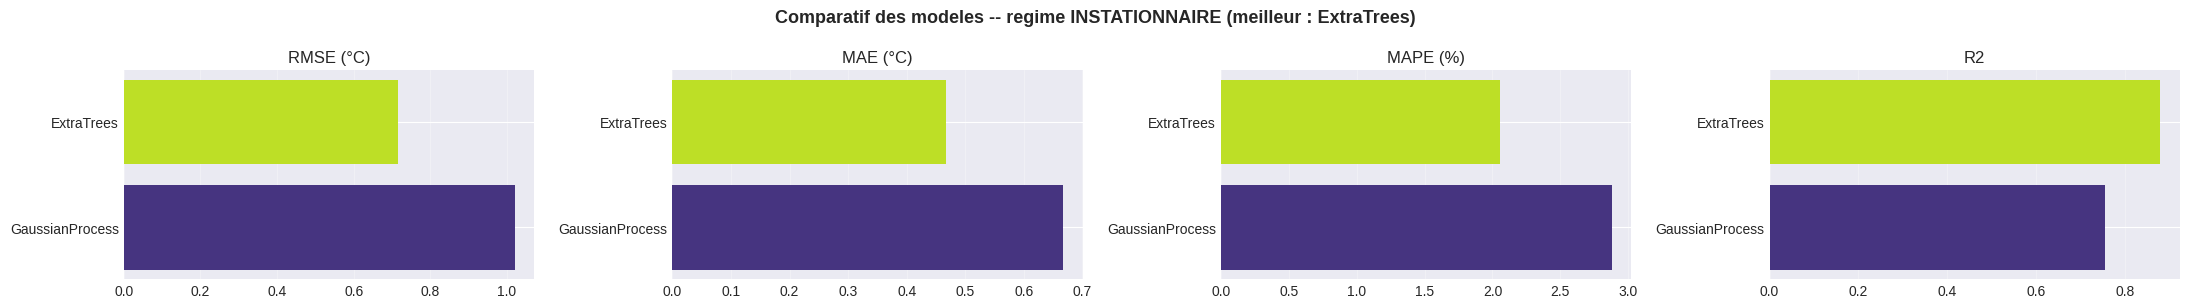

In [28]:
if len(df_inst) >= 50:
    barres_comparatif(comparaison_inst,
        f'Comparatif des modeles -- regime INSTATIONNAIRE (meilleur : {NOM_MODELE_INSTATIONNAIRE})')
else:
    print('Pas assez de donnees pour le comparatif instationnaire.')

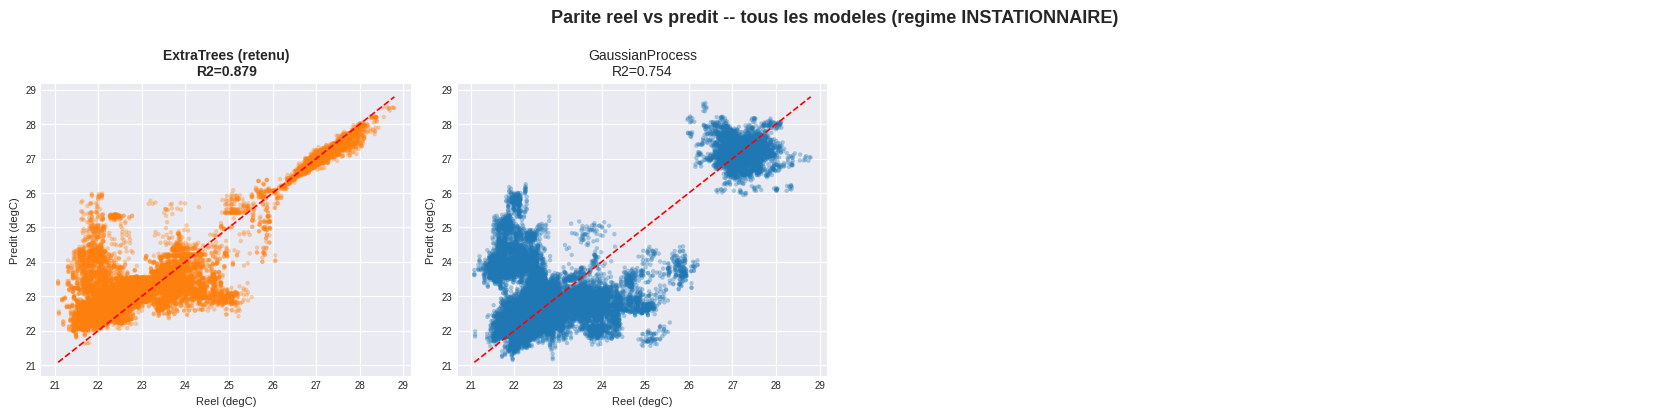

In [29]:
if len(df_inst) >= 50:
    noms_modeles_plot_i = list(predictions_inst.keys())
    n_modeles_i = len(noms_modeles_plot_i)
    n_cols_i = 4
    n_rows_i = int(np.ceil(n_modeles_i / n_cols_i))
    fig, axes = plt.subplots(n_rows_i, n_cols_i, figsize=(4.2 * n_cols_i, 4.2 * n_rows_i), squeeze=False)

    for i, nom in enumerate(noms_modeles_plot_i):
        ax = axes[i // n_cols_i][i % n_cols_i]
        pred_m = predictions_inst[nom]
        r2_m = metriques_inst_tous[nom]['r2']
        est_meilleur = (nom == NOM_MODELE_INSTATIONNAIRE)
        ax.scatter(yte_inst, pred_m, s=10, alpha=0.35,
                   color='tab:orange' if est_meilleur else 'tab:blue', edgecolor='none')
        lim_min = min(yte_inst.min(), pred_m.min()); lim_max = max(yte_inst.max(), pred_m.max())
        ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.2)
        titre_ax = f'{nom}{" (retenu)" if est_meilleur else ""}\nR2={r2_m:.3f}'
        ax.set_title(titre_ax, fontsize=10, fontweight='bold' if est_meilleur else 'normal')
        ax.set_xlabel('Reel (degC)', fontsize=8); ax.set_ylabel('Predit (degC)', fontsize=8)
        ax.tick_params(labelsize=7)

    for j in range(n_modeles_i, n_rows_i * n_cols_i):
        axes[j // n_cols_i][j % n_cols_i].axis('off')

    plt.suptitle('Parite reel vs predit -- tous les modeles (regime INSTATIONNAIRE)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Pas assez de donnees pour la grille de parite.')

## 15 — Métriques par combinaison trajectoire × chauffage × régime

In [30]:
def tableau_metriques(df_test, nom_regime):
    if df_test is None or len(df_test) == 0:
        return pd.DataFrame()
    lignes = []
    for (traj, chauff), g in df_test.groupby(['trajectory_type', 'heating_type']):
        rmse = np.sqrt(mean_squared_error(g['reel'], g['predit']))
        mae  = mean_absolute_error(g['reel'], g['predit'])
        mape = mean_absolute_percentage_error(g['reel'], g['predit']) * 100
        r2   = r2_score(g['reel'], g['predit']) if g['reel'].nunique() > 1 else np.nan
        lignes.append({'Régime': nom_regime, 'Trajectoire': traj, 'Chauffage': chauff,
                        'n': len(g), 'RMSE (°C)': rmse, 'MAE (°C)': mae, 'MAPE (%)': mape, 'R2': r2})
    return pd.DataFrame(lignes)

tab_stat = tableau_metriques(df_stat_test if 'df_stat_test' in globals() else None, 'Stationnaire')
tab_inst = tableau_metriques(df_inst_test if 'df_inst_test' in globals() else None, 'Instationnaire')
tableau_complet = pd.concat([tab_stat, tab_inst], ignore_index=True)
print('Métriques par combinaison (Cas A) :')
display(tableau_complet.round(4))

Métriques par combinaison (Cas A) :


,Régime,Trajectoire,Chauffage,n,RMSE (°C),MAE (°C),MAPE (%),R2
0,Stationnaire,Aléatoire,mesure_principale,5382,0.9914,0.7032,3.0238,-0.0625
1,Stationnaire,FPS,mesure_principale,3588,1.1287,0.7081,2.9937,-0.0796
2,Stationnaire,Périmètre,mesure_principale,7774,1.1933,0.6815,2.8284,-0.1172
3,Stationnaire,Serpentine (mesurée),convecteur_electrique,18576,2.9582,2.4370,10.4205,-0.0209
4,Stationnaire,Serpentine (mesurée),mesure_principale,14352,1.1381,0.7147,3.0062,-0.0873
5,Stationnaire,Serpentine (mesurée),plancher_chauffant_electrique,18576,2.7182,2.2643,9.6520,0.0193
6,Stationnaire,Serpentine (mesurée),plinthe_electrique,18576,2.8876,2.3746,10.1432,-0.0174
7,Stationnaire,Serpentine (mesurée),pompe_a_chaleur_air_air,18576,2.7676,2.2649,9.6467,0.0042
8,Stationnaire,Serpentine (mesurée),radiateur_eau_chaude,18576,2.8566,2.3502,10.0322,-0.0144
9,Stationnaire,Serpentine (mesurée),ventiloconvecteur,18576,2.7538,2.2552,9.6023,0.0089


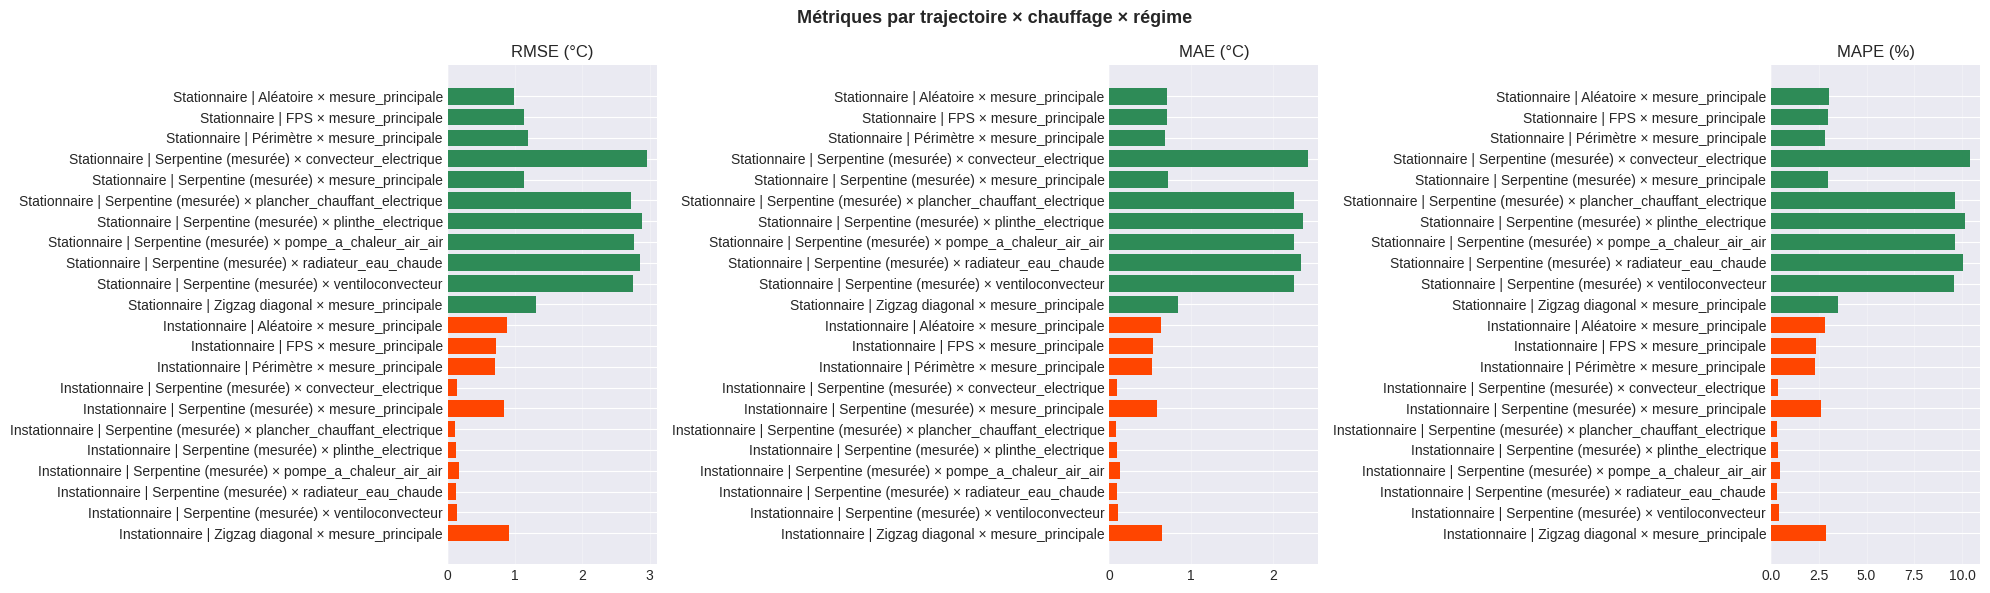

In [31]:
if len(tableau_complet) > 0:
    tableau_complet['groupe'] = (tableau_complet['Régime'] + ' | ' +
                                  tableau_complet['Trajectoire'] + ' × ' + tableau_complet['Chauffage'])
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    couleurs = tableau_complet['Régime'].map({'Stationnaire': 'seagreen', 'Instationnaire': 'orangered'})
    for ax, m in zip(axes, ['RMSE (°C)', 'MAE (°C)', 'MAPE (%)']):
        ax.barh(tableau_complet['groupe'], tableau_complet[m], color=couleurs)
        ax.set_title(m); ax.invert_yaxis(); ax.grid(True, alpha=0.3, axis='x')
    plt.suptitle('Métriques par trajectoire × chauffage × régime', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('Aucune métrique à afficher (pas assez de données dans un des deux régimes).')

## 16 — Cartes thermiques (2D + 3D) par trajectoire × chauffage × régime

Pour chaque combinaison **trajectoire × chauffage**, et pour chacun des deux régimes, on affiche **trois visualisations distinctes** (jamais mélangées) :

1. **Carte 2D** (vue de dessus, une ligne par altitude — 0.5 m / 1.0 m / 1.5 m) : interpolation `griddata` du champ réel vs prédit.
2. **Carte 3D** : nuage de points réel vs prédit dans le volume (x, y, altitude) — **sans trajectoire dedans**.
3. **Trajectoire** (uniquement en régime instationnaire, où l'ordre chronologique a un sens) : visualisation **séparée**, affichée juste à côté des cartes de température, jamais superposée au nuage 3D.

- **Stationnaire** : les points sont les positions tenues à l'écart de l'entraînement (pas d'ordre naturel entre elles → pas de trajectoire affichée).
- **Instationnaire** : les points sont triés chronologiquement → la trajectoire est tracée à part.


In [32]:
from mpl_toolkits.mplot3d import Axes3D  # noqa (nécessaire pour projection='3d')
from scipy.interpolate import griddata as _griddata_2d


def _grille_fine(largeur, longueur, pas=60):
    gx = np.linspace(0, largeur - 1, pas)
    gy = np.linspace(0, longueur - 1, pas)
    return np.meshgrid(gx, gy)


def plot_carte_2d(df_pts, titre, cmap='RdYlBu_r'):
    """Carte 2D (vue de dessus), une ligne par altitude réelle (0.5 / 1.0 / 1.5 m),
    réel à gauche, prédit à droite. Interpolation `griddata` sur (x, y)."""
    if len(df_pts) == 0:
        print(f'{titre} [carte 2D] : aucun point à afficher.')
        return

    niveaux = sorted(df_pts['z'].unique())
    vmin = min(df_pts['reel'].min(), df_pts['predit'].min())
    vmax = max(df_pts['reel'].max(), df_pts['predit'].max())
    col_labels = [chr(ord('A') + i) for i in range(LARGEUR)]
    GX, GY = _grille_fine(LARGEUR, LONGUEUR)

    fig, axes = plt.subplots(len(niveaux), 2, figsize=(11, 4.3 * len(niveaux)), squeeze=False)
    for row, z in enumerate(niveaux):
        d = df_pts[df_pts['z'] == z]
        alt = ALTITUDES_Z[int(z)]
        for col, (champ, nom) in enumerate(zip(['reel', 'predit'], ['Réel', 'Prédit'])):
            ax = axes[row][col]
            if len(d) >= 3:
                GZ = _griddata_2d((d['x'], d['y']), d[champ], (GX, GY), method='cubic')
                im = ax.imshow(GZ, origin='lower', extent=[0, LARGEUR - 1, 0, LONGUEUR - 1],
                                cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
                fig.colorbar(im, ax=ax, shrink=0.85, label='°C')
            ax.scatter(d['x'], d['y'], c=d[champ], cmap=cmap, vmin=vmin, vmax=vmax,
                       edgecolors='black', linewidths=0.5, s=45, zorder=5)
            ax.set_xticks(range(LARGEUR)); ax.set_xticklabels(col_labels)
            ax.set_yticks(range(LONGUEUR))
            ax.set_title(f'{nom} — z = {alt:.1f} m')
    plt.suptitle(f'{titre} — carte 2D (vue de dessus)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


def plot_carte_3d(df_pts, titre, cmap='RdYlBu_r'):
    """Nuage de points 3D (réel vs prédit) — SANS trajectoire : uniquement le champ de
    température. La trajectoire (si besoin) est affichée séparément par plot_trajectoire."""
    if len(df_pts) == 0:
        print(f'{titre} [carte 3D] : aucun point à afficher.')
        return

    vmin = min(df_pts['reel'].min(), df_pts['predit'].min())
    vmax = max(df_pts['reel'].max(), df_pts['predit'].max())
    col_labels = [chr(ord('A') + i) for i in range(LARGEUR)]

    fig = plt.figure(figsize=(14, 6))
    for i, (col, nom) in enumerate(zip(['reel', 'predit'], ['Réel', 'Prédit'])):
        ax = fig.add_subplot(1, 2, i + 1, projection='3d')
        sc = ax.scatter(df_pts['x'], df_pts['y'], df_pts['z'], c=df_pts[col], cmap=cmap,
                         s=55, edgecolors='black', linewidths=0.4, vmin=vmin, vmax=vmax, zorder=5)
        ax.set_xlabel('X (A–H)'); ax.set_xticks(range(LARGEUR)); ax.set_xticklabels(col_labels)
        ax.set_ylabel('Y (0–4)'); ax.set_yticks(range(LONGUEUR))
        ax.set_zlabel('Altitude (m)'); ax.set_zticks(range(HAUTEUR))
        ax.set_zticklabels([f'{a:.1f} m' for a in ALTITUDES_Z])
        ax.set_title(nom)
        fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, label='°C')
    plt.suptitle(f'{titre} — carte 3D', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


def plot_trajectoire(df_pts, titre):
    """Visualisation SÉPARÉE de la trajectoire du robot (ordre chronologique) —
    affichée à côté des cartes de température, jamais mêlée au nuage 3D du champ.
    Panneau gauche : vue de dessus (x, y) avec le chemin parcouru.
    Panneau droit : altitude parcourue le long de la séquence."""
    if len(df_pts) == 0:
        return
    d = df_pts.reset_index(drop=True)
    ordre = np.arange(len(d))
    alt = np.array(ALTITUDES_Z)[d['z'].values.astype(int)]
    col_labels = [chr(ord('A') + i) for i in range(LARGEUR)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sc = axes[0].scatter(d['x'], d['y'], c=ordre, cmap='viridis', s=40, zorder=3)
    axes[0].plot(d['x'], d['y'], color='gray', lw=0.8, alpha=0.6, zorder=1)
    axes[0].set_xticks(range(LARGEUR)); axes[0].set_xticklabels(col_labels)
    axes[0].set_yticks(range(LONGUEUR))
    axes[0].set_xlabel('X (A–H)'); axes[0].set_ylabel('Y (0–4)')
    axes[0].set_title('Trajectoire — vue de dessus')
    fig.colorbar(sc, ax=axes[0], label='ordre de passage')

    axes[1].plot(ordre, alt, marker='o', ms=3, color='steelblue')
    axes[1].set_yticks(ALTITUDES_Z)
    axes[1].set_xlabel('ordre de passage'); axes[1].set_ylabel('Altitude (m)')
    axes[1].set_title('Altitude parcourue')

    plt.suptitle(f'{titre} — trajectoire (visualisation à part, hors du champ 3D)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


def plot_champ_3d(df_pts, titre, avec_trajectoire=False, cmap='RdYlBu_r'):
    """Orchestrateur : carte 2D puis carte 3D du champ de température (jamais de
    trajectoire mêlée dedans) ; si avec_trajectoire=True, la trajectoire est
    affichée ensuite, à côté, dans sa propre visualisation."""
    plot_carte_2d(df_pts, titre, cmap=cmap)
    plot_carte_3d(df_pts, titre, cmap=cmap)
    if avec_trajectoire:
        plot_trajectoire(df_pts, titre)


def sous_ensemble_stationnaire(traj):
    """Positions tenues à l'écart de l'entraînement pour cette trajectoire — moyenne par
    position (x,y,z), une valeur par heating_type disponible."""
    if 'df_stat_test' not in globals() or df_stat_test is None:
        return {}
    d = df_stat_test[df_stat_test['trajectory_type'] == traj]
    out = {}
    for chauff, g in d.groupby('heating_type'):
        out[chauff] = g.groupby(['x', 'y', 'z'])[['reel', 'predit']].mean().reset_index()
    return out


def sous_ensemble_instationnaire(traj):
    """Points test triés chronologiquement pour cette trajectoire (trace la trajectoire),
    une séquence par heating_type disponible."""
    if 'df_inst_test' not in globals() or df_inst_test is None:
        return {}
    d = df_inst_test[df_inst_test['trajectory_type'] == traj]
    out = {}
    for chauff, g in d.groupby('heating_type'):
        # df_inst_test ne contient pas t_sec -> on retrouve l'ordre via l'index d'origine
        out[chauff] = g.loc[g.index]  # déjà dans l'ordre chronologique (issu du split trié)
    return out

TRAJECTOIRES_CONNUES = [TRAJECTORY_TYPE_MESUREE, 'Périmètre', 'Zigzag diagonal', 'Aléatoire', 'FPS']
print('Fonctions de visualisation (2D + 3D + trajectoire séparée) prêtes.')


Fonctions de visualisation (2D + 3D + trajectoire séparée) prêtes.


#### Stationnaire — trajectoire : Serpentine (mesurée)

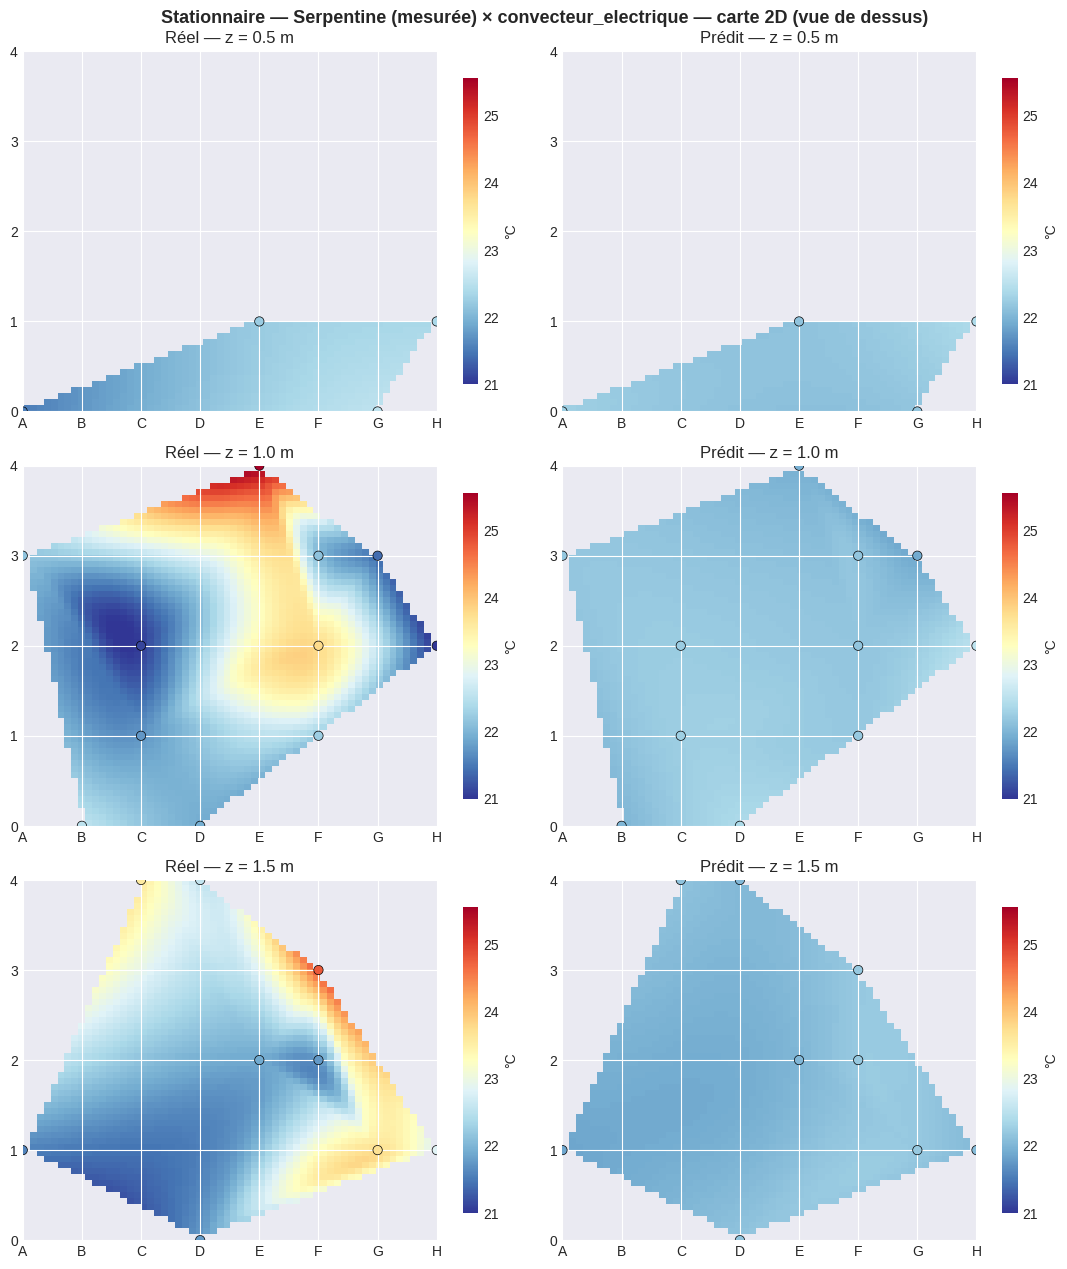

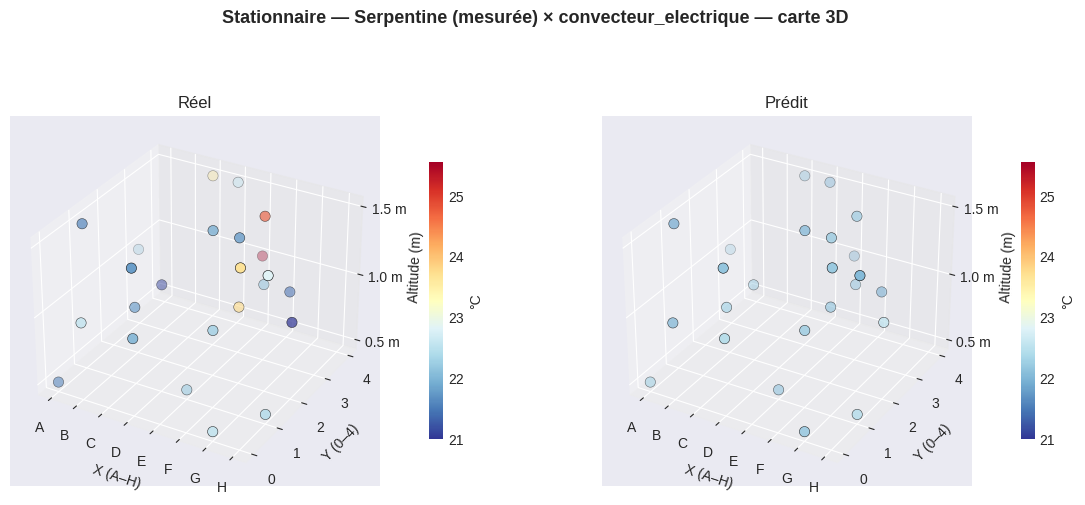

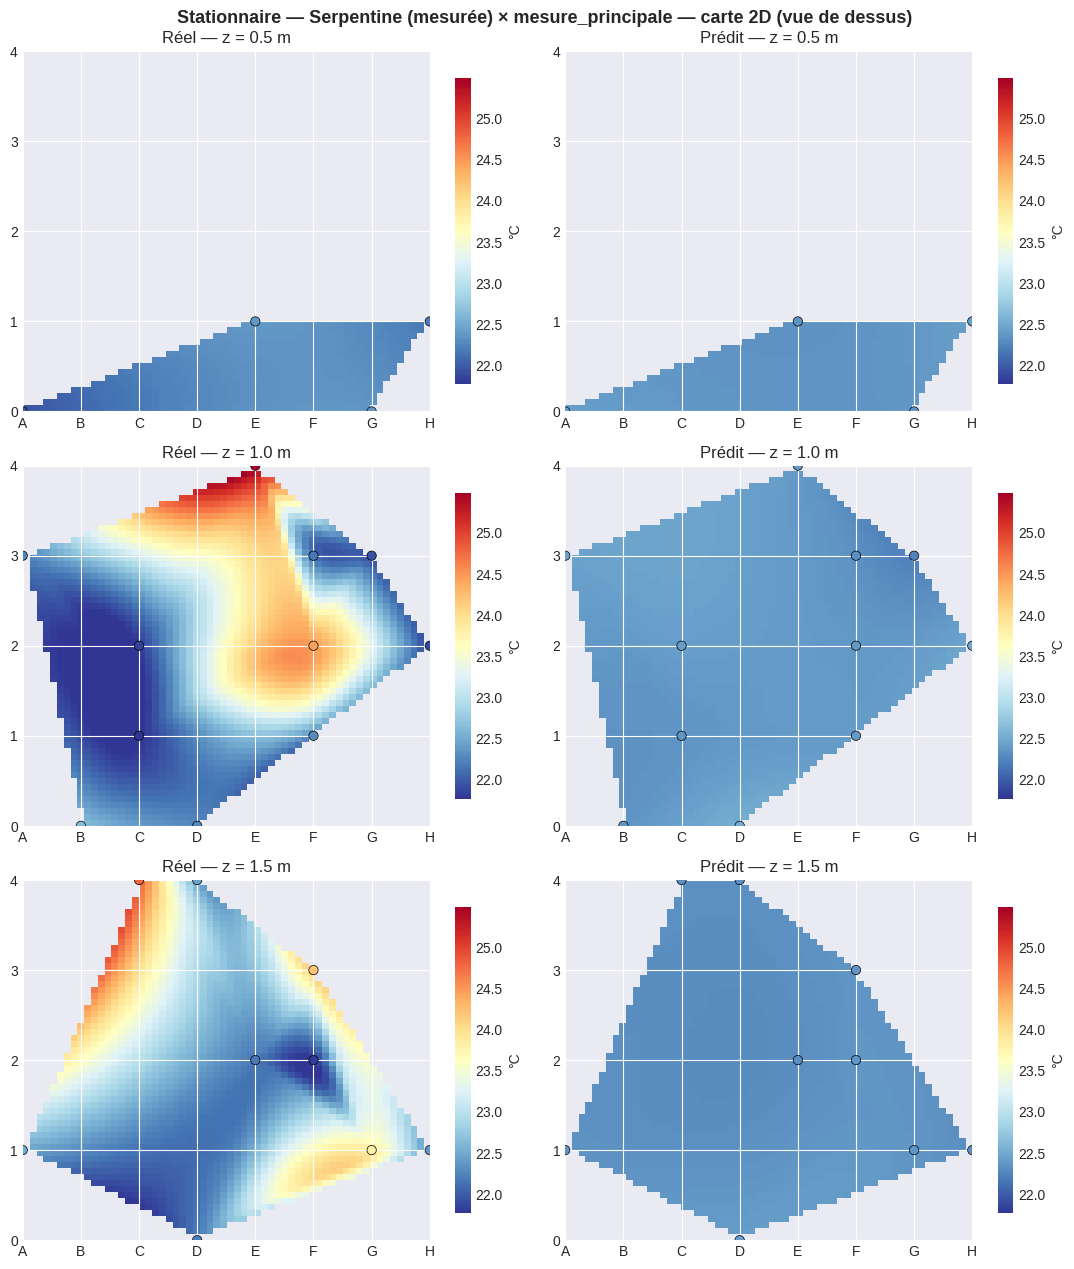

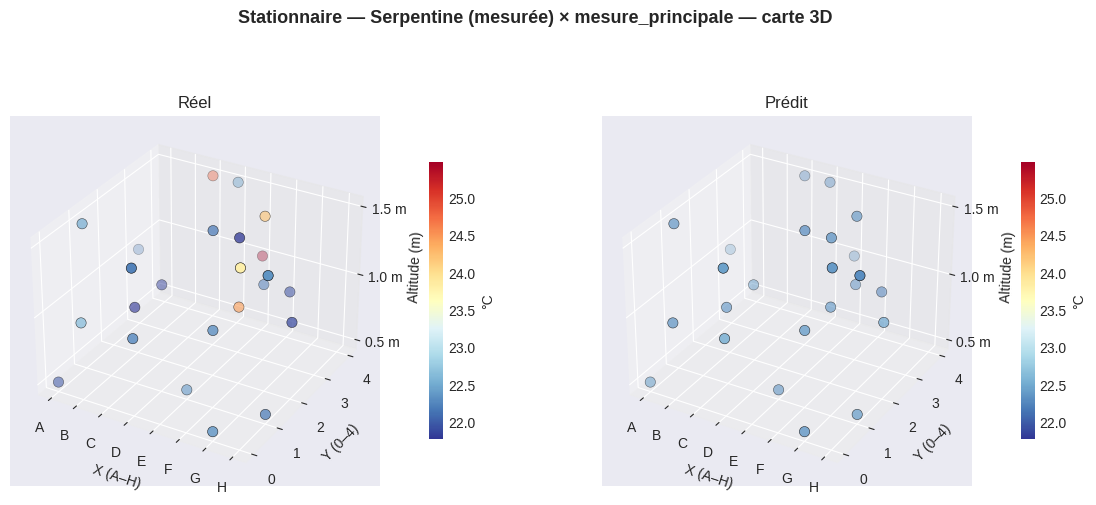

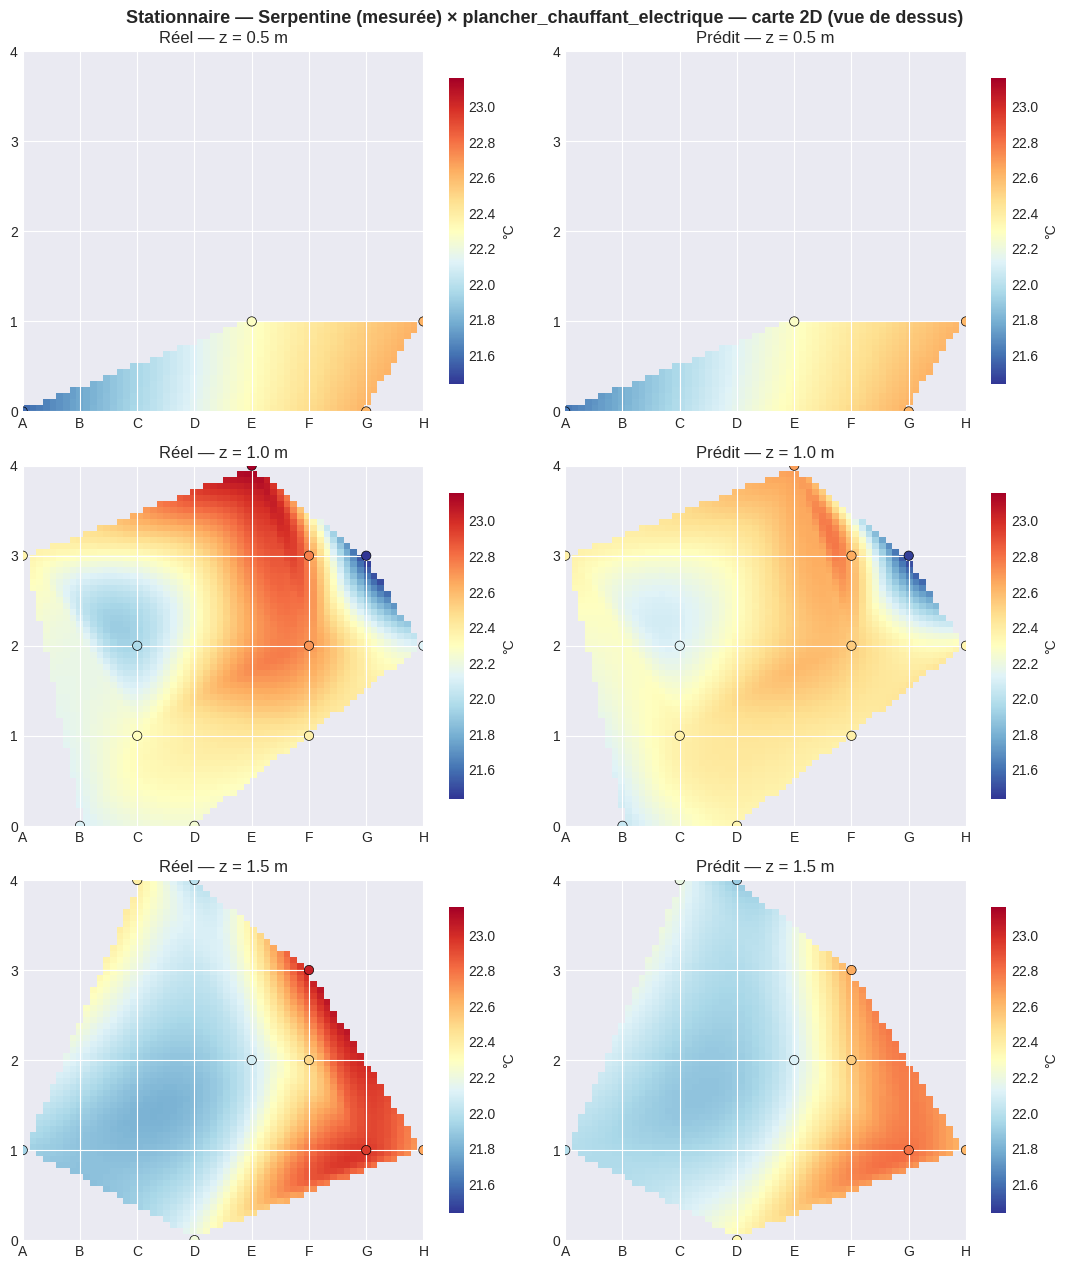

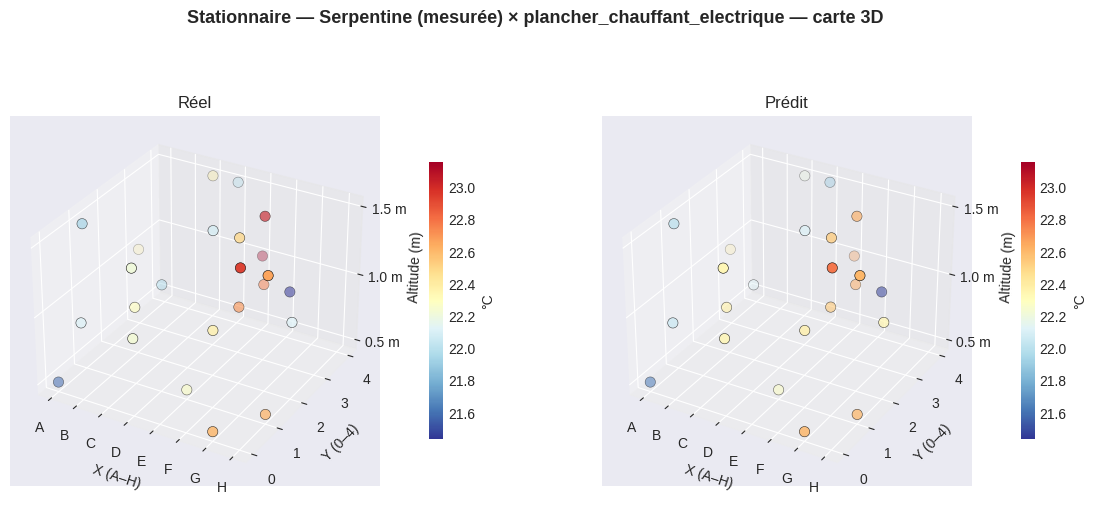

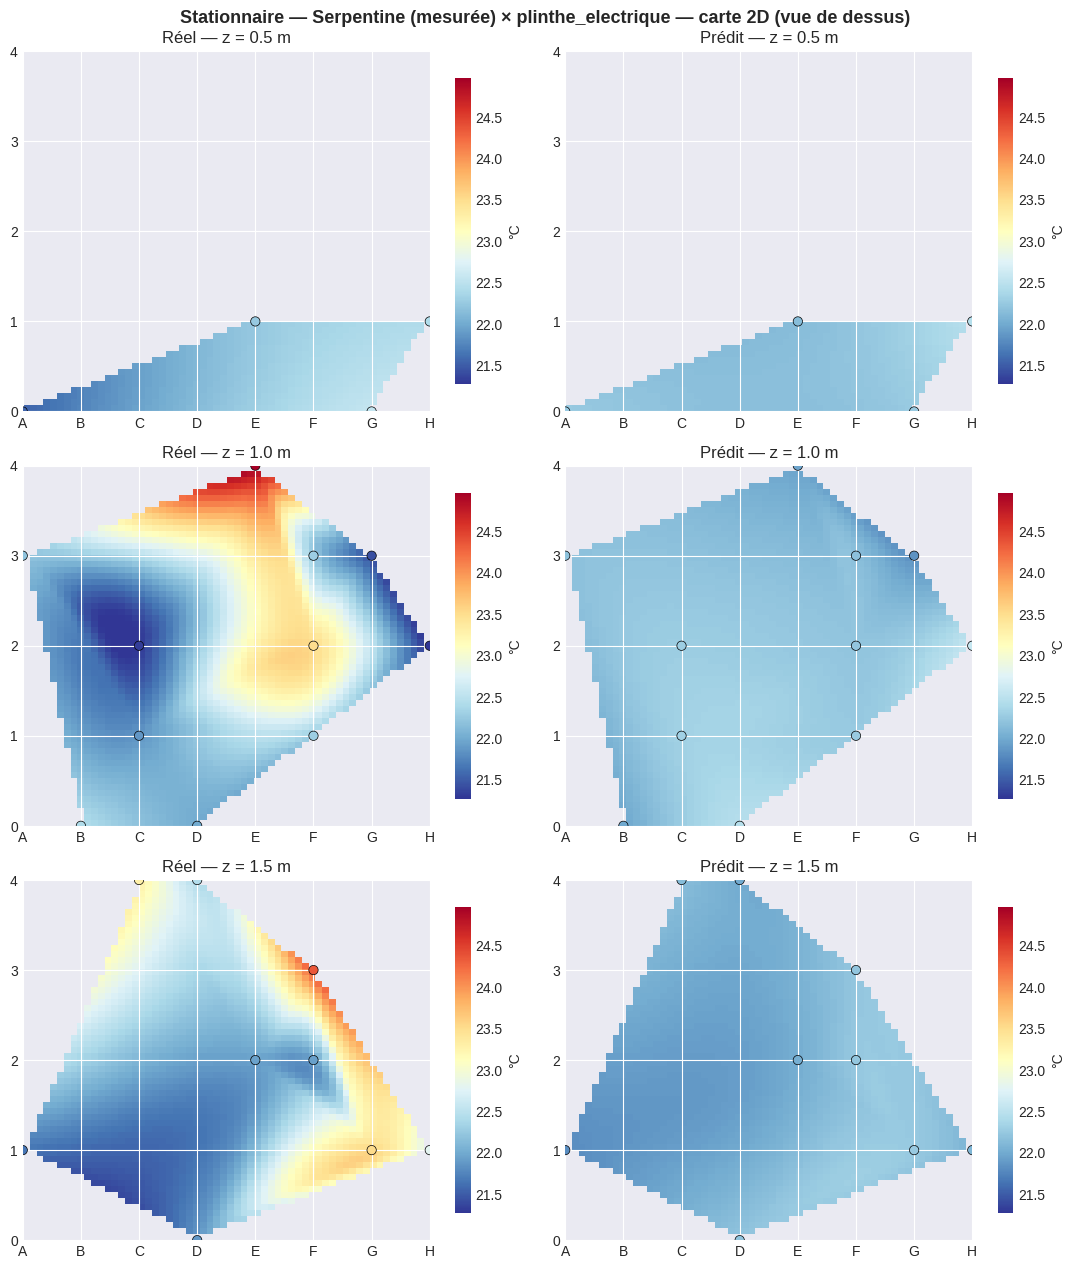

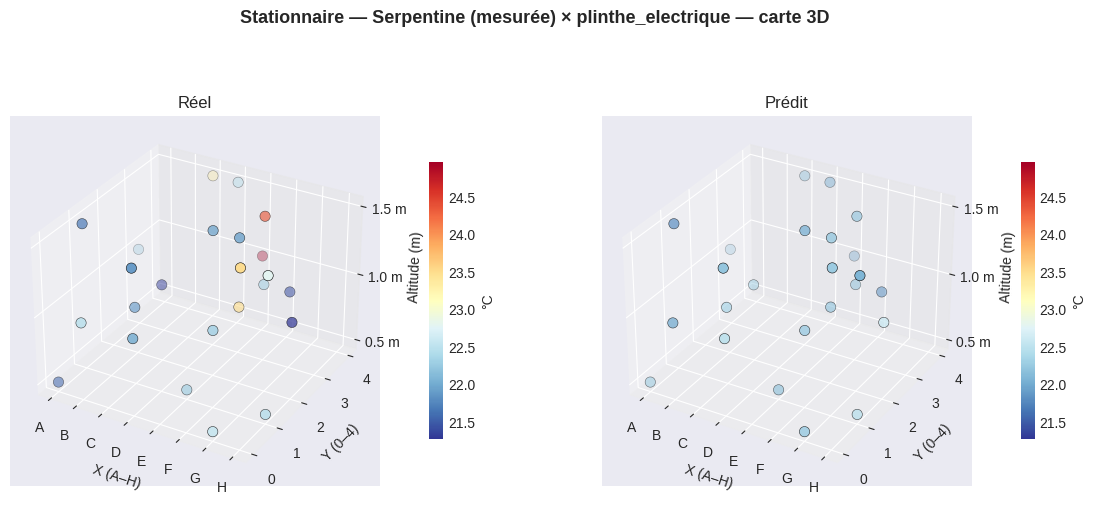

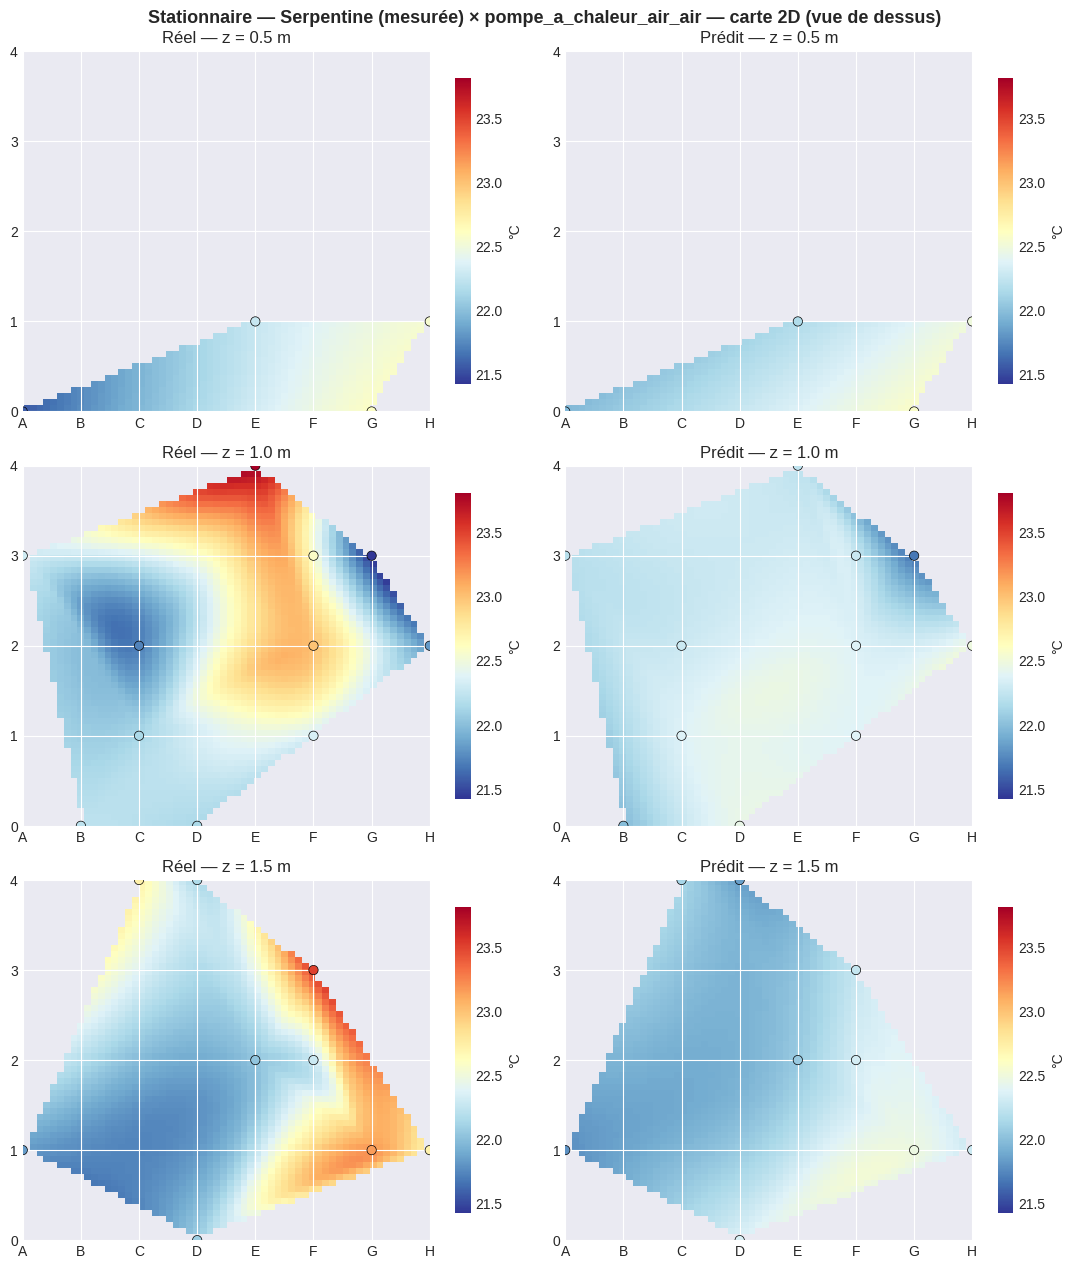

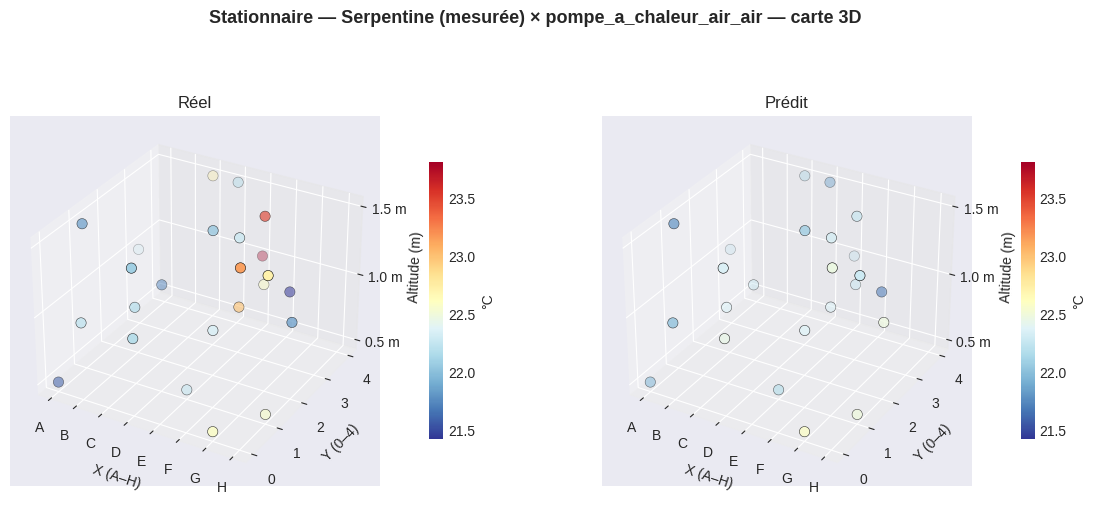

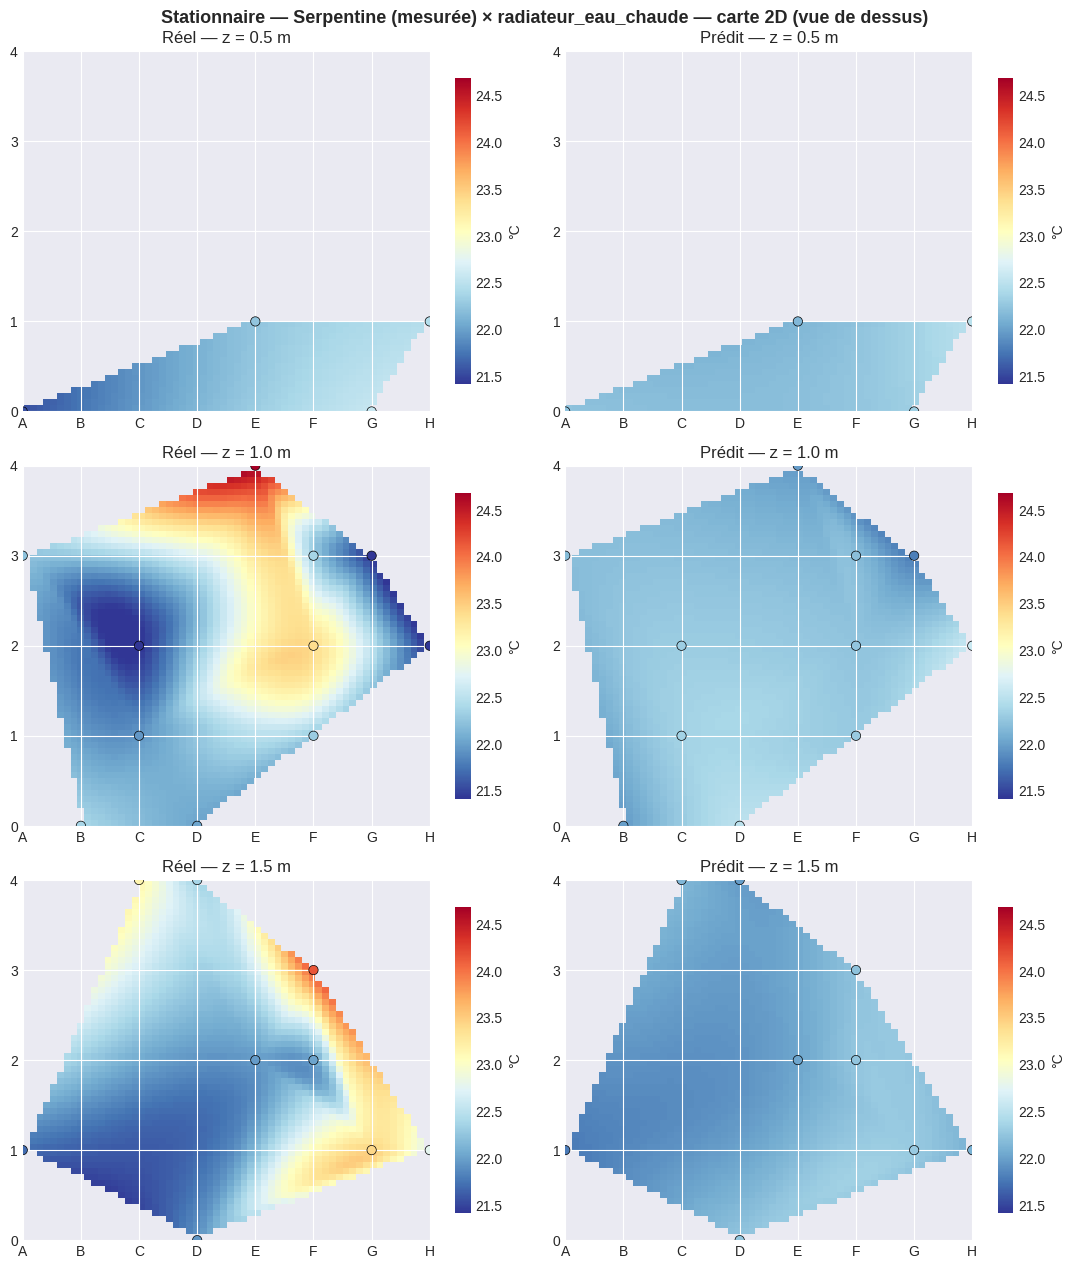

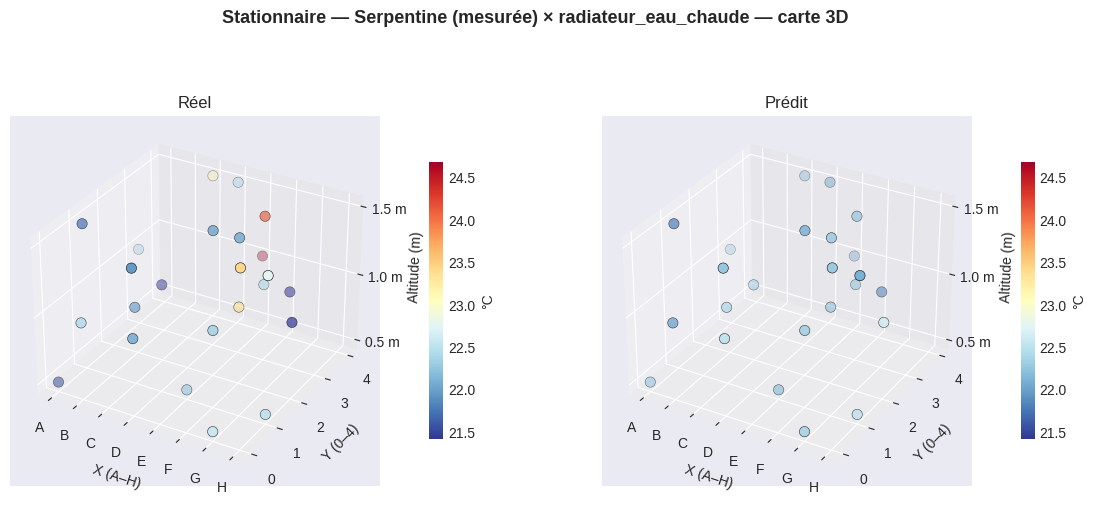

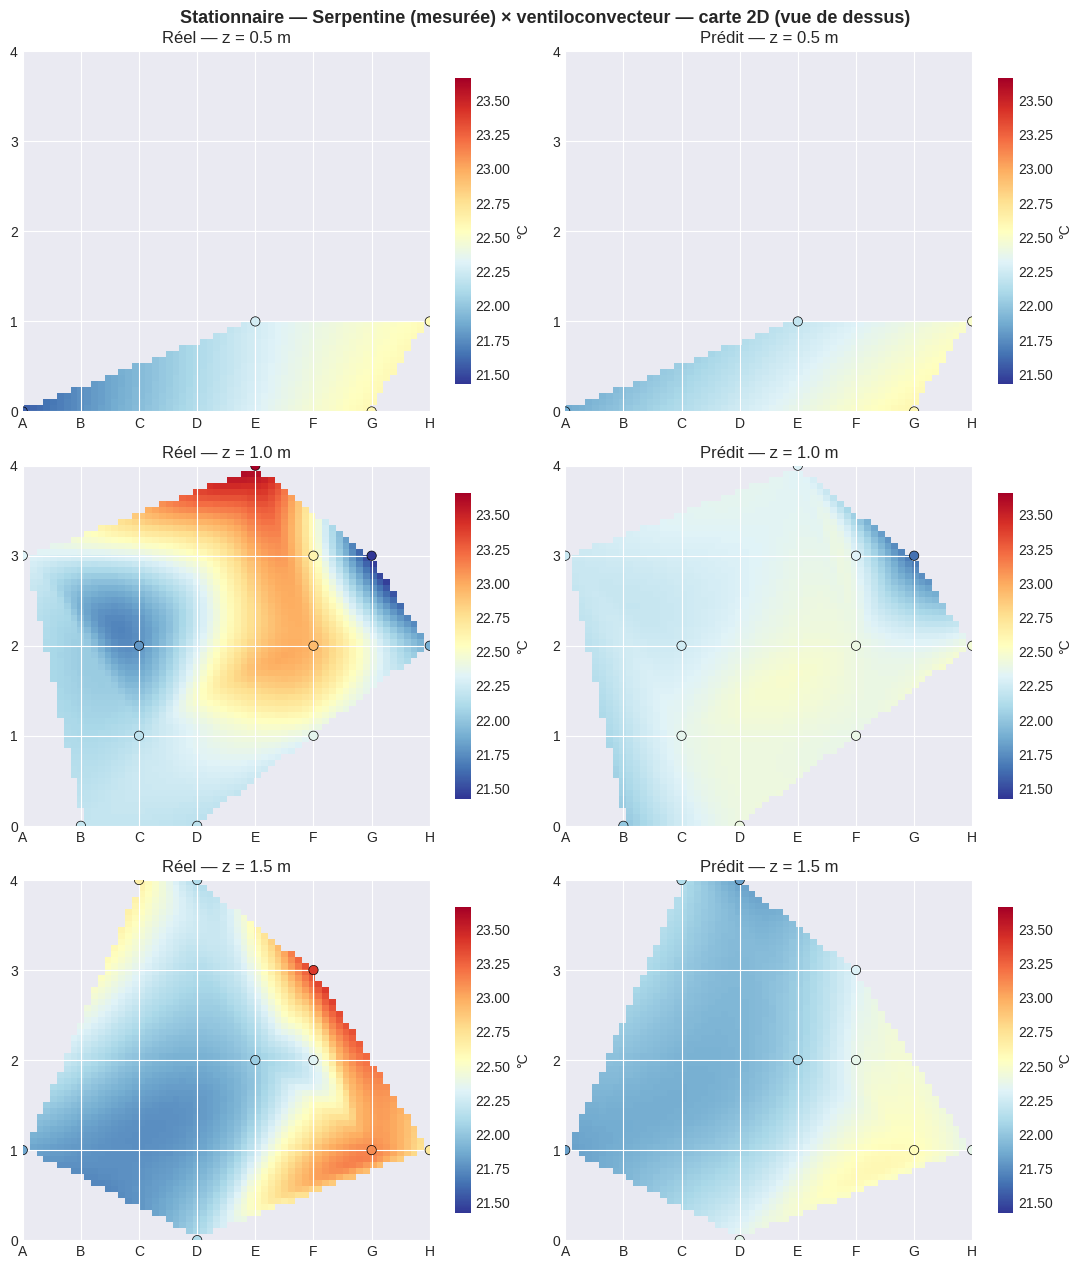

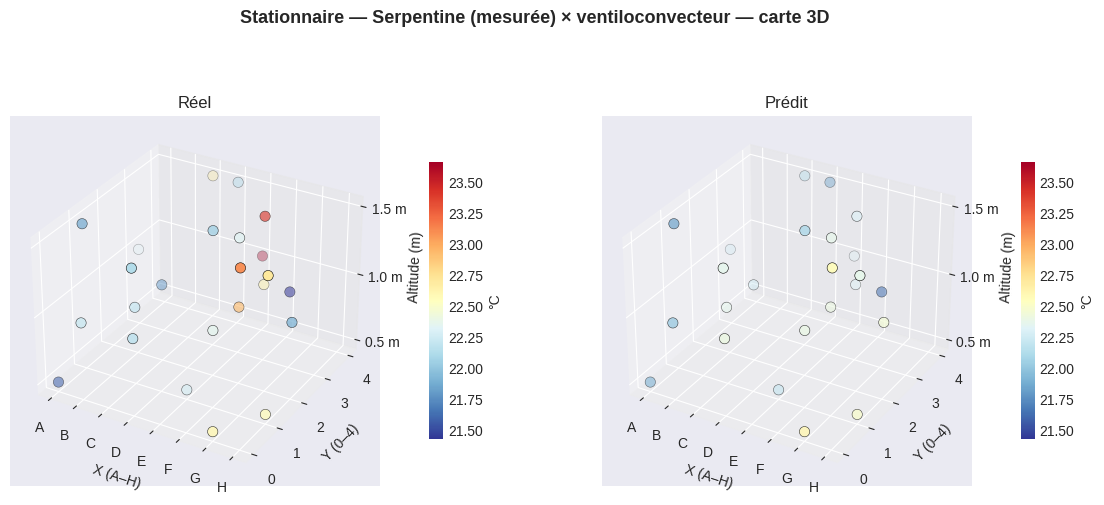

In [33]:
sous_ensembles = sous_ensemble_stationnaire(TRAJECTORY_TYPE_MESUREE)
if len(sous_ensembles) == 0:
    print('Stationnaire — Serpentine (mesurée) : aucune donnée test pour cette combinaison.')
else:
    for chauff, pts in sous_ensembles.items():
        plot_champ_3d(pts, f'Stationnaire — Serpentine (mesurée) × {chauff}', avec_trajectoire=False)

#### Stationnaire — trajectoire : Périmètre

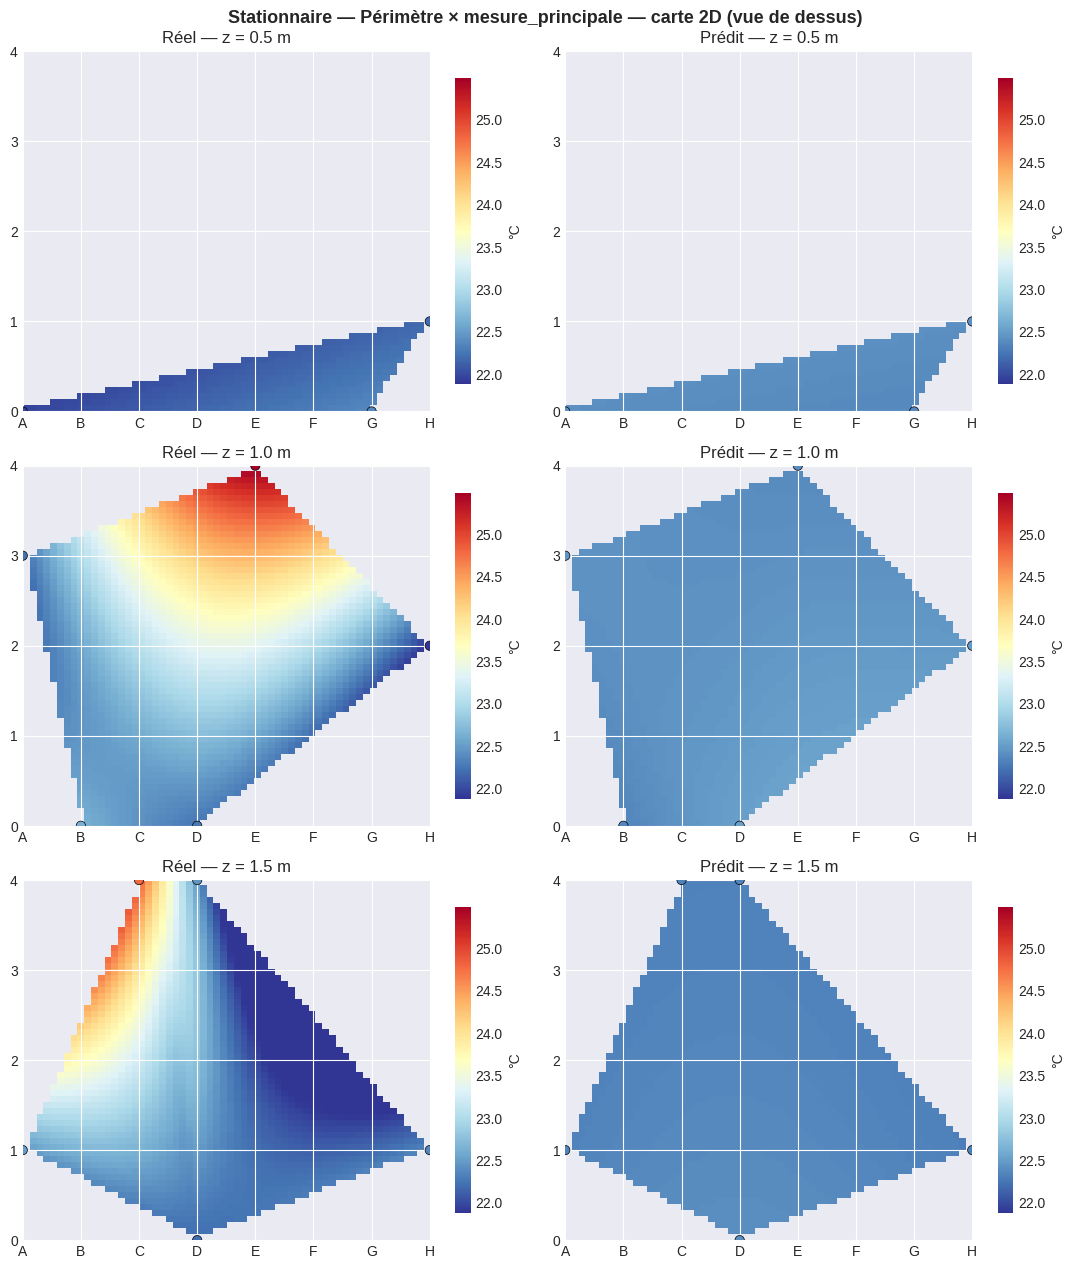

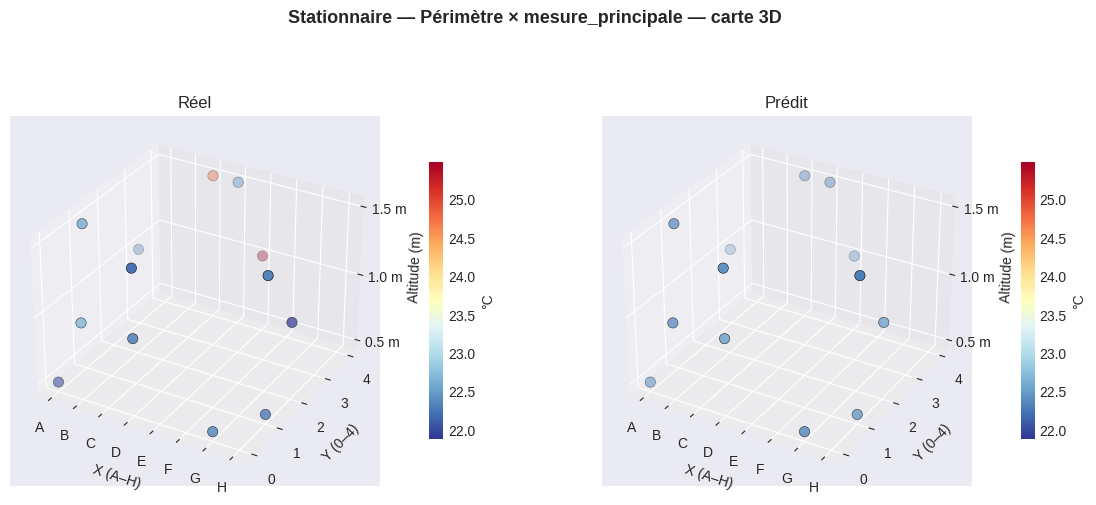

In [34]:
sous_ensembles = sous_ensemble_stationnaire('Périmètre')
if len(sous_ensembles) == 0:
    print('Stationnaire — Périmètre : aucune donnée test pour cette combinaison.')
else:
    for chauff, pts in sous_ensembles.items():
        plot_champ_3d(pts, f'Stationnaire — Périmètre × {chauff}', avec_trajectoire=False)

#### Stationnaire — trajectoire : Zigzag diagonal

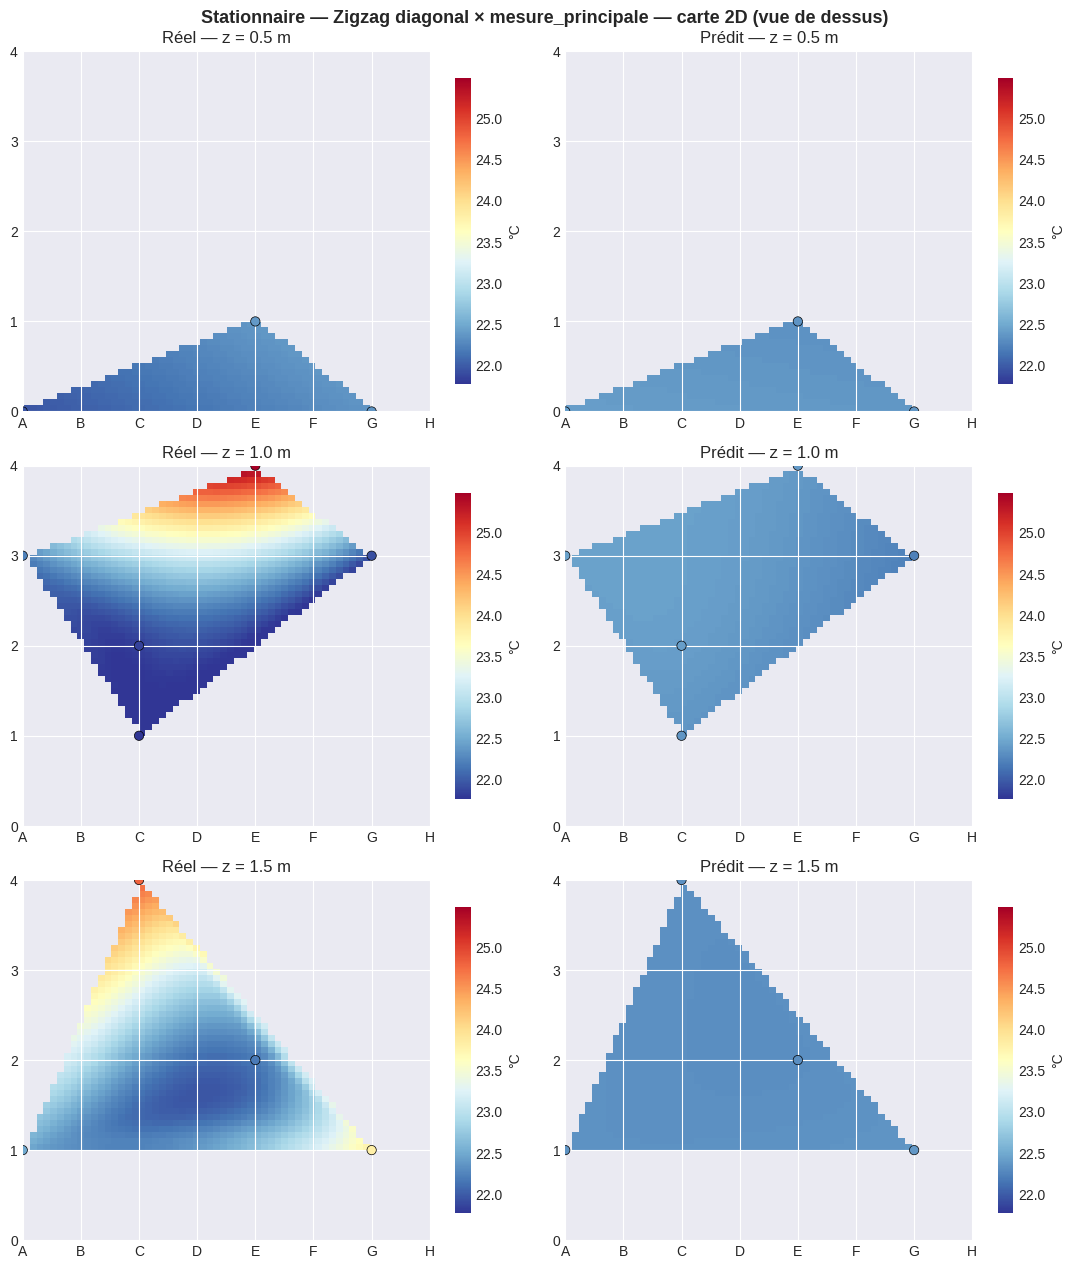

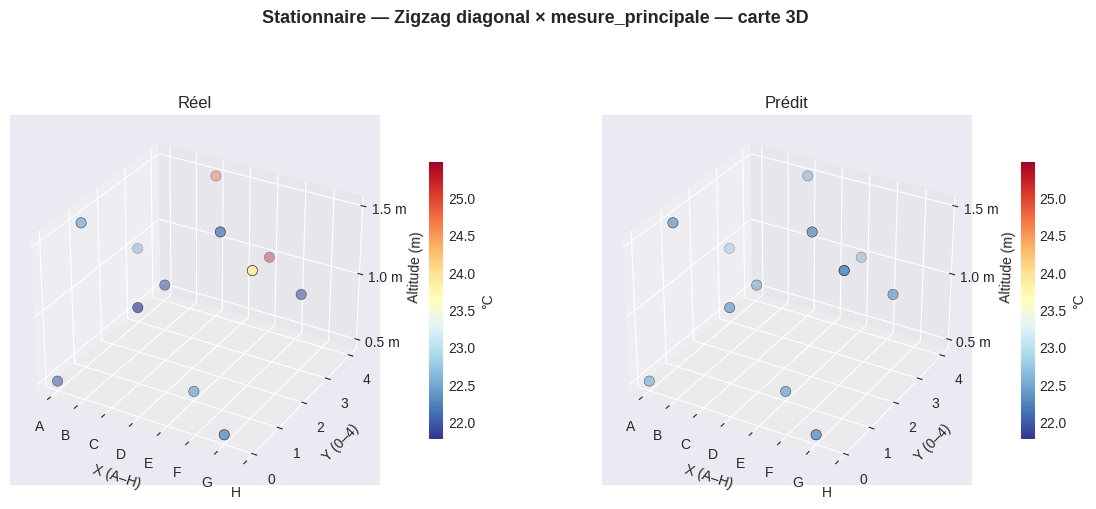

In [35]:
sous_ensembles = sous_ensemble_stationnaire('Zigzag diagonal')
if len(sous_ensembles) == 0:
    print('Stationnaire — Zigzag diagonal : aucune donnée test pour cette combinaison.')
else:
    for chauff, pts in sous_ensembles.items():
        plot_champ_3d(pts, f'Stationnaire — Zigzag diagonal × {chauff}', avec_trajectoire=False)

#### Stationnaire — trajectoire : Aléatoire

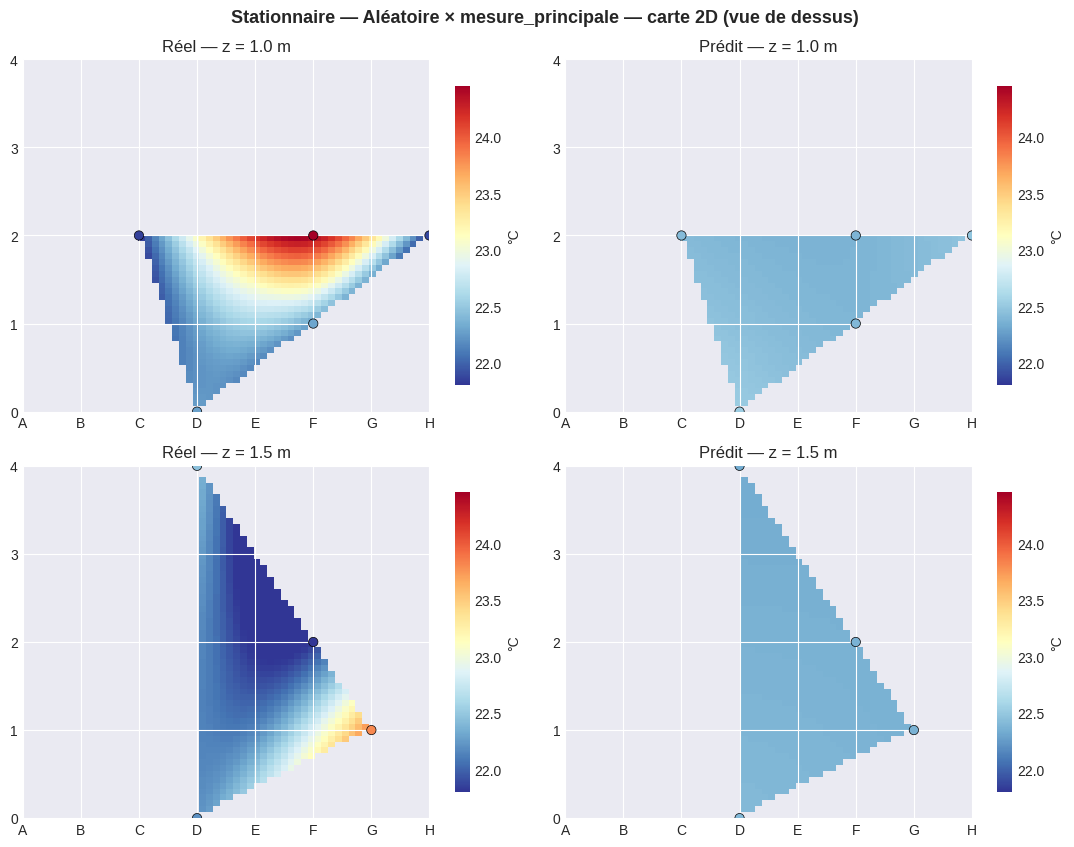

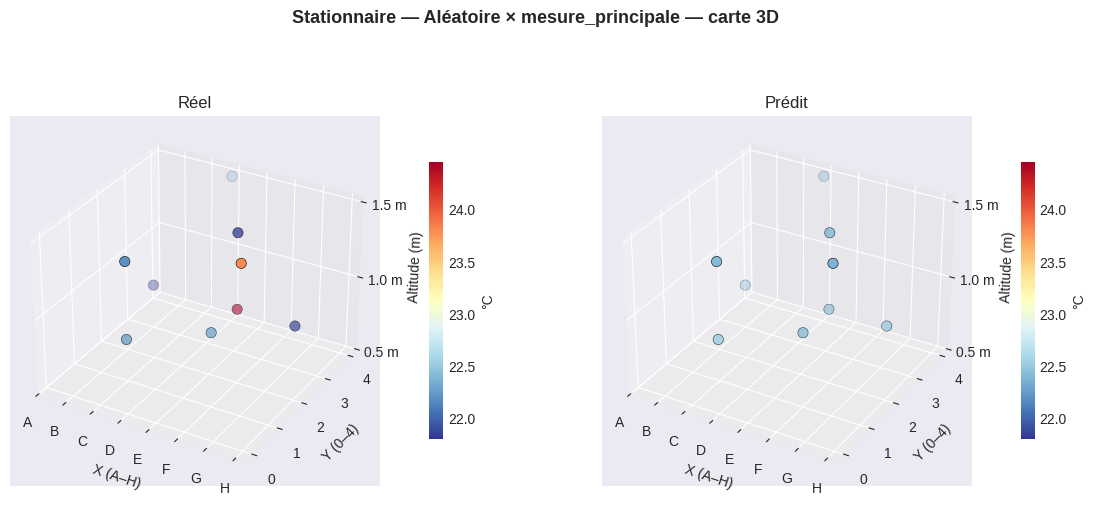

In [36]:
sous_ensembles = sous_ensemble_stationnaire('Aléatoire')
if len(sous_ensembles) == 0:
    print('Stationnaire — Aléatoire : aucune donnée test pour cette combinaison.')
else:
    for chauff, pts in sous_ensembles.items():
        plot_champ_3d(pts, f'Stationnaire — Aléatoire × {chauff}', avec_trajectoire=False)

#### Stationnaire — trajectoire : FPS

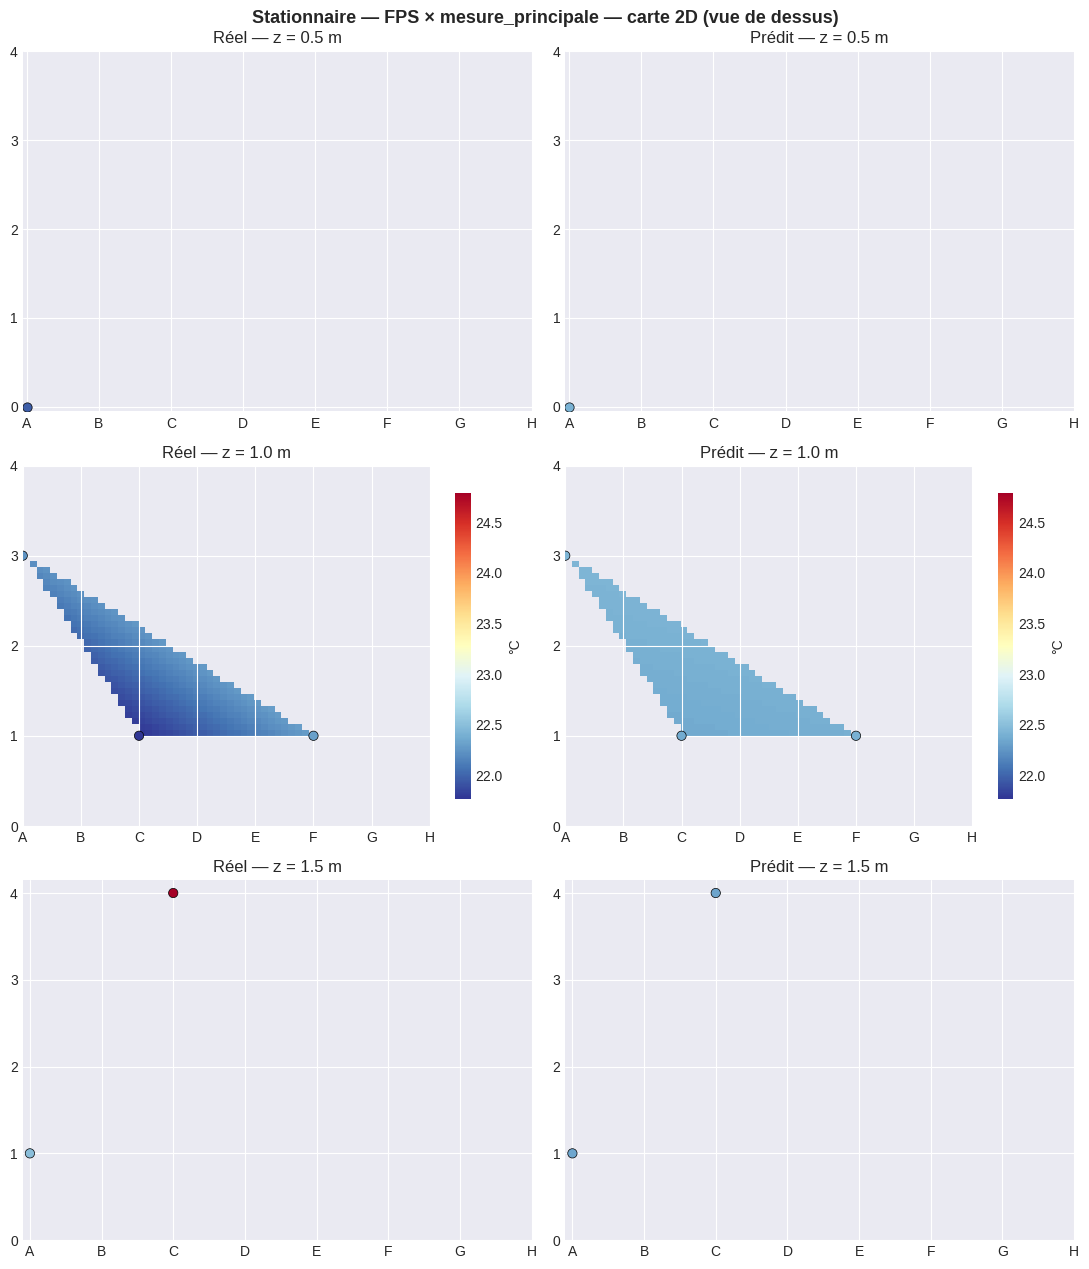

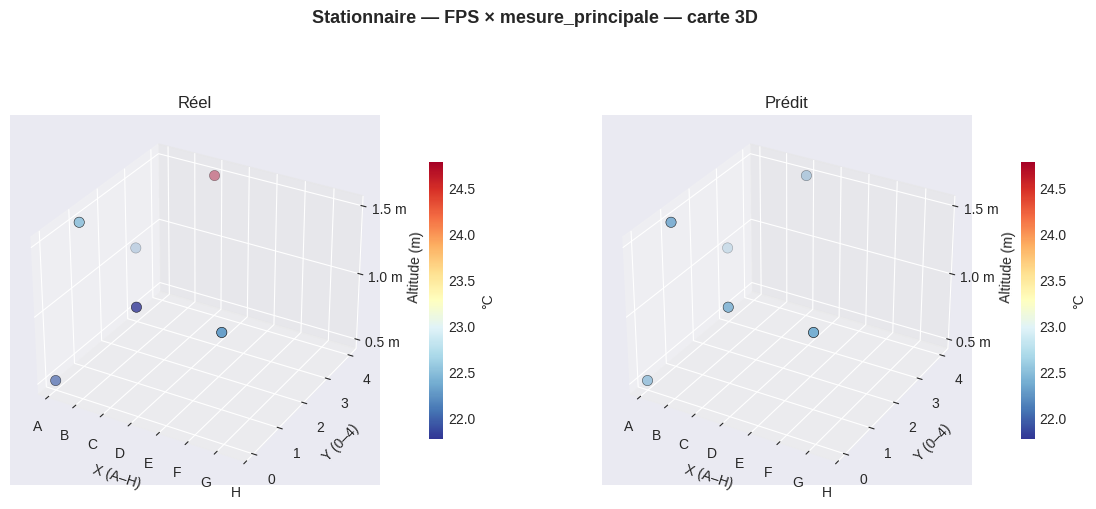

In [37]:
sous_ensembles = sous_ensemble_stationnaire('FPS')
if len(sous_ensembles) == 0:
    print('Stationnaire — FPS : aucune donnée test pour cette combinaison.')
else:
    for chauff, pts in sous_ensembles.items():
        plot_champ_3d(pts, f'Stationnaire — FPS × {chauff}', avec_trajectoire=False)

#### Instationnaire — trajectoire : Serpentine (mesurée)

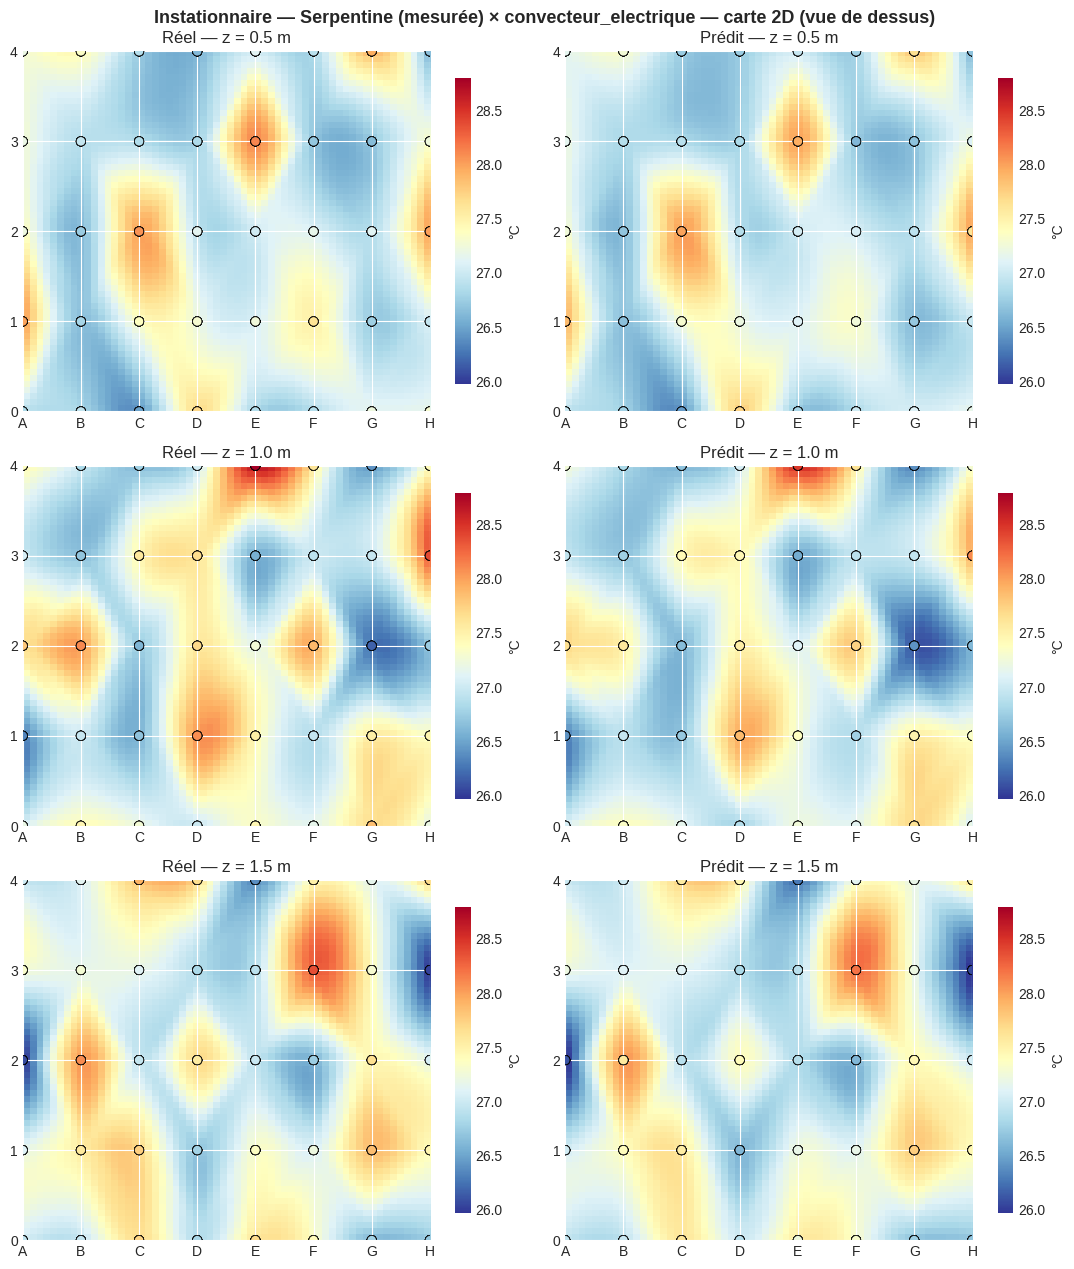

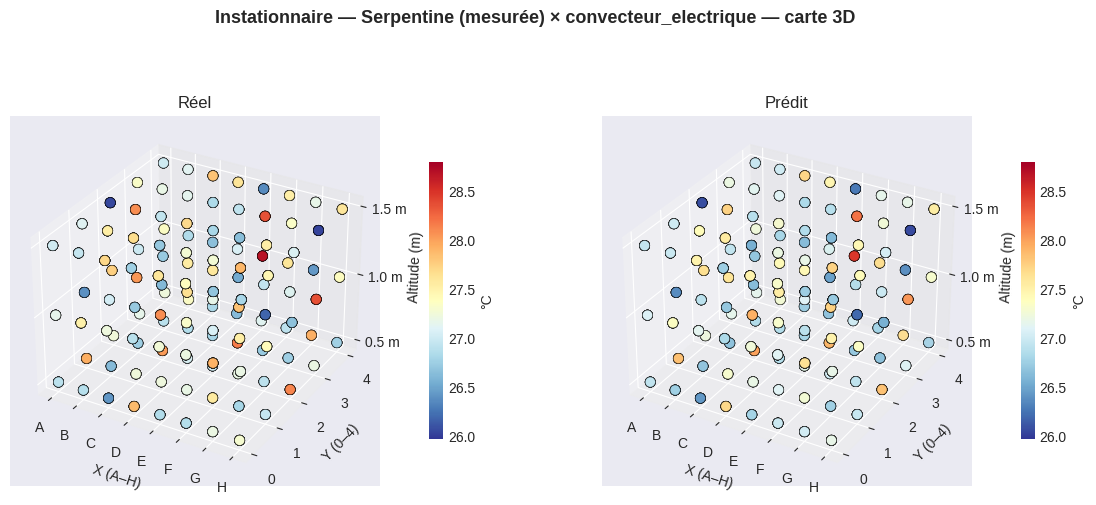

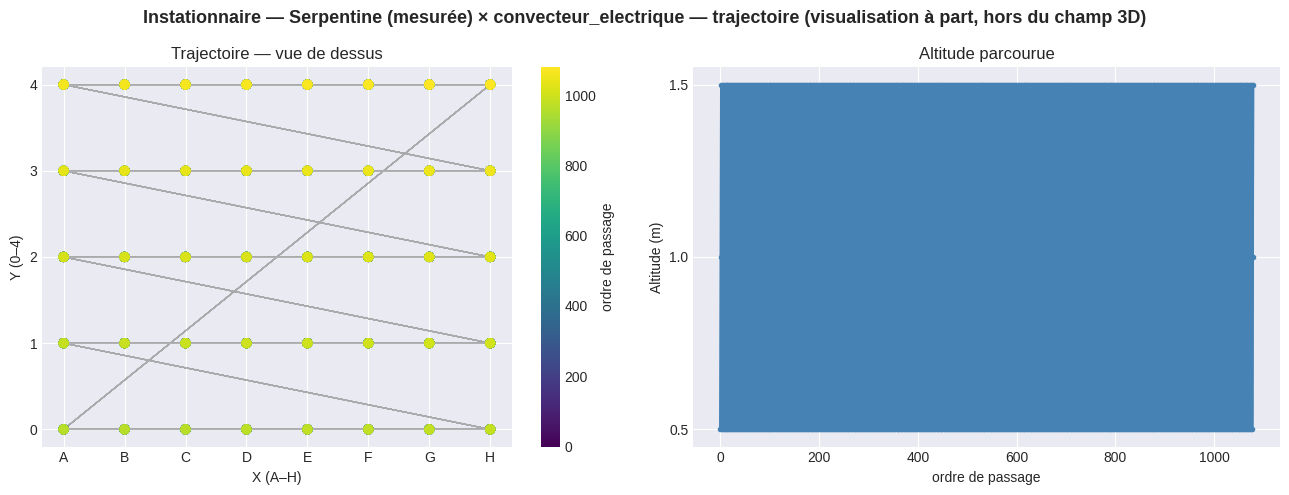

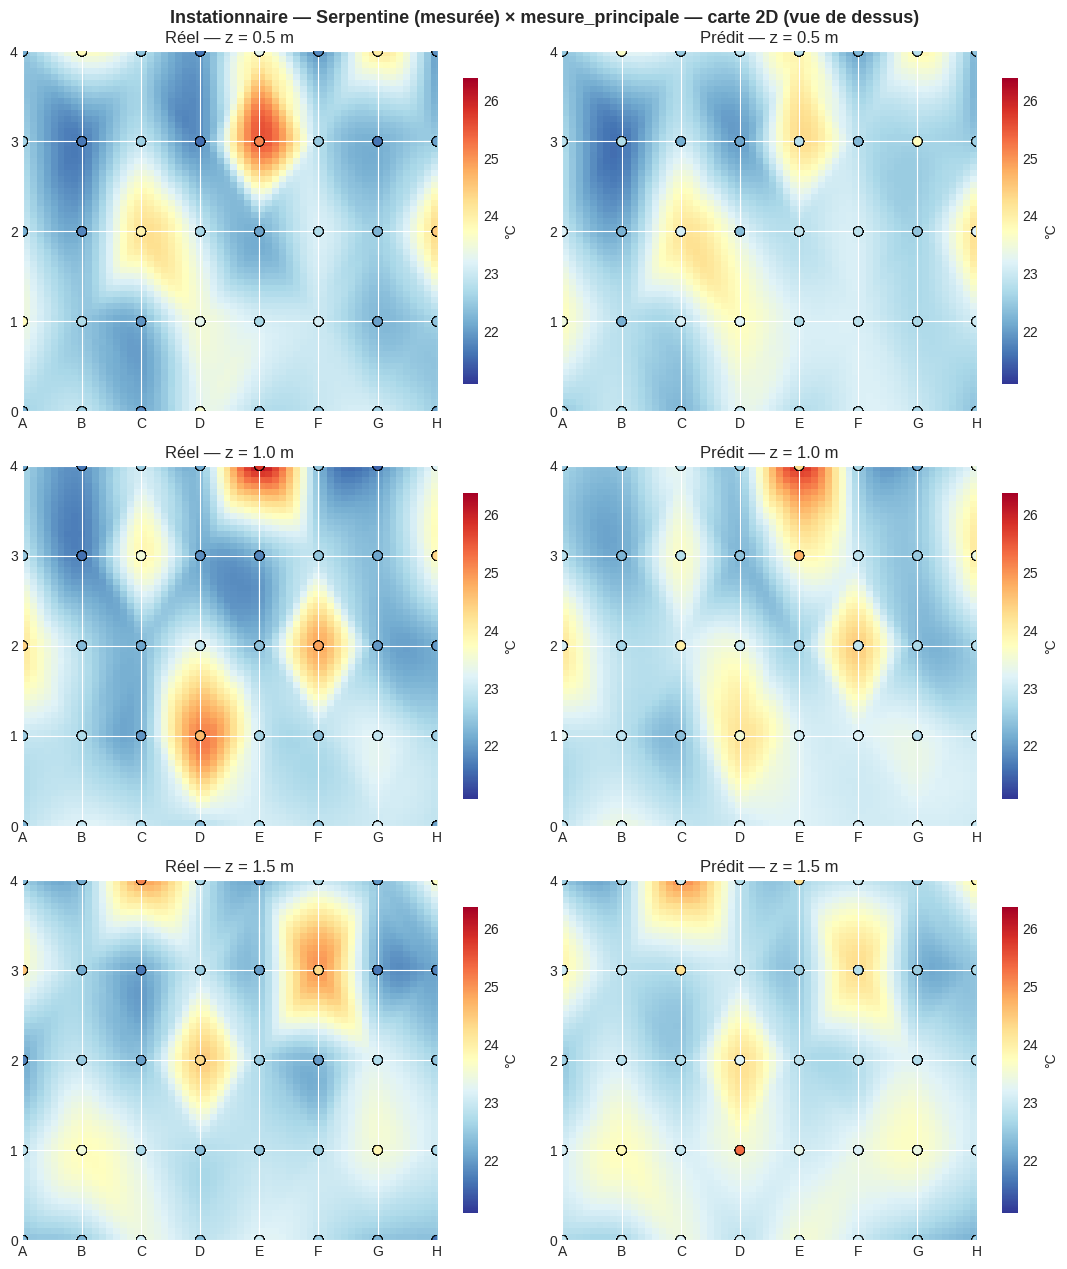

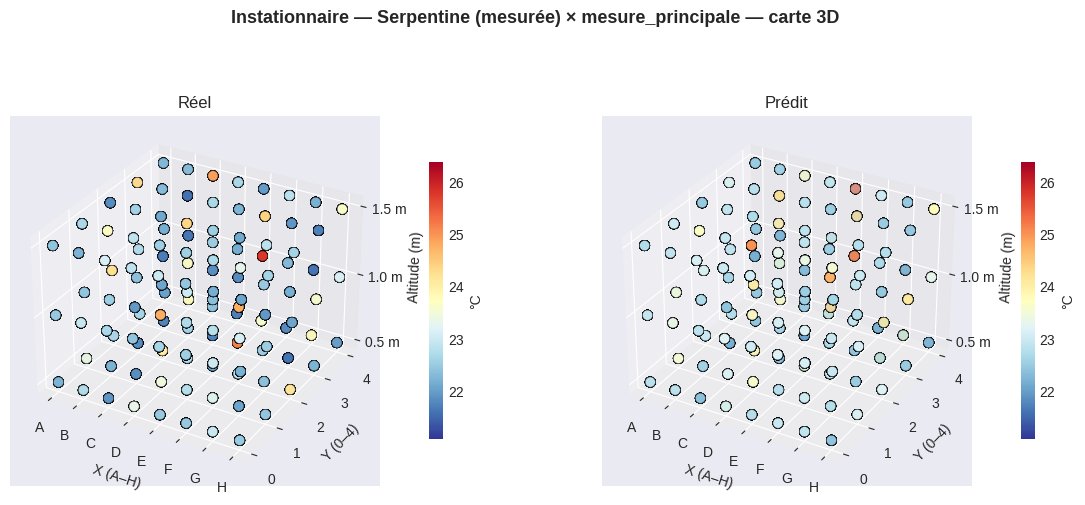

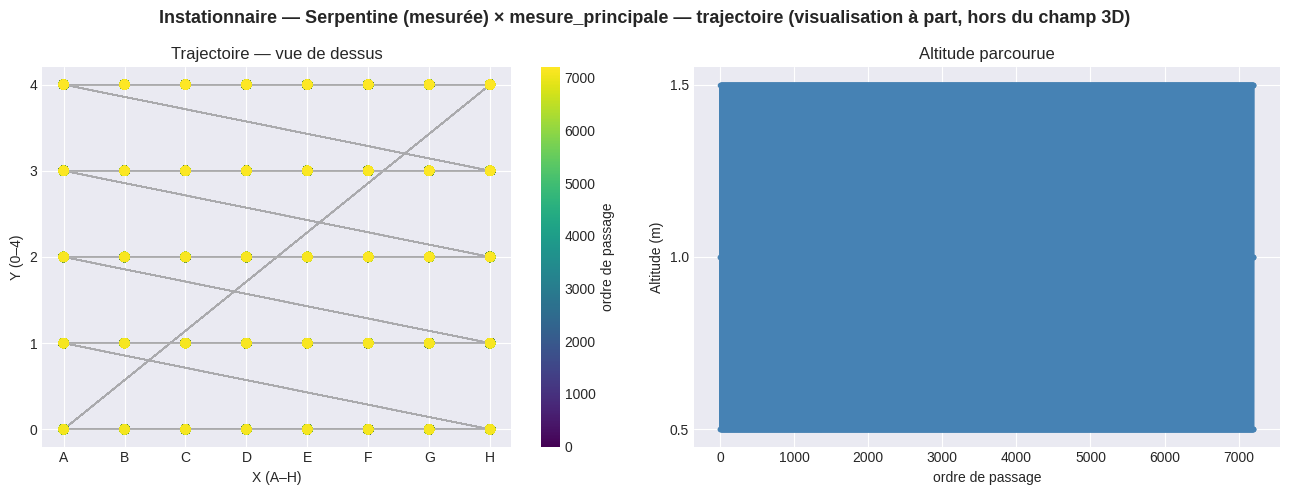

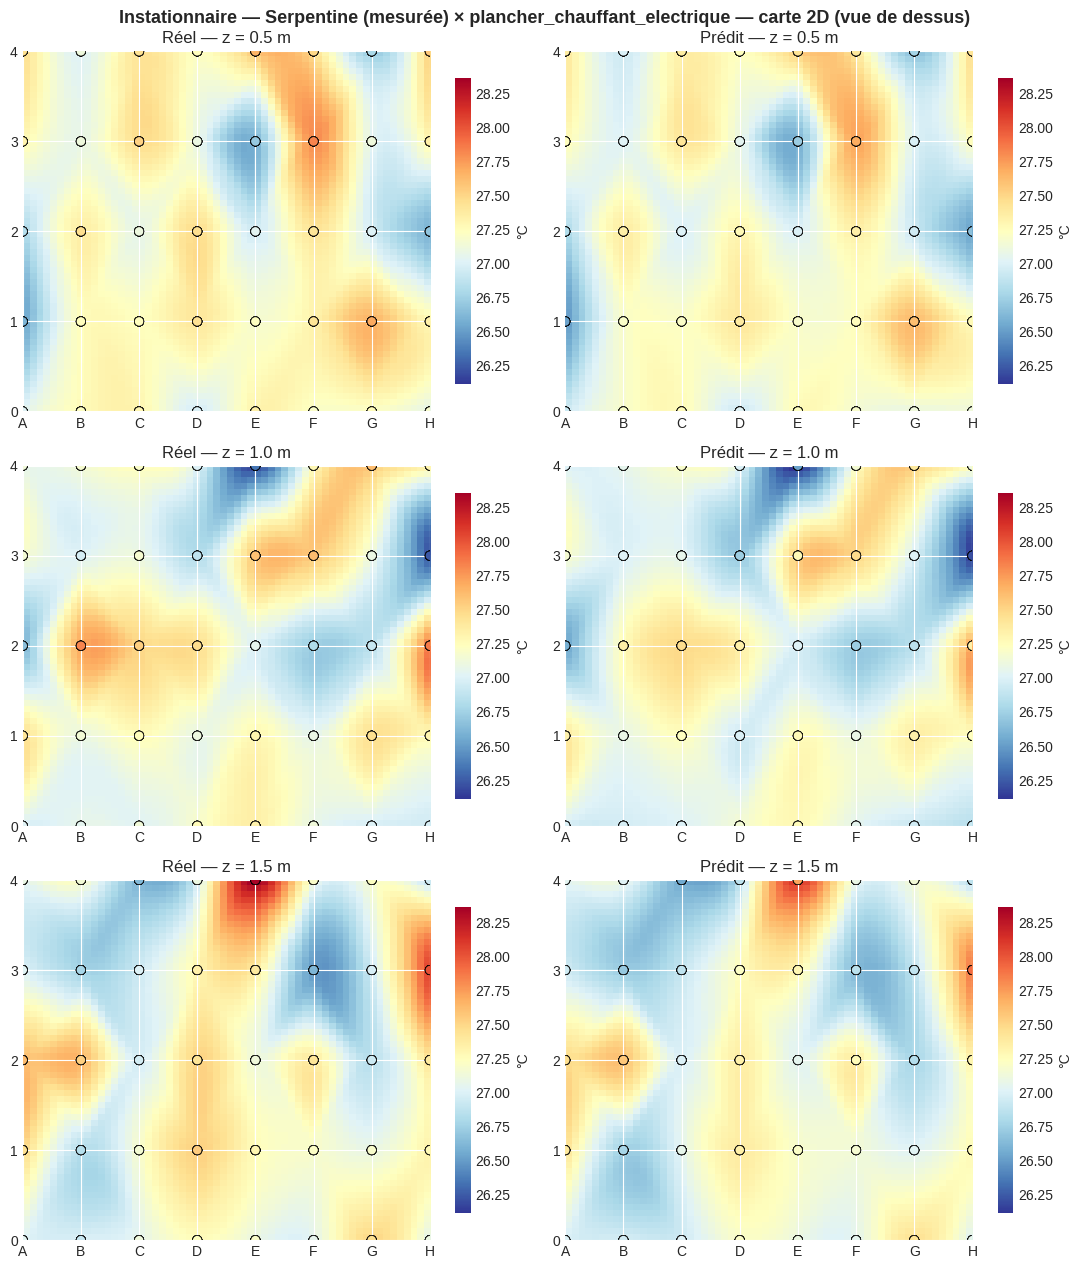

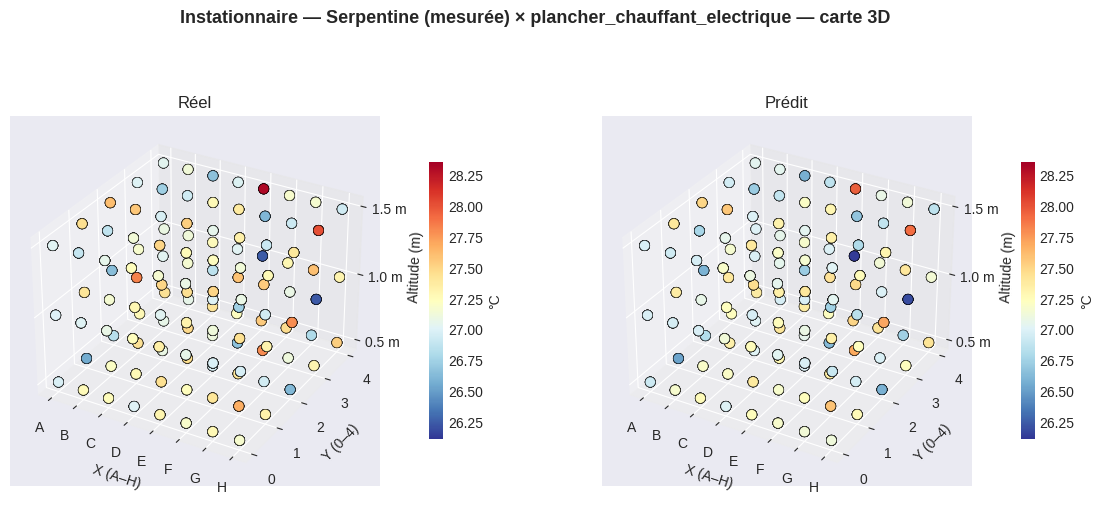

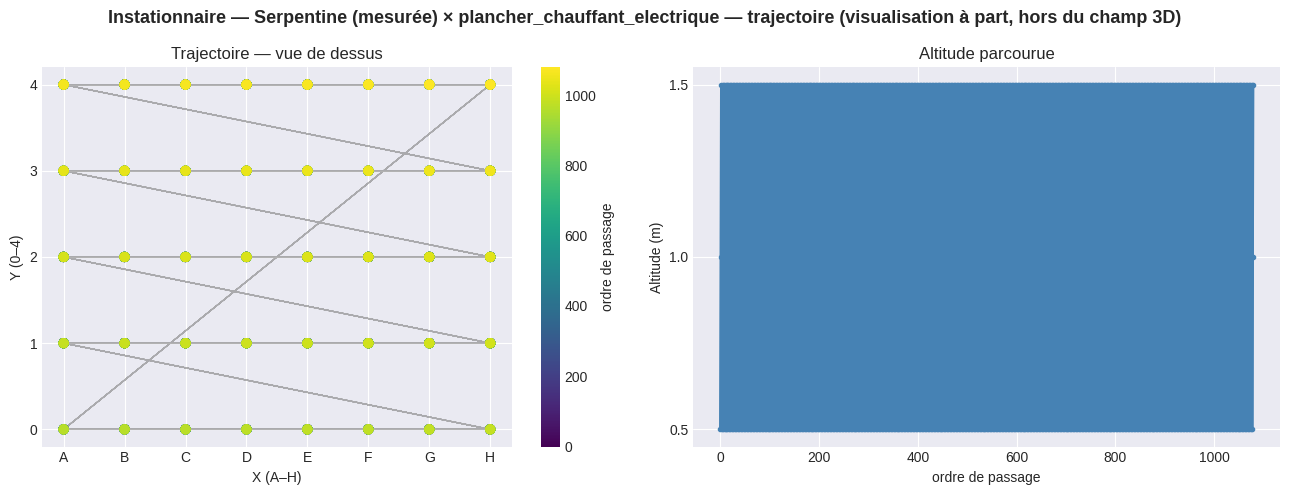

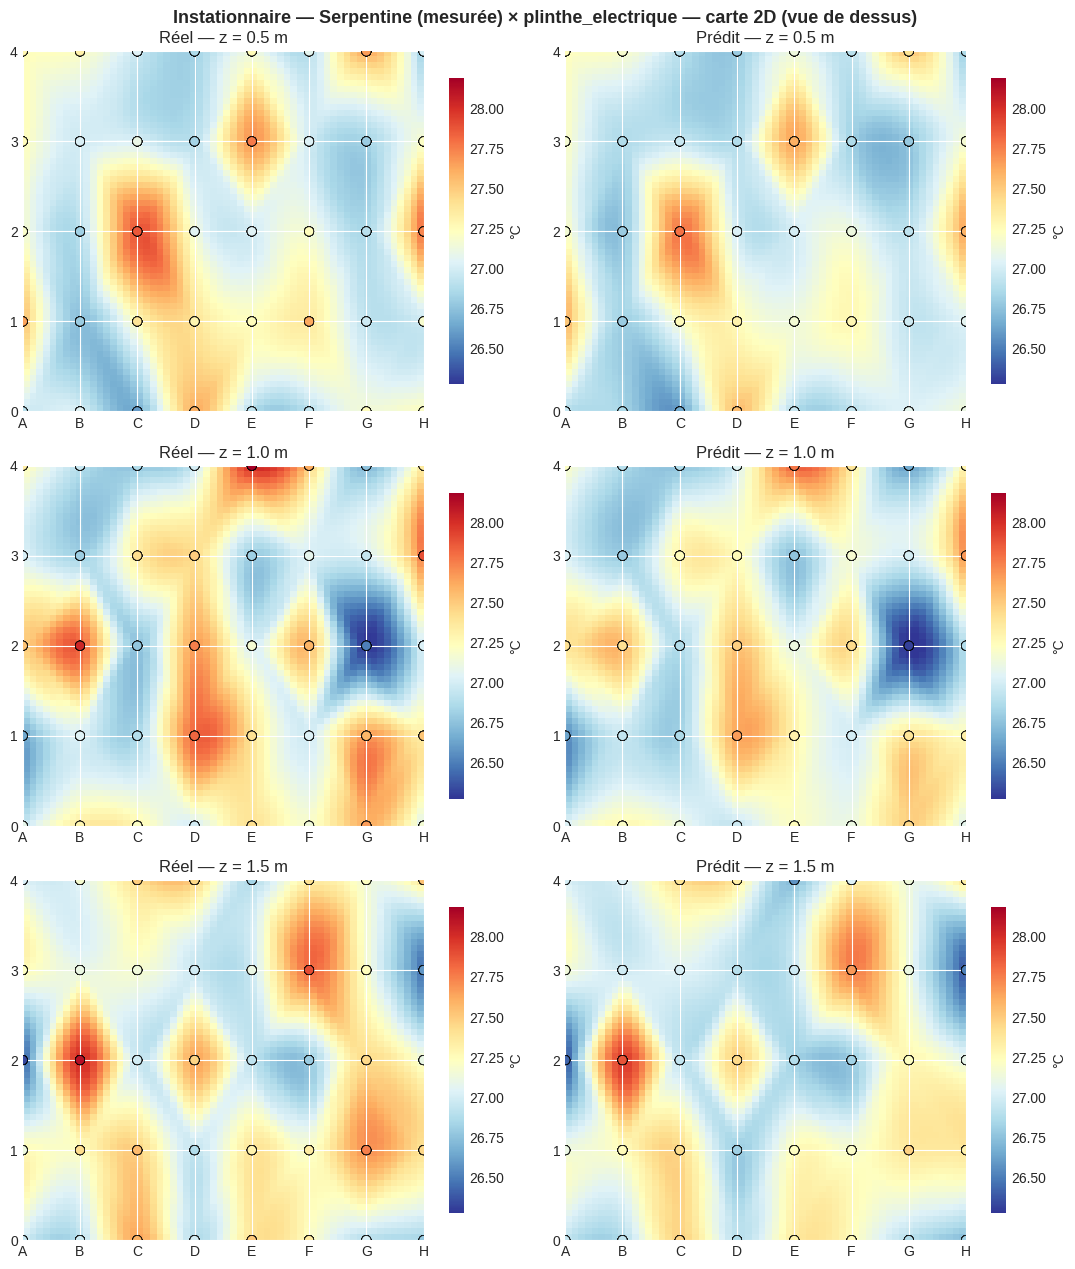

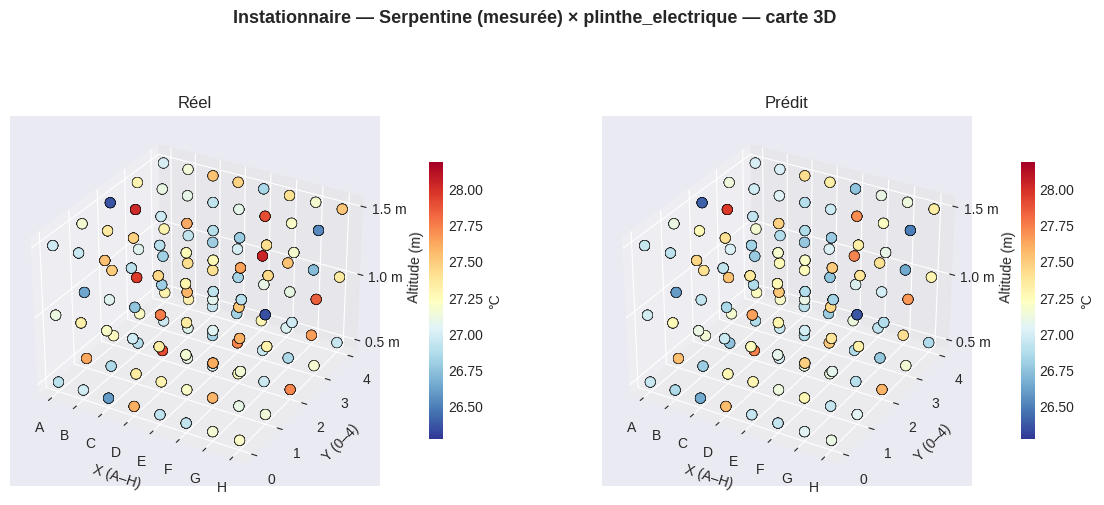

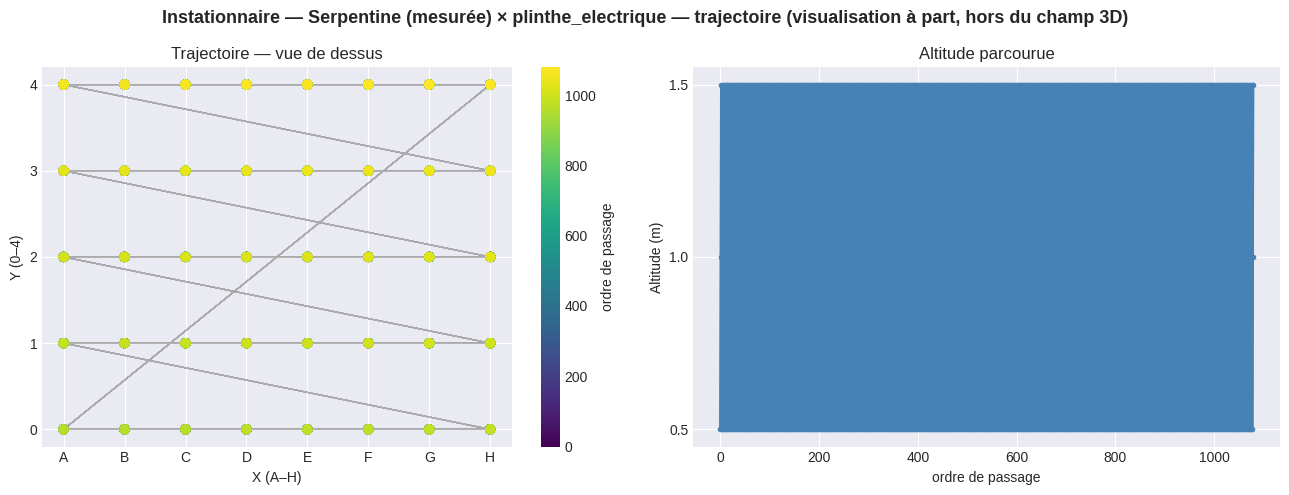

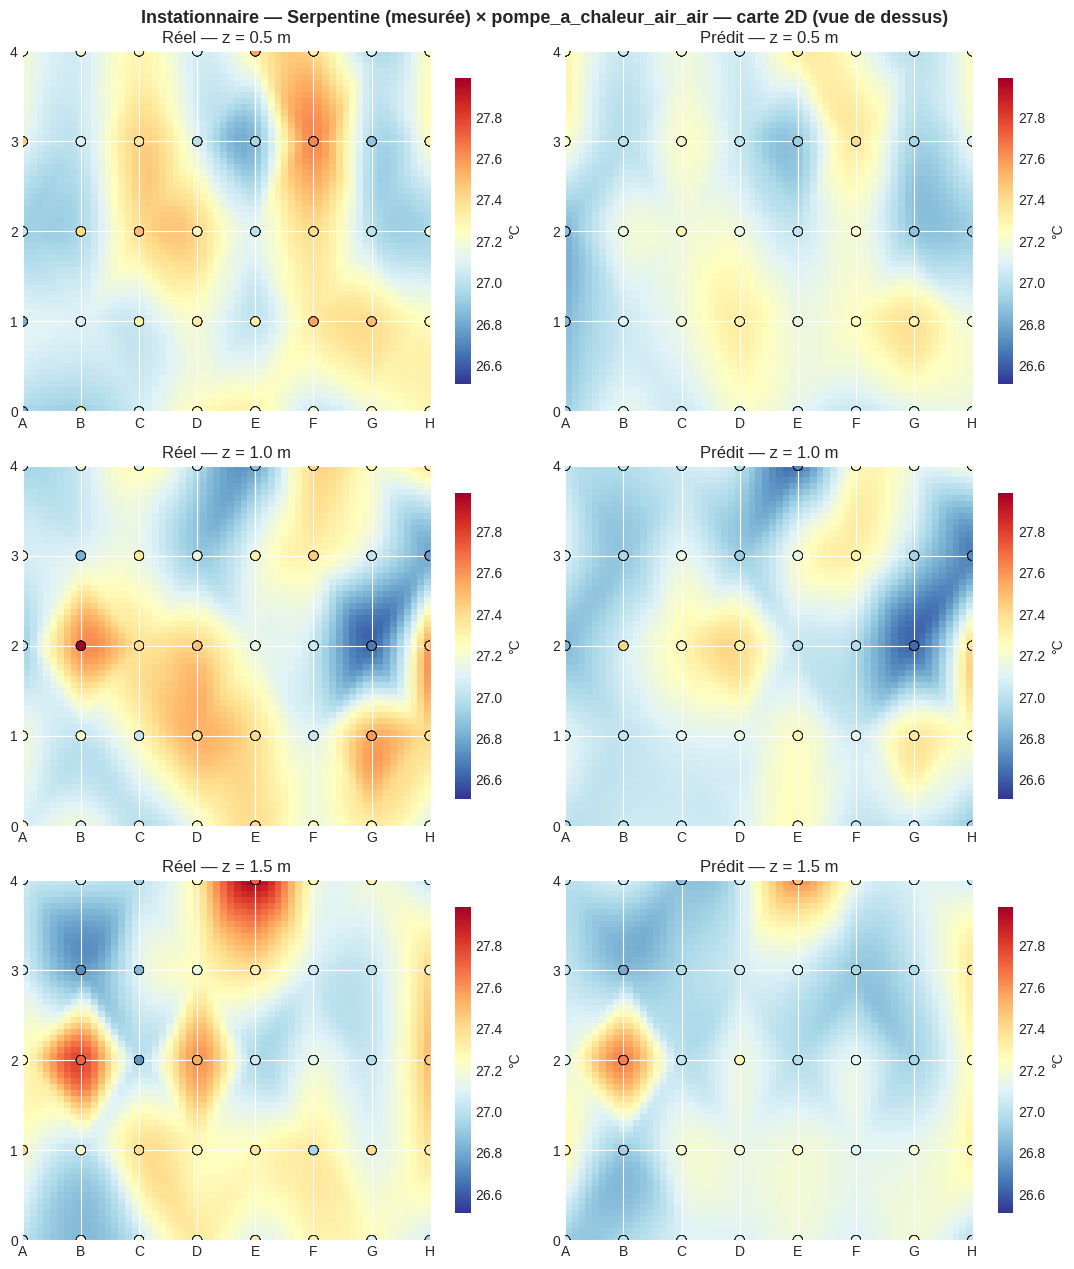

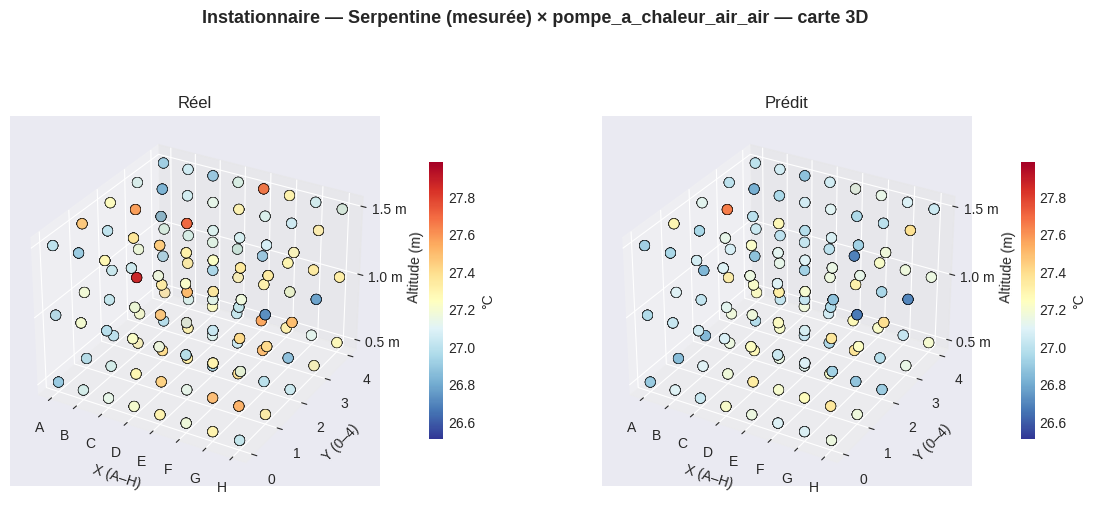

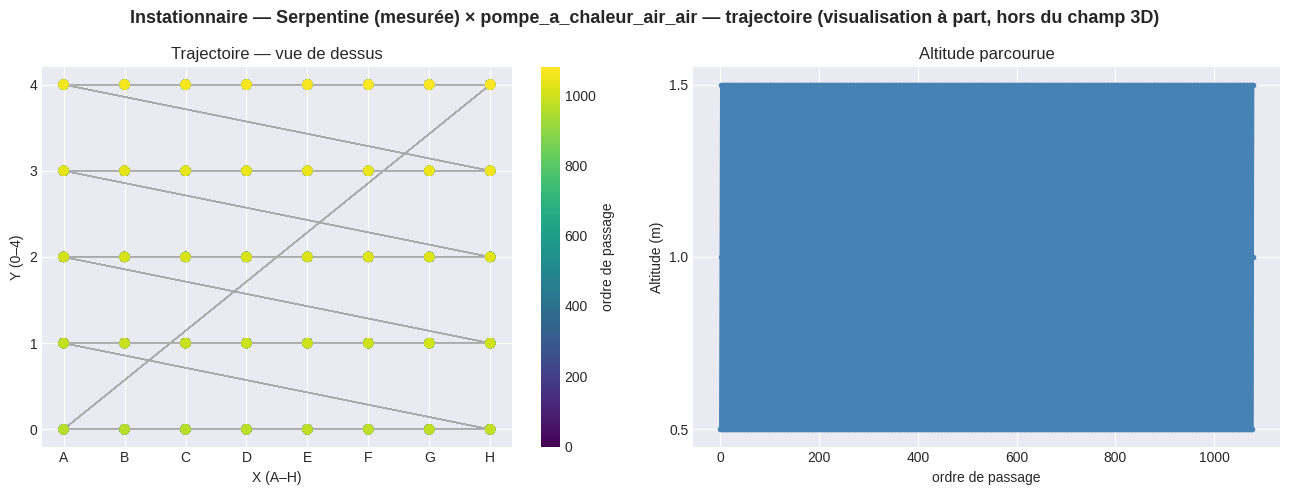

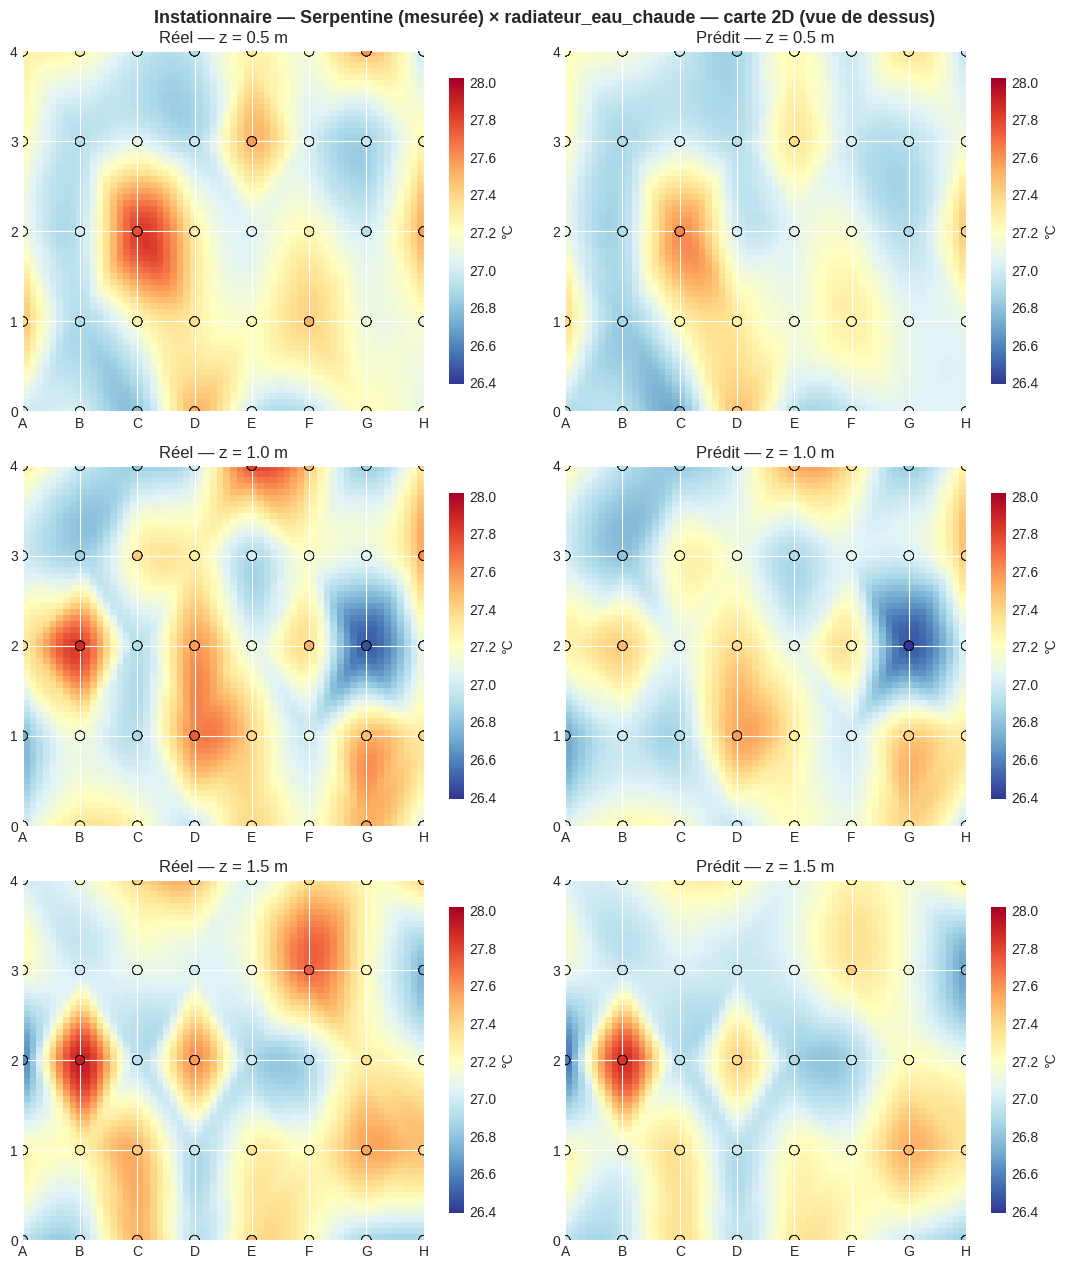

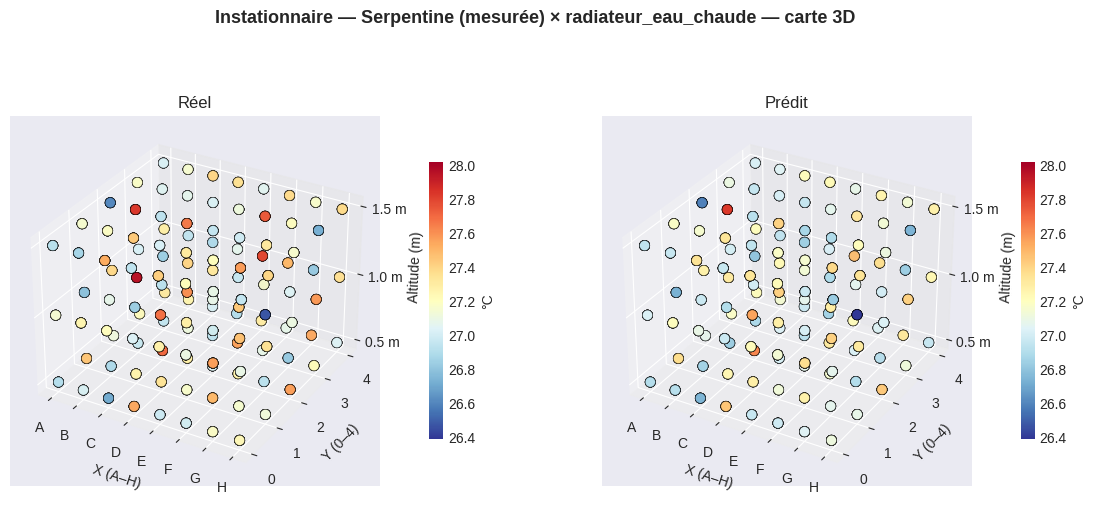

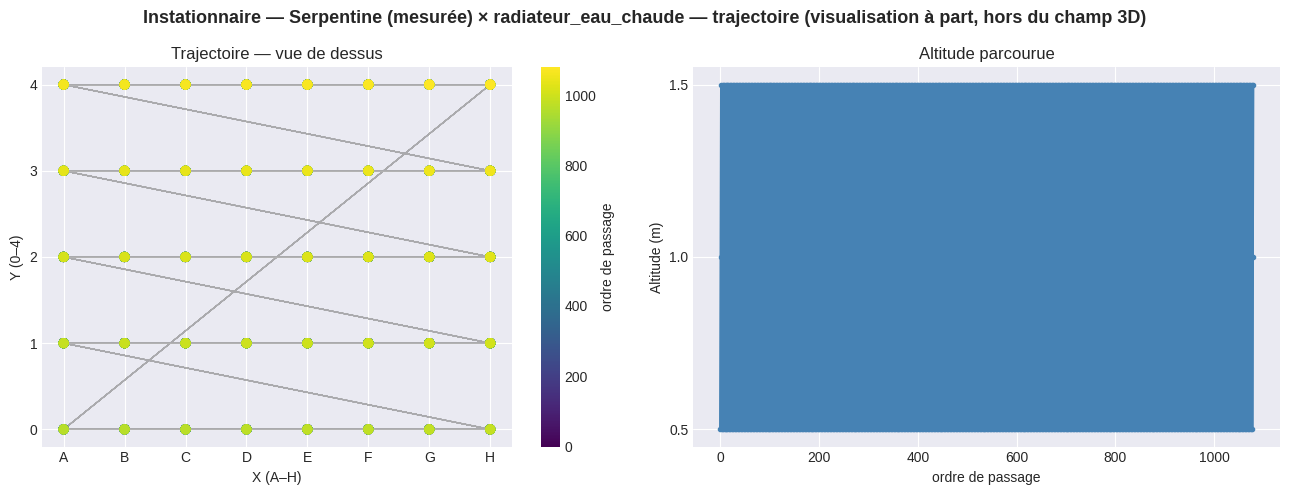

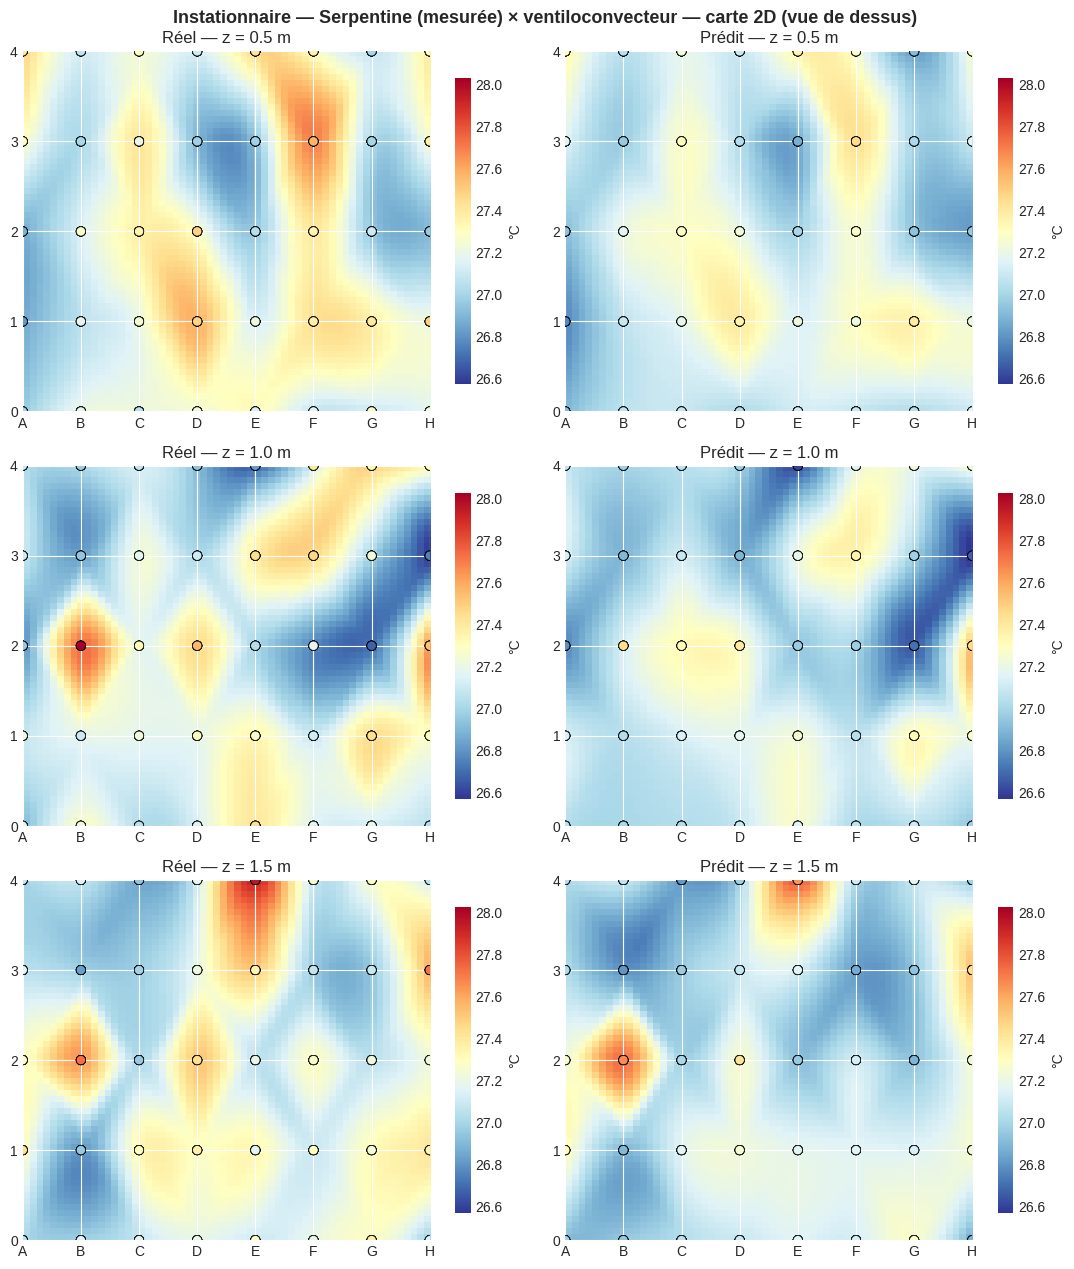

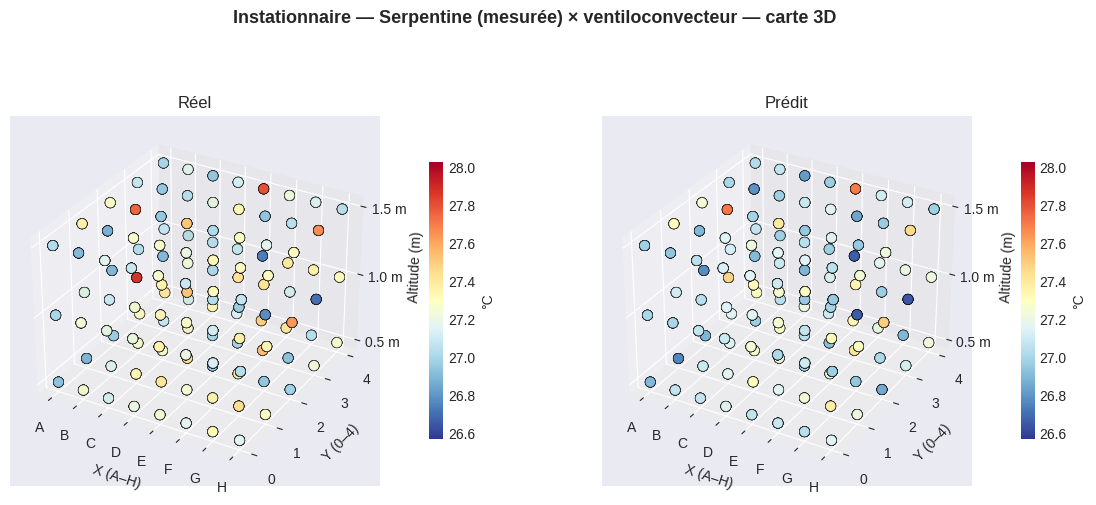

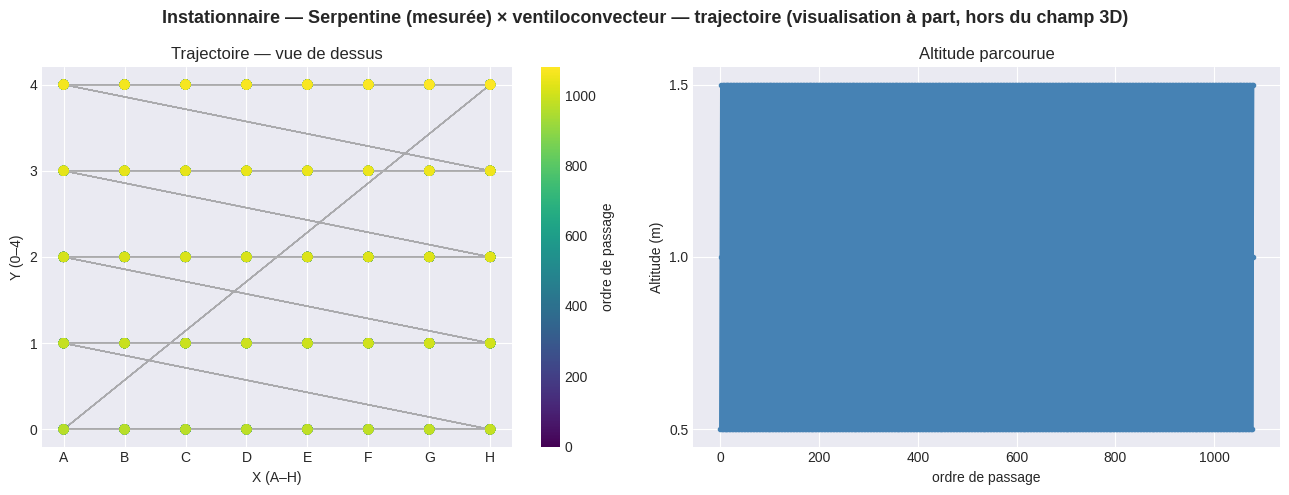

In [38]:
sous_ensembles = sous_ensemble_instationnaire(TRAJECTORY_TYPE_MESUREE)
if len(sous_ensembles) == 0:
    print('Instationnaire — Serpentine (mesurée) : aucune donnée test pour cette combinaison.')
else:
    for chauff, pts in sous_ensembles.items():
        plot_champ_3d(pts, f'Instationnaire — Serpentine (mesurée) × {chauff}', avec_trajectoire=True)

#### Instationnaire — trajectoire : Périmètre

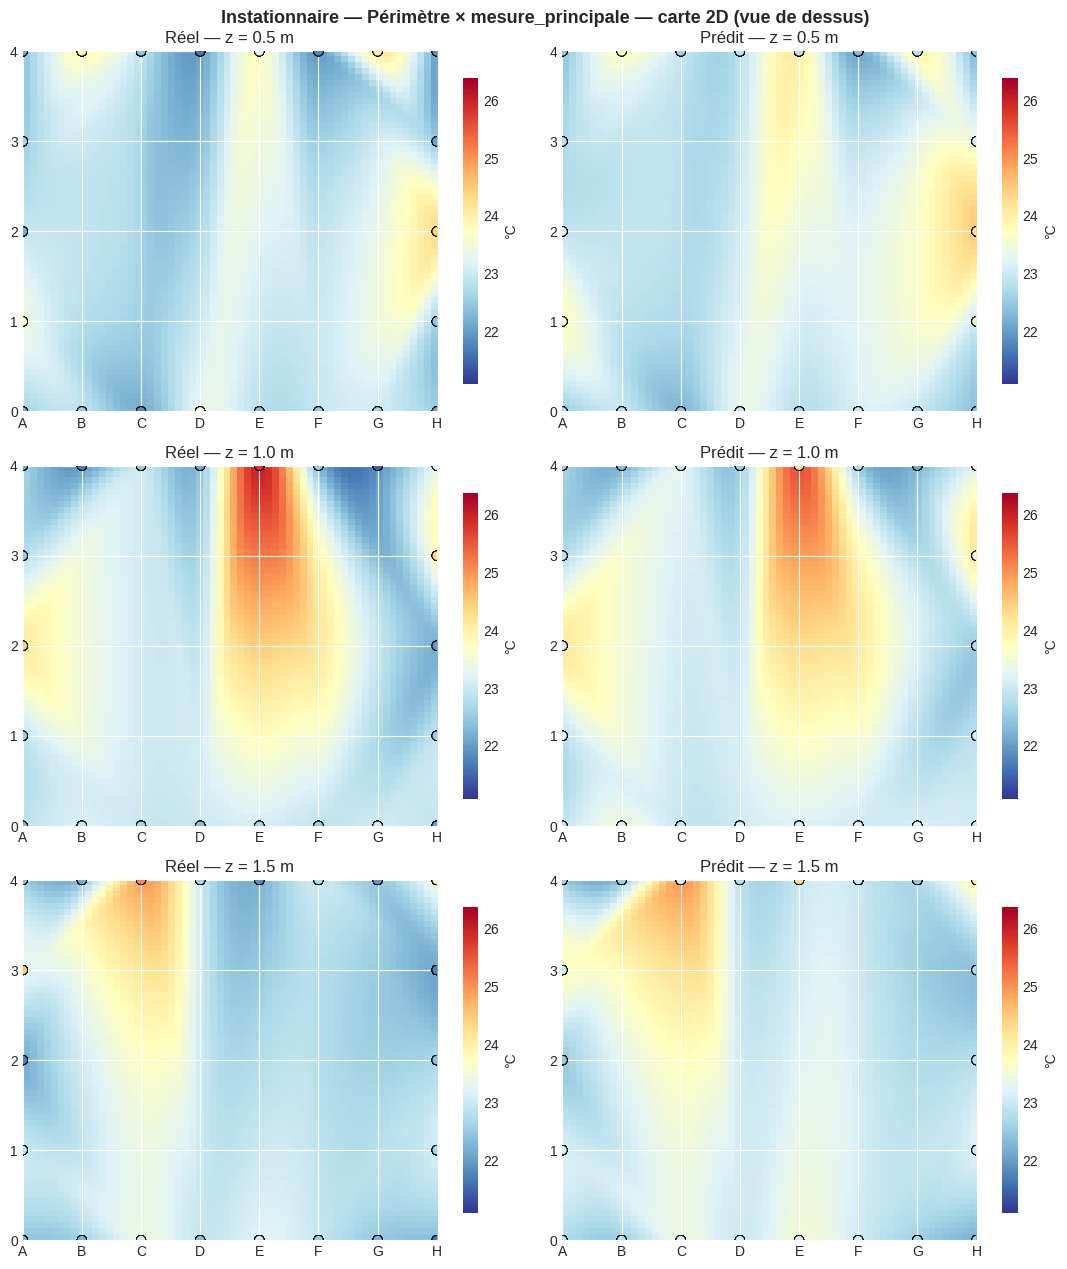

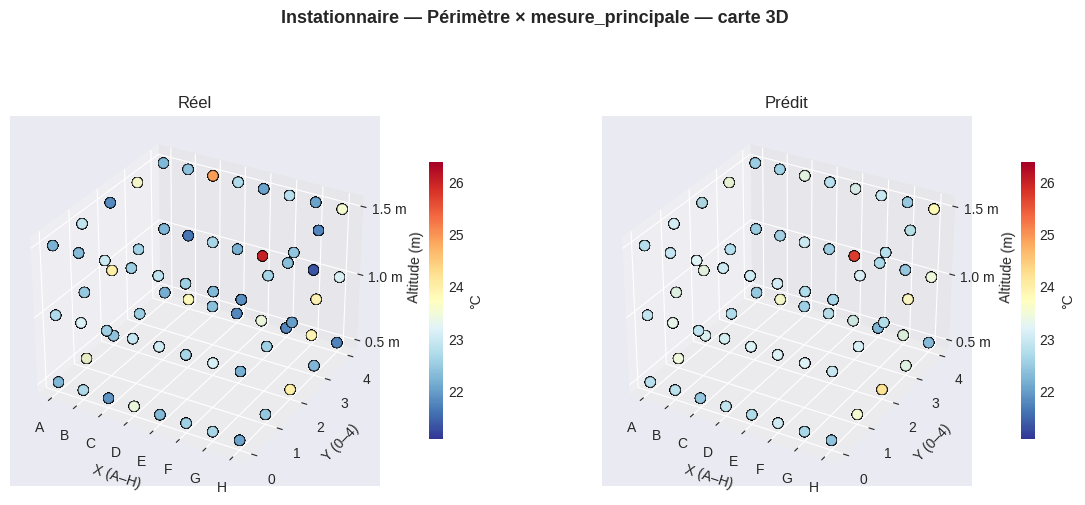

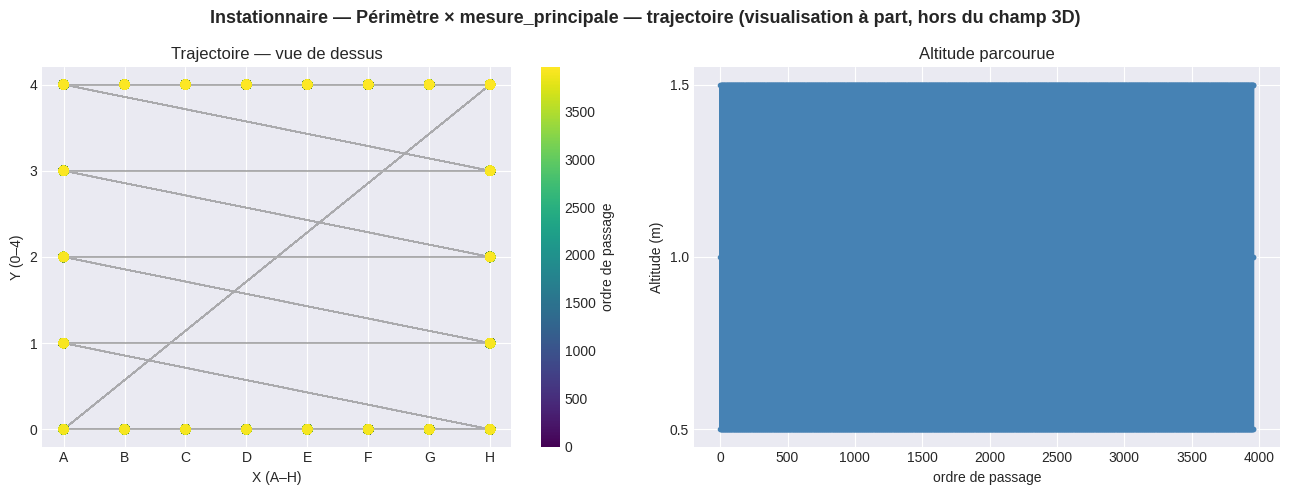

In [39]:
sous_ensembles = sous_ensemble_instationnaire('Périmètre')
if len(sous_ensembles) == 0:
    print('Instationnaire — Périmètre : aucune donnée test pour cette combinaison.')
else:
    for chauff, pts in sous_ensembles.items():
        plot_champ_3d(pts, f'Instationnaire — Périmètre × {chauff}', avec_trajectoire=True)

#### Instationnaire — trajectoire : Zigzag diagonal

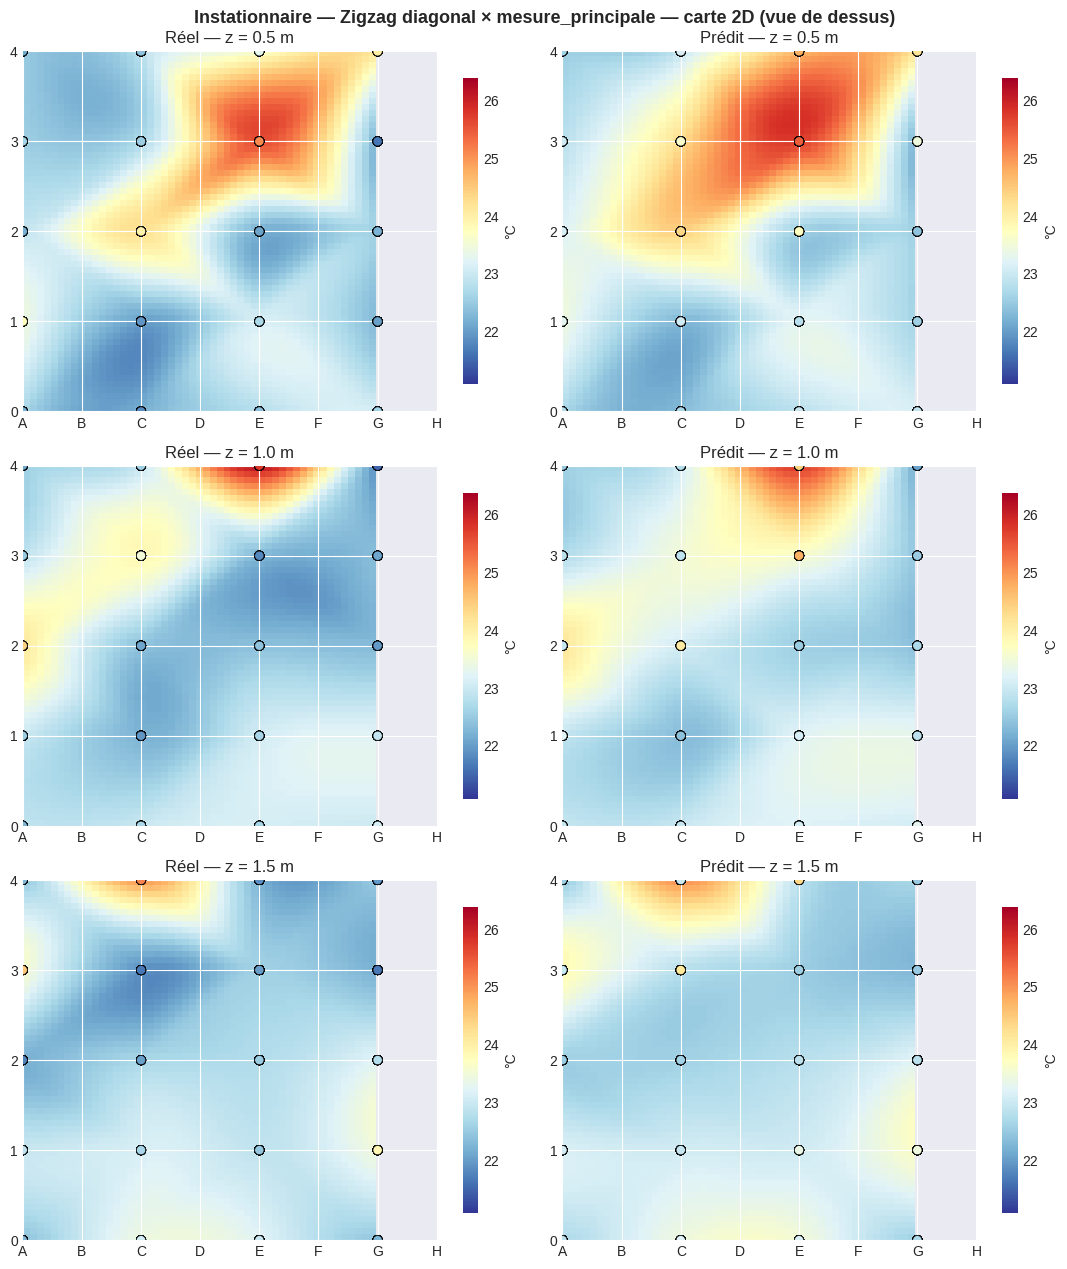

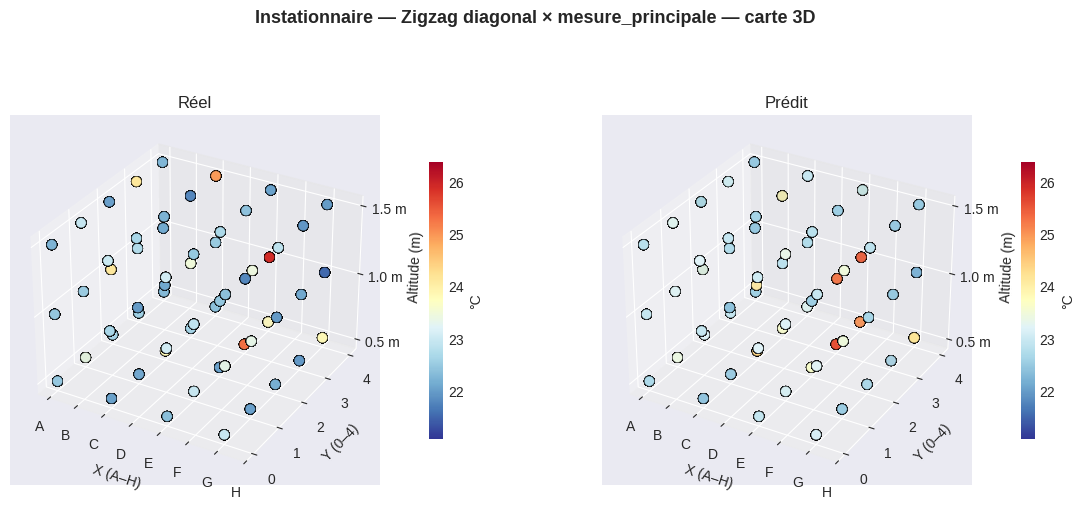

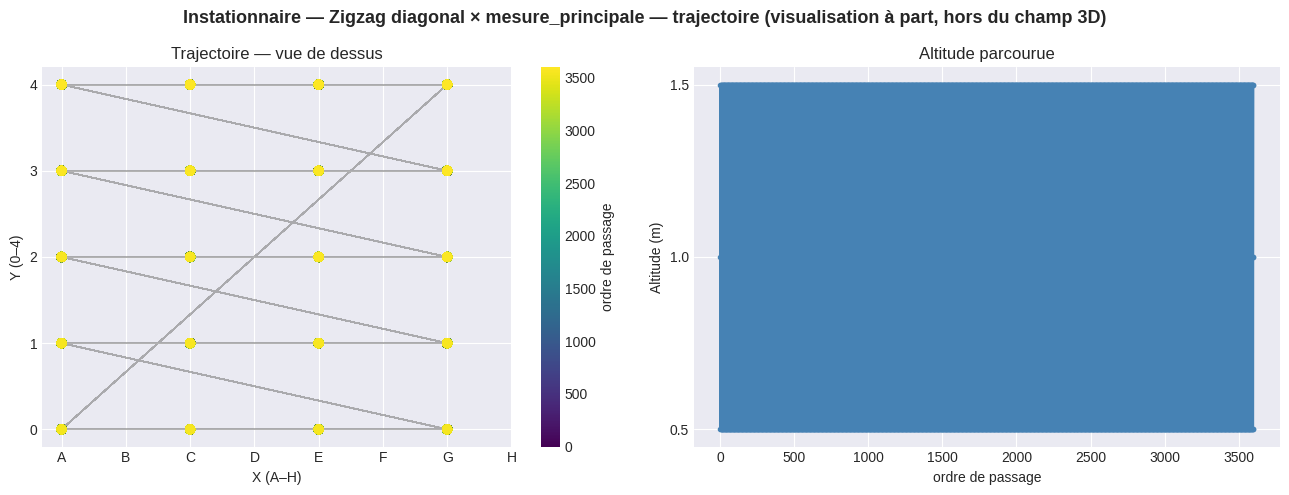

In [40]:
sous_ensembles = sous_ensemble_instationnaire('Zigzag diagonal')
if len(sous_ensembles) == 0:
    print('Instationnaire — Zigzag diagonal : aucune donnée test pour cette combinaison.')
else:
    for chauff, pts in sous_ensembles.items():
        plot_champ_3d(pts, f'Instationnaire — Zigzag diagonal × {chauff}', avec_trajectoire=True)

#### Instationnaire — trajectoire : Aléatoire

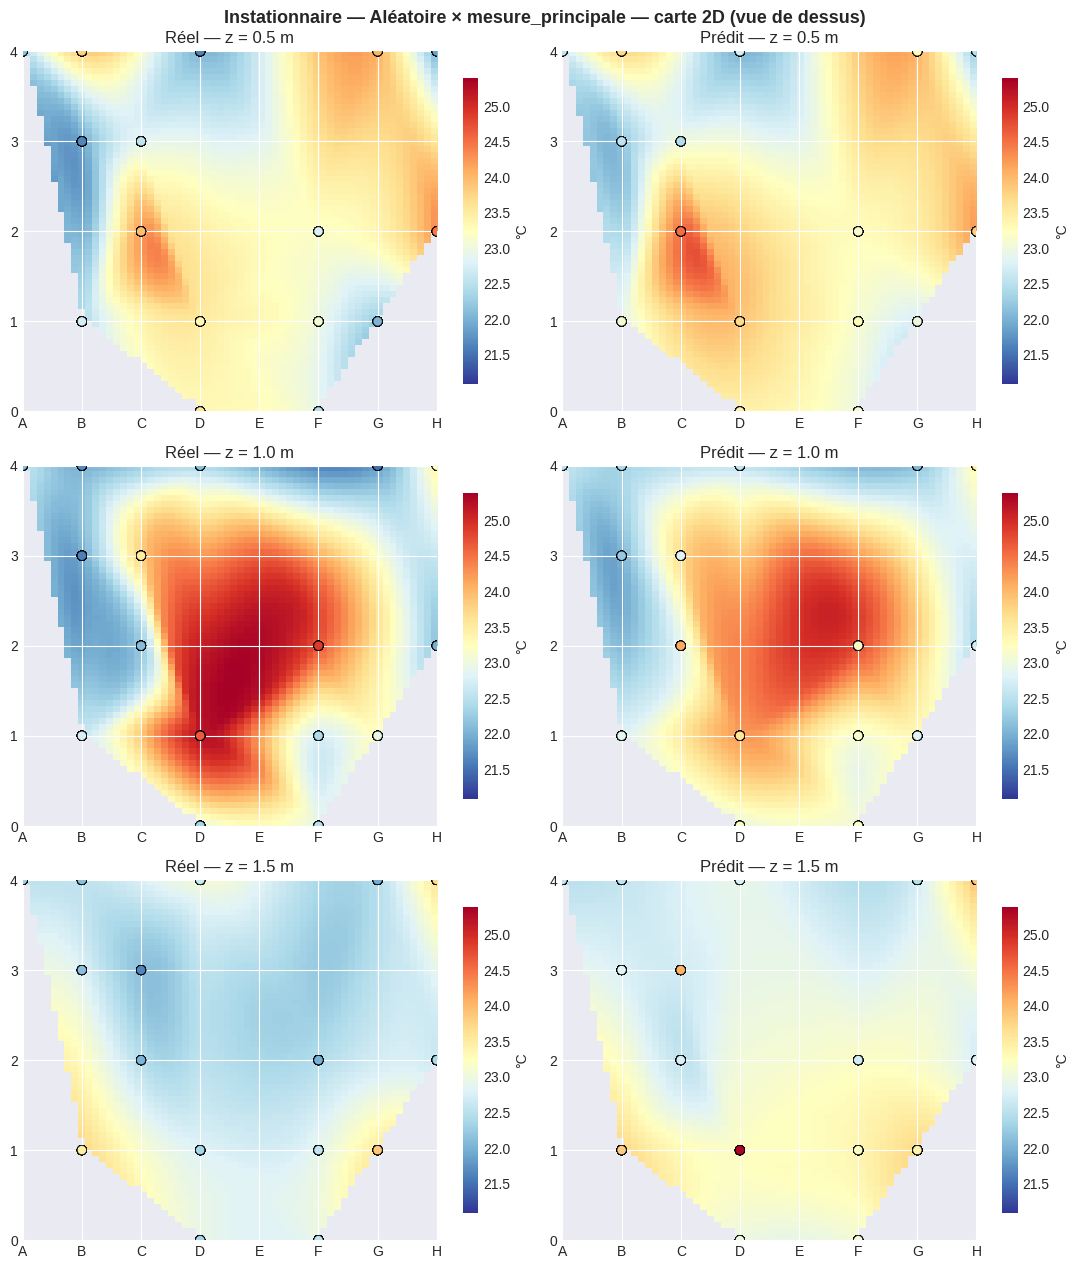

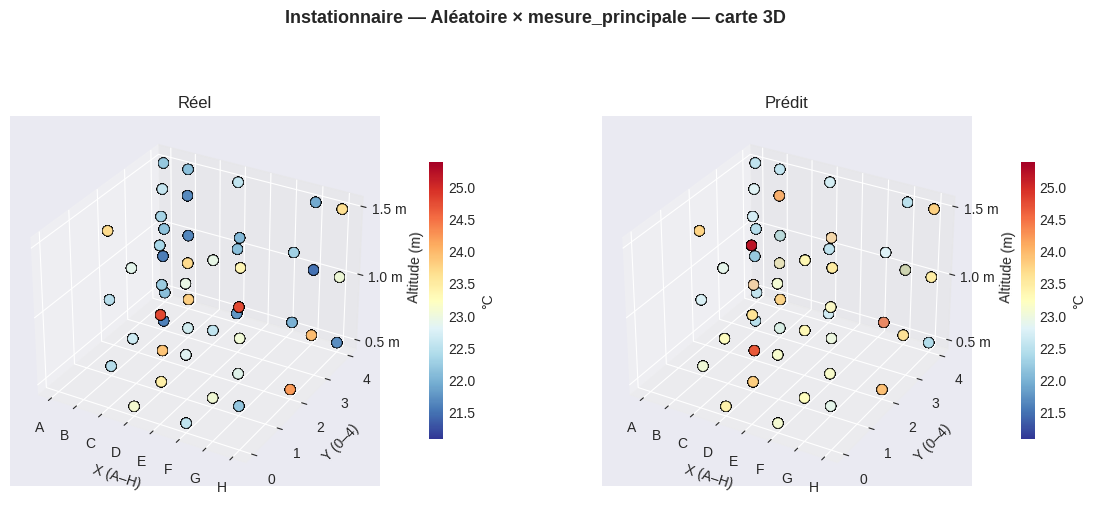

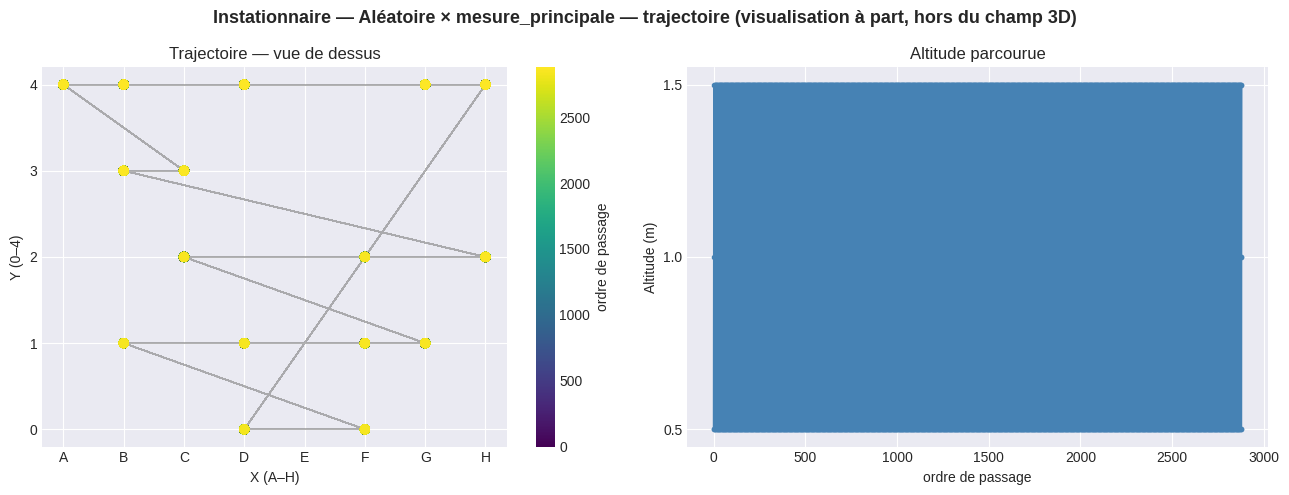

In [41]:
sous_ensembles = sous_ensemble_instationnaire('Aléatoire')
if len(sous_ensembles) == 0:
    print('Instationnaire — Aléatoire : aucune donnée test pour cette combinaison.')
else:
    for chauff, pts in sous_ensembles.items():
        plot_champ_3d(pts, f'Instationnaire — Aléatoire × {chauff}', avec_trajectoire=True)

#### Instationnaire — trajectoire : FPS

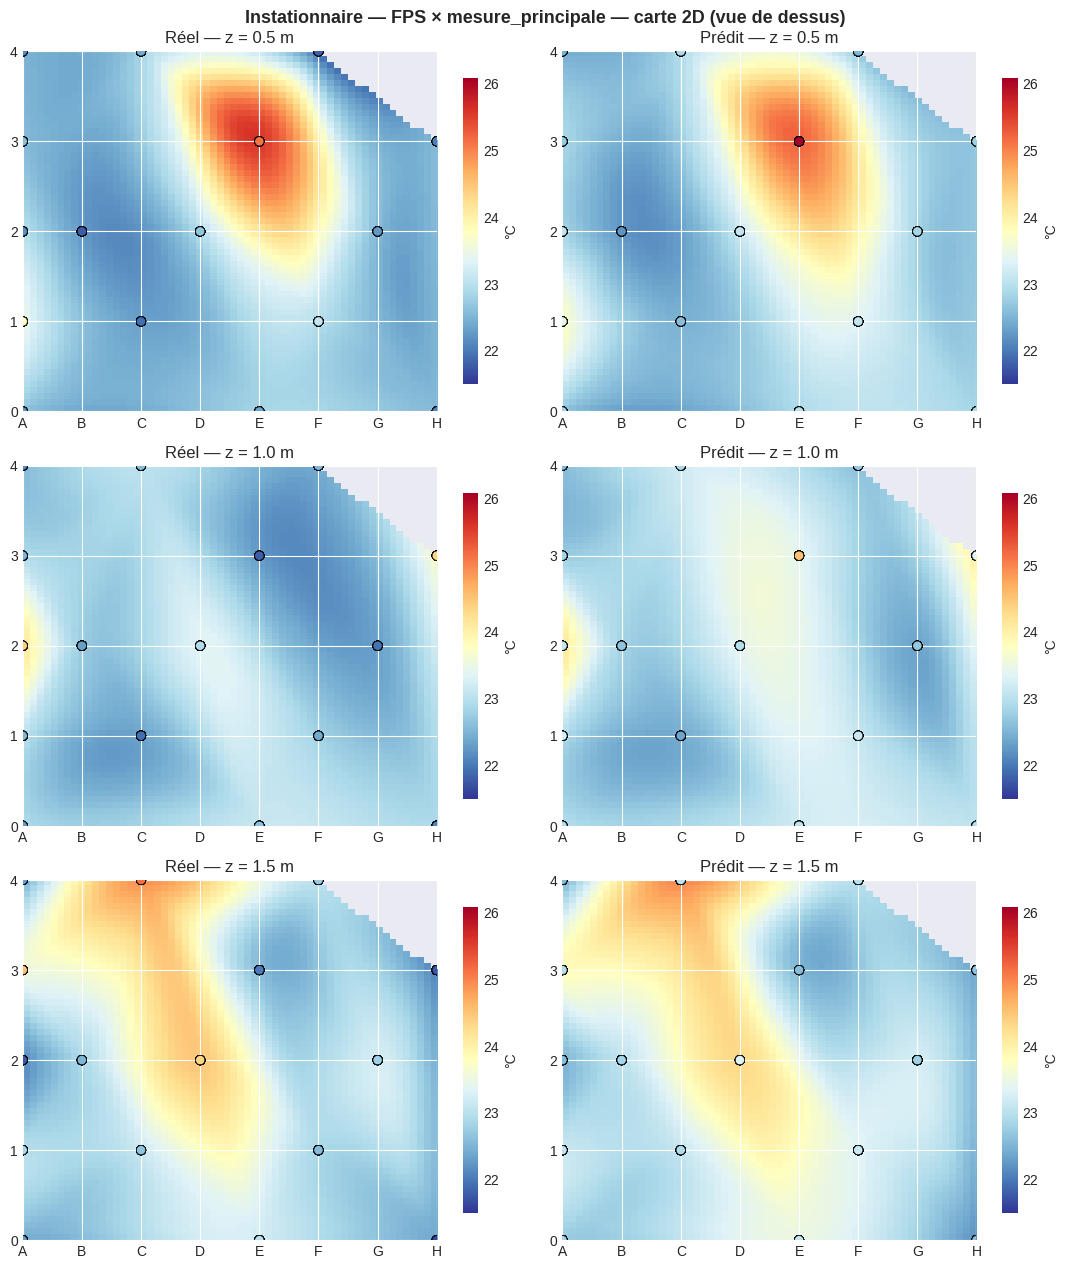

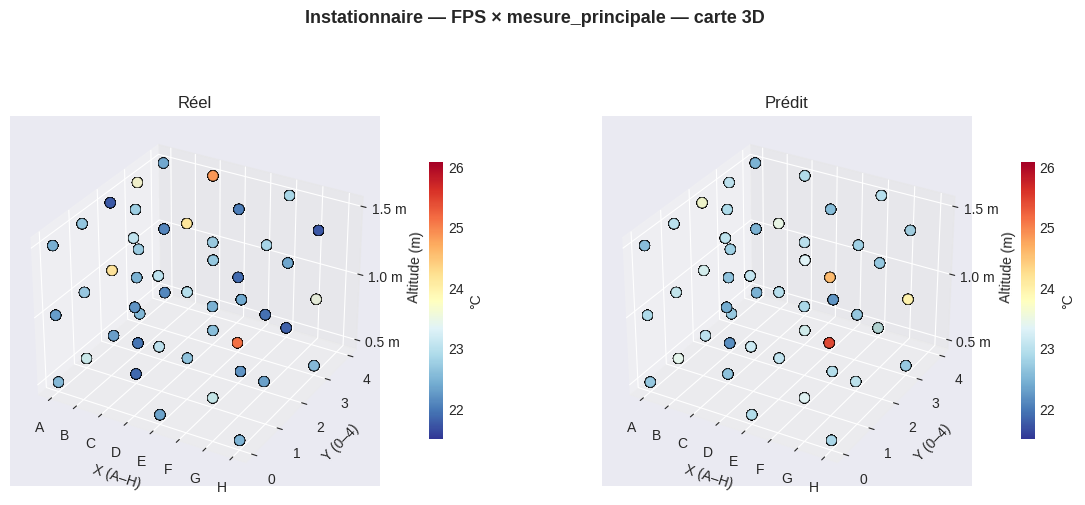

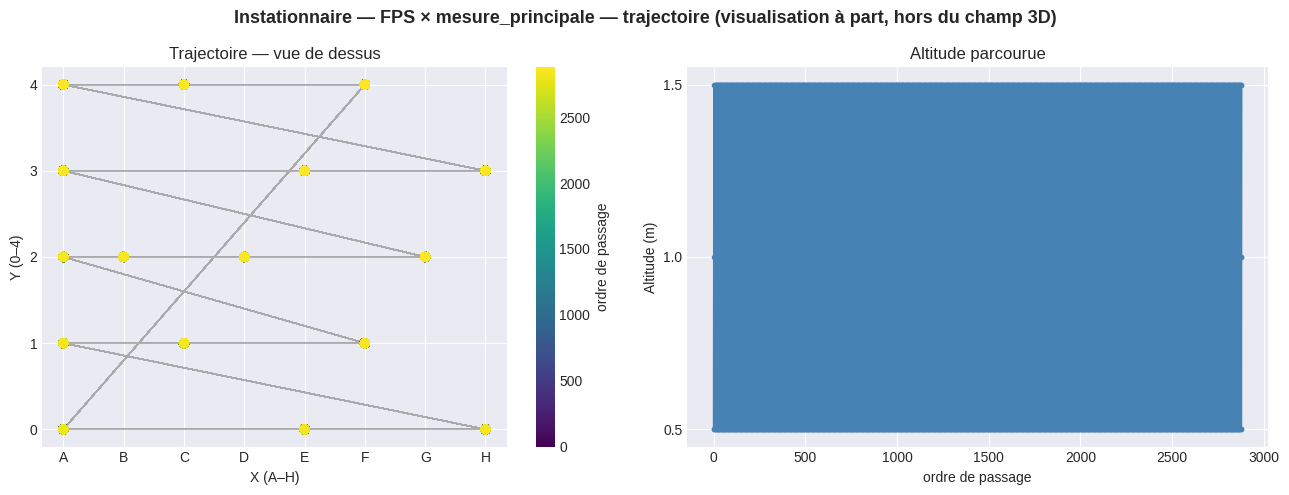

In [42]:
sous_ensembles = sous_ensemble_instationnaire('FPS')
if len(sous_ensembles) == 0:
    print('Instationnaire — FPS : aucune donnée test pour cette combinaison.')
else:
    for chauff, pts in sous_ensembles.items():
        plot_champ_3d(pts, f'Instationnaire — FPS × {chauff}', avec_trajectoire=True)

## 17 — Synthèse

In [43]:
print('SYNTHÈSE — Cas A (trajectoire + chauffage connus comme features) — comparatif ExtraTrees / GaussianProcess')
print('='*78)
if 'comparaison_stat' in globals():
    print('\nModèles comparés (STATIONNAIRE) :', list(comparaison_stat.index))
if 'comparaison_inst' in globals():
    print('Modèles comparés (INSTATIONNAIRE) :', list(comparaison_inst.index))

if 'metrics_stat' in globals():
    nom_modele = NOM_MODELE_STATIONNAIRE if 'NOM_MODELE_STATIONNAIRE' in globals() else 'inconnu'
    print(f"\nStationnaire (interprétation spatiale, modèle retenu : {nom_modele}) : "
          f"RMSE={metrics_stat['rmse']:.3f}°C  "
          f"MAE={metrics_stat['mae']:.3f}°C  MAPE={metrics_stat['mape']:.2f}%  R²={metrics_stat['r2']:.3f}")
if 'metrics_inst' in globals():
    nom_modele_i = NOM_MODELE_INSTATIONNAIRE if 'NOM_MODELE_INSTATIONNAIRE' in globals() else 'inconnu'
    print(f"Instationnaire (point suivant / trajectoire, modèle retenu : {nom_modele_i}) : "
          f"RMSE={metrics_inst['rmse']:.3f}°C  "
          f"MAE={metrics_inst['mae']:.3f}°C  MAPE={metrics_inst['mape']:.2f}%  R²={metrics_inst['r2']:.3f}")

print('\nInterprétation :')
print('- Stationnaire : le modèle généralise dans l\'ESPACE -> capacité à déduire des points')
print('  non mesurés à partir des points mesurés par le robot, à un instant donné.')
print('  Comparatif : ExtraTrees (features géométrie + voisins IDW) et un Gaussian Process spatial')
print('  (position × chauffage, entraîné sur coordonnées réelles) ; le meilleur R² test est')
print('  retenu pour la carte thermique finale.')
print('- Instationnaire : le modèle généralise dans le TEMPS le long de la trajectoire ->')
print('  capacité à prédire le point suivant (~20s plus tard) à partir du point précédent.')
print('  Même comparatif, dont un Gaussian Process (sous-échantillonné si le volume de')
print('  données dépasse', 'GPR_MAX_TRAIN' in globals() and GPR_MAX_TRAIN or 1500, 'lignes).')
print('\nVoir les sections 13/13bis/13ter et 14 pour les tableaux comparatifs complets,')
print('les graphiques en barres (RMSE/MAE/MAPE/R2) et les grilles de parité par modèle.')

SYNTHÈSE — Cas A (trajectoire + chauffage connus comme features) — comparatif ExtraTrees / GaussianProcess

Modèles comparés (STATIONNAIRE) : ['GaussianProcess (spatial)', 'ExtraTrees']
Modèles comparés (INSTATIONNAIRE) : ['ExtraTrees', 'GaussianProcess']

Stationnaire (interprétation spatiale, modèle retenu : GaussianProcess (spatial)) : RMSE=2.507°C  MAE=1.917°C  MAPE=8.16%  R²=-0.006
Instationnaire (point suivant / trajectoire, modèle retenu : ExtraTrees) : RMSE=0.715°C  MAE=0.468°C  MAPE=2.06%  R²=0.879

Interprétation :
- Stationnaire : le modèle généralise dans l'ESPACE -> capacité à déduire des points
  non mesurés à partir des points mesurés par le robot, à un instant donné.
  Comparatif : ExtraTrees (features géométrie + voisins IDW) et un Gaussian Process spatial
  (position × chauffage, entraîné sur coordonnées réelles) ; le meilleur R² test est
  retenu pour la carte thermique finale.
- Instationnaire : le modèle généralise dans le TEMPS le long de la trajectoire ->
  capac